# CoDA: Agentic Systems for Collaborative Data Visualization 実装例

## 概要

本ノートブックは、論文「[CoDA: Agentic Systems for Collaborative Data Visualization](https://arxiv.org/abs/2510.03194)」に基づくマルチエージェント協調型データ可視化システムの実装例です。Google Agent Development Kit (ADK) と Vertex AI (Gemini モデル) を活用し、ユーザーの自然言語によるリクエストから適切なグラフ画像を自動生成するパイプラインを構築します。

**※実装上の留意点**
論文に記載されているコードサンプルの Web 検索機能については、本実装ではコードの全体像をシンプルに保つため省略しています。

## アーキテクチャとエージェント構成

このシステムは、ユーザーとの対話を行うルートエージェントと、可視化の各タスクを専門的に分担し、画像の評価と推敲のループを自律的に回す複数のサブエージェントによって構成されています。

* **Root Agent (`root_agent`)**: ユーザーと対話し、可視化の要件（可視化クエリ、対象のCSVファイル名）を漏れなく収集した上で、生成パイプラインを起動します
* **Query Analyzer (`query_analyzer`)**: ユーザーの意図を解釈し、可視化の全体計画と実装に向けたTODOリストを作成します。
* **Data Process Planner (`data_process_planner`)**: データのメタデータや統計情報を分析し、必要なデータ前処理（変換や集計）のステップを計画します。
* **VizMapping Agent (`viz_mapping_agent`)**: データの各列をグラフの視覚的プロパティにマッピングし、最適なチャートタイプを選択します。
* **Design Explorer (`design_explorer`)**: ターゲットオーディエンスに合わせた配色、レイアウト、タイポグラフィなどの詳細なデザイン仕様を決定します。
* **Code Generator (`code_generator`)**: 各エージェントが策定した仕様を統合し、実行可能な Python (Matplotlib) コードを生成・実行します。
* **Visual Evaluator (`visual_evaluator`)**: 生成されたグラフ画像を評価し、要件との一致度や品質のスコアリング、改善点のフィードバックを行います。
* **Result Checker (`result_checker`) & Design Refiner (`design_refiner`)**: 評価結果に基づいてループの継続を判定し、修正が必要な場合はフィードバックを基にデザイン仕様の推敲を行います。

## 実行の流れ

1. ルートエージェントがユーザーから必要な情報を収集します（不足している場合はヒアリングを行います）。
2. 情報が揃うとADKのセッションステートにコンテキストが保存され、人間の介入なしにチャート生成パイプラインが自律的に順次実行されます。
3. **【リファインメントループ】** コード生成とサンドボックスでの実行後、Visual Evaluator が出力画像を評価します。要件を満たさない場合は、最大試行回数（`MAX_ITERATIONS`）に達するまで、Design Refiner による推敲と再生成が繰り返されます。
4. 最終的に承認されたコードにより `output_plot.png` として結果画像が生成・共有されます。ノートブックの後半では、MatplotBench のテストケースを用いたベンチマーク評価が行われます。

## 事前準備

Google Cloud の新規プロジェクトを作成して、Cloud Shell から次を実行します。

 
- 必要な API を有効化
```
gcloud services enable \
  aiplatform.googleapis.com \
  notebooks.googleapis.com \
  cloudresourcemanager.googleapis.com
```

- Vertex AI のサービスアカウントを作成して、IAM 権限を設定
```
PROJECT_ID=$(gcloud config list --format 'value(core.project)' 2>/dev/null)
PROJECT_NUMBER=$(gcloud projects describe $PROJECT_ID --format='value(projectNumber)' 2>/dev/null)
gcloud beta services identity create --service=aiplatform.googleapis.com --project=$PROJECT_ID
gcloud projects add-iam-policy-binding $PROJECT_ID \
    --member="serviceAccount:service-${PROJECT_NUMBER}@gcp-sa-aiplatform.iam.gserviceaccount.com" \
    --role='roles/storage.objectUser'
```

- Vertex AI Workbench のインスタンスを作成
```
PROJECT_ID=$(gcloud config list --format 'value(core.project)' 2>/dev/null)
gcloud workbench instances create development-instance \
  --project=$PROJECT_ID \
  --location=us-central1-a \
  --machine-type=e2-standard-2
```

クラウドコンソールのナビゲーションメニューから「Vertex AI」→「Workbench」を選択すると、作成したインスタンス development-instance があります。インスタンスの起動が完了するのを待って、「JUPYTERLAB を開く」をクリックしたら、「Python 3(ipykernel)」の新規ノートブックを作成します。

この後は、ノートブックのセルでコードを実行していきます。

画像処理に使用する Pillow のパッケージをインストールします。あわせて、ADK に必要なパッケージもインストールします。

In [ ]:
%pip install --upgrade --user \
    Pillow \
    google-adk==1.26.0 \
    google-genai==1.56.0 \
    google-cloud-aiplatform==1.132.0

インストールしたパッケージを利用可能にするために、次のコマンドでカーネルを再起動します。

再起動を確認するポップアップが表示されるので [Ok] をクリックします。

In [15]:
import IPython
app = IPython.Application.instance()
_ = app.kernel.do_shutdown(True)

## 初期設定

In [1]:
import base64
import copy
import io
import json
import urllib.request
from typing import Any, List, Literal, Optional

import pandas as pd
from IPython.display import Markdown, display
from PIL import Image
from pydantic import BaseModel, Field

# Google Cloud & Vertex AI
from google import genai
from google.genai.types import (
    Content,
    FunctionCall,
    GenerateContentConfig,
    HttpOptions,
    Part,
    Tool, 
    ToolCodeExecution
)
import vertexai
from vertexai.agent_engines import AdkApp

# Google ADK
from google.adk.agents.context import Context
from google.adk.agents.callback_context import CallbackContext
from google.adk.models import LlmRequest, LlmResponse
from google.adk.agents.llm_agent import LlmAgent
from google.adk.agents.sequential_agent import SequentialAgent
from google.adk.agents.loop_agent import LoopAgent
from google.adk.artifacts import GcsArtifactService
from google.adk.tools import ToolContext, TransferToAgentTool 
from google.adk.tools.exit_loop_tool import exit_loop
from google.adk.plugins.save_files_as_artifacts_plugin import SaveFilesAsArtifactsPlugin

[PROJECT_ID] = !gcloud config list --format 'value(core.project)' 2>/dev/null
#LOCATION = 'us-central1'
LOCATION = 'global'

vertexai.init(project=PROJECT_ID, location=LOCATION)

BUCKET_NAME = f'{PROJECT_ID}_agent_data'
#MODEL = 'gemini-2.5-flash'
#MODEL = 'gemini-2.5-pro'
MODEL = 'gemini-3-pro-preview'

MAX_ITERATIONS = 3

In [2]:
!gsutil ls -b gs://{BUCKET_NAME} 2>/dev/null || \
 gsutil mb -b on -l {LOCATION} gs://{BUCKET_NAME}

gs://etsuji-15pro-poc_agent_data/


In [3]:
class ChatClient:
    def __init__(self, adk_app, user_id='default_user'):
        self.adk_app = adk_app
        self.user_id = user_id
        self.session_id = None

    async def async_stream_query(self, message):
        if not self.session_id:
            session = await self.adk_app.async_create_session(
                user_id=self.user_id,
            )
            self.session_id = getattr(session, 'id', None) or session['id']

        result = []
        async for event in self.adk_app.async_stream_query(
            user_id=self.user_id,
            session_id=self.session_id,
            message=message,
        ):
            author = event['author']
            if ('content' in event and 'parts' in event['content']):
                response = '\n'.join(
                    [p['text'] for p in event['content']['parts'] if 'text' in p]
                )
                if response:
                    display(Markdown(f'### {author}\n{response}'))
                    result.append(response)
        return '\n'.join(result)

## Common tools

In [4]:
async def get_uri_for_artifact(filename:str, context:Context):
    artifact_service = context._invocation_context.artifact_service
    app_name = context._invocation_context.app_name
    user_id = context._invocation_context.user_id
    session_id = context._invocation_context.session.id

    versions = artifact_service._list_versions(
      app_name=app_name,
      user_id=user_id,
      session_id=session_id,
      filename=filename,
    )
    if not versions:
        return None
    version = max(versions)
    blob_name = artifact_service._get_blob_name(
        app_name=app_name,
        user_id=user_id,
        session_id=session_id,
        filename=filename,
        version=version,
    )
    return f'gs://{BUCKET_NAME}/{blob_name}'

In [5]:
async def preview_csv_file(filename: str, tool_context: ToolContext) -> str:
    """
    Loads a CSV file and returns comprehensive metadata (schema, statistics, and a preview).
    This avoids token overload while providing deep context for the visualization pipeline.
    
    Args:
        filename: The exact name of the CSV file to inspect (e.g., "data.csv").
    """
    summary = tool_context.state.get(f'data_summary_{filename}', None)
    if summary:
        return summary
        
    try:
        file_part = await tool_context.load_artifact(filename)
        if not file_part:
            return f"Error: File '{filename}' not found. Please check the filename."
        
        assert(file_part.inline_data.mime_type == 'text/csv')
        df = pd.read_csv(io.BytesIO(file_part.inline_data.data))

        # 1. Basic Shape
        shape_info = f"Total Rows: {df.shape[0]}, Total Columns: {df.shape[1]}"
        
        # 2. Schema & Data Quality Metrics
        schema_df = pd.DataFrame({
            "Data Type": df.dtypes.astype(str),
            "Missing Values": df.isnull().sum(),
            "Unique Values": df.nunique()
        })
        
        # 3. Statistical Summary (for numerical columns)
        stats_preview = ""
        if not df.select_dtypes(include=['number']).empty:
            stats_preview = "\n\nNumerical Summary Statistics:\n"
            stats_preview += df.describe().round(2).to_markdown()
            
        # 4. Small Data Sample (strictly 3 rows to save tokens)
        head_preview = df.head(3).to_markdown()
        
        # Construct the final metadata payload
        summary = f"--- Detailed Metadata Profile for {filename} ---\n"
        summary += f"{shape_info}\n\n"
        summary += f"Column Schema and Quality:\n{schema_df.to_markdown()}\n"
        summary += f"{stats_preview}\n\n"
        summary += f"Data Preview (First 3 Rows):\n{head_preview}\n"
        
        tool_context.state[f'data_summary_{filename}'] = summary
        print(f'#### Data summary of {filename}:\n{summary}')
        return summary

    except Exception as e:
        error_message = f"Failed to load '{filename}'. Error: {str(e)}"
        print(error_message)
        return error_message

In [6]:
async def execute_python_code(
    code: str,
    files: List[str] = [],
    tool_context: Any = None 
) -> str: 
    """
    Execute Python code in a sandbox environment.
        code: python code
        files: list of files that will be uploaded to the sandbox environment.
    """

    client = genai.Client(
        vertexai=True, project=PROJECT_ID, location=LOCATION,
        http_options=HttpOptions(api_version='v1')
    )
    
    uploaded_files = []
    file_mappings = []

    for i, filename in enumerate(files):
        gcs_uri = await get_uri_for_artifact(filename, tool_context)
        if gcs_uri is None:
            error_message = f'Error: File "{filename}" not found. Please check the filename.'
            print(error_message)
            return error_message
        
        # Compute the exact sandbox filename deterministically in Python
        # Strips 'gs://' if present, then replaces '/' and '-' with '_'
        clean_uri = gcs_uri.replace('gs://', '')
        sandbox_filename = 'f_' + clean_uri.replace('/', '_').replace('-', '_')
        mapping_instruction = (
            f"{i+1}. Replace occurrences of the local file '{filename}' "
            f"with the exact sandbox path: '{sandbox_filename}'"
        )
        file_mappings.append(mapping_instruction)

        gcs_part = Part.from_uri(
            file_uri=gcs_uri,
            mime_type='text/csv',
        )
        uploaded_files.append(gcs_part)

    file_mapping_text = '\n'.join(file_mappings)

    prompt_text = f'''
You are an expert Python developer. Your task is to execute the following Python code in your sandbox environment.

### ORIGINAL CODE
```python
{code}

```

### CRITICAL INSTRUCTION: FILE PATH REPLACEMENT

The original code reads local CSV files. Because it is running in a sandbox, it cannot access local paths. You MUST modify the code before running it so that it reads from the exact sandbox paths provided below.

Here is the exact mapping of the original local filenames to the sandbox paths:
{file_mapping_text}

**Action Required:** Rewrite the file reading statements in the code to reference the correct sandbox paths provided above, and then execute the modified code.

### STRICT CONSTRAINTS

* **NO DUMMY DATA:** Under NO circumstances should you generate, mock, simulate, or use dummy data.
* **FAIL LOUDLY:** If a file fails to load, the parsing fails, or the data is missing, you must allow the code to fail and raise the natural Python exception. Do not write fallback code to bypass errors.
'''

    contents = [prompt_text] + uploaded_files

    response = client.models.generate_content(
        model=MODEL,
        contents=contents,
        config=GenerateContentConfig(
            tools=[Tool(code_execution=ToolCodeExecution)],
            temperature=0.2,
        )
    )

    for part in response.candidates[0].content.parts:
        if part.inline_data and part.inline_data.mime_type == 'image/png':
            image_data = part.inline_data.data
            with Image.open(io.BytesIO(image_data)) as img:
                img = img.convert('RGB')
                colors = img.getcolors(maxcolors=1)
            if colors is not None:
                continue
            
            image_artifact = Part.from_bytes(
                data=image_data,
                mime_type='image/png',
            )
            await tool_context.save_artifact(
                filename='output_plot.png',
                artifact=image_artifact,
            )

    print('#### Raw reposponse from the code executor.')
    print(response)
    print('########')

    return response.text

## Output schemas

In [7]:
class ImplementationStep(BaseModel):
    step: int = Field(description="The step number in the execution sequence.")
    action: str = Field(description="A summary of the action to be performed (e.g., 'Load and prepare data').")
    details: str = Field(description="Detailed instructions and specific requirements for this step.")
    functions: List[str] = Field(description="A list of expected functions or methods to use (e.g., ['pd.read_csv', 'plt.figure']).")

class TodoItem(BaseModel):
    id: str = Field(description="A unique identifier for the TODO item (e.g., 'todo_1').")
    task: str = Field(description="A detailed description of the specific task to be completed.")
    agent: Literal[
        "data_process_planner", 
        "viz_mapping_agent",
        "design_explorer", 
        "code_generator", 
        "debug_agent", 
        "visual_evaluator"
    ] = Field(description="The designated agent responsible for executing this task.")

class QueryAnalysisResult(BaseModel):
    interpreted_intent: str = Field(description="The interpreted user intent and the main goal of the visualization.")
    visualization_type: str = Field(description="The specific type of chart to be generated (e.g., scatter, bar, line, histogram, boxplot, heatmap).")
    plotting_key_points: List[str] = Field(
        description="A comprehensive breakdown of all key requirements, including data processing, styling, and visual constraints."
    )
    implementation_plan: List[ImplementationStep] = Field(description="A step-by-step implementation plan guiding the code generation process.")
    global_todo_list: List[TodoItem] = Field(description="A global master TODO list assigning specific tasks across the multi-agent system.")
    success_criteria: List[str] = Field(description="A list of criteria that must be met to consider the overall task successfully completed.")
    
result_schema = QueryAnalysisResult.__pydantic_core_schema__['schema']['fields']
OUTPUT_CONTENTS = '''
* `query_analyser`:
''' + '\n'.join([
    f"  - {key}: {result_schema[key]['metadata']['pydantic_js_updates']['description']}"
    for key in result_schema.keys()
])

In [8]:
class DataInsights(BaseModel):
    key_columns: List[str] = Field(description="Columns that are essential for the visualization.")
    aggregations_needed: List[str] = Field(description="Required data aggregations (e.g., 'sum sales by region').")
    quality_issues: List[str] = Field(description="Data quality issues that must be fixed (e.g., 'nulls in X column').")

class DataProcessingPlan(BaseModel):
    processing_steps: List[str] = Field(description="Step-by-step specific transformations required (e.g., groupby, pivot, filter).")
    insights: DataInsights = Field(description="Statistical insights and data assessment details.")
    visualization_hint: str = Field(description="The best chart type for this data based on the statistical analysis.")

result_schema = DataProcessingPlan.__pydantic_core_schema__['schema']['fields']
OUTPUT_CONTENTS += '''

* `data_process_planner`:
''' + '\n'.join([
    f"  - {key}: {result_schema[key]['metadata']['pydantic_js_updates']['description']}"
    for key in result_schema.keys()
])

In [9]:
class DataMappings(BaseModel):
    x_axis: Optional[str] = Field(None, description="Column name for the X-axis.")
    y_axis: Optional[str] = Field(None, description="Column name for the Y-axis.")
    color: Optional[str] = Field(None, description="Column name for grouping colors.")
    size: Optional[str] = Field(None, description="Column name for determining sizes.")
    category: Optional[str] = Field(None, description="Column name for categories.")

class Aggregation(BaseModel):
    operation: Literal["sum", "mean", "count", "max", "min"] = Field(
        description="Aggregation operation to apply."
    )
    column: str = Field(description="The target column name for the aggregation.")
    group_by: Optional[str] = Field(None, description="The column name to group by.")

class FilterCondition(BaseModel):
    column: str = Field(description="The column name to apply the filter on.")
    condition: str = Field(description="The filter condition (e.g., '> 0', '== US').")

class StylingHints(BaseModel):
    title: str = Field(description="Chart title based on the query.")
    xlabel: Optional[str] = Field(None, description="Label for the X-axis.")
    ylabel: Optional[str] = Field(None, description="Label for the Y-axis.")
    color_palette: Optional[str] = Field(None, description="Suggested color palette.")

class VizMappingResult(BaseModel):
    chart_type: Literal["bar", "line", "scatter", "pie", "histogram", "box", "heatmap"] = Field(
        description="The selected chart type."
    )
    data_mappings: DataMappings = Field(
        description="Mapping of data columns to visual properties."
    )
    aggregations: List[Aggregation] = Field(
        description="List of aggregations required for the visualization."
    )
    filters: List[FilterCondition] = Field(
        description="List of filters to apply to the data."
    )
    styling_hints: StylingHints = Field(
        description="Initial styling hints like titles, labels, and palettes."
    )
    transformations: List[str] = Field(
        description="List of pandas operations needed (e.g., 'df.groupby(x).sum()')."
    )
    goal: str = Field(description="A brief description of what this visualization shows.")
    rationale: str = Field(description="Explanation of why this mapping fits the query and data.")
    confidence: float = Field(
        ge=0.0, le=1.0, 
        description="Confidence score for the mapping (0.0 to 1.0)."
    )

result_schema = VizMappingResult.__pydantic_core_schema__['schema']['fields']
OUTPUT_CONTENTS += '''

* `viz_mapping_agent`:
''' + '\n'.join([
    f"  - {key}: {result_schema[key]['metadata']['pydantic_js_updates']['description']}"
    for key in result_schema.keys()
])

In [10]:
class TargetAudience(BaseModel):
    primary_audience: str = Field(description="Who is the main audience")
    expertise_level: Literal["beginner", "intermediate", "expert"] = Field(description="Expertise level of the audience")
    context_of_use: Literal["presentation", "exploration", "reporting"] = Field(description="The primary context of use")
    accessibility_requirements: List[str] = Field(description="Specific accessibility needs (e.g., colorblind friendly)")

class VisualHierarchy(BaseModel):
    primary_elements: List[str] = Field(description="Most important visual elements to emphasize")
    secondary_elements: List[str] = Field(description="Supporting visual elements")
    emphasis_strategy: str = Field(description="How to create visual emphasis (e.g., contrast, size)")

class ColorStrategy(BaseModel):
    primary_colors: List[str] = Field(description="List of primary hex color codes")
    color_meaning: str = Field(description="What the chosen colors communicate")
    accessibility_compliance: str = Field(description="WCAG compliance level targeted")
    cultural_considerations: Optional[str] = Field(None, description="Any cultural color meanings to consider")

class LayoutPrinciples(BaseModel):
    composition_approach: Literal["grid", "organic", "asymmetric", "balanced"] = Field(description="Overall composition approach")
    spacing_strategy: Literal["tight", "moderate", "generous"] = Field(description="Spacing and padding strategy")
    alignment_system: Literal["left", "center", "right", "justified"] = Field(description="Text and element alignment")
    proportion_ratios: Literal["golden ratio", "rule of thirds", "custom"] = Field(description="Proportional layout rule")

class TypographyRequirements(BaseModel):
    font_hierarchy: str = Field(description="Description of title, subtitle, body, and caption sizes")
    readability_priority: Literal["high", "medium", "low"] = Field(description="Priority level for readability")
    brand_alignment: Literal["corporate", "academic", "creative", "technical"] = Field(description="Stylistic brand alignment")

class InteractionDesign(BaseModel):
    interaction_level: Literal["static", "basic", "advanced"] = Field(description="Level of interaction expected")
    user_controls: List[str] = Field(description="Expected user controls (e.g., zoom, filter)")
    feedback_mechanisms: str = Field(description="Feedback mechanisms (e.g., tooltips on hover)")

class TechnicalConstraints(BaseModel):
    output_format: Literal["static", "interactive", "animated"] = Field(description="Final output format")
    size_limitations: Literal["print", "screen", "mobile"] = Field(description="Target display size limitations")
    performance_requirements: Literal["fast", "moderate", "detailed"] = Field(description="Rendering performance requirements")

class DesignSpecifications(BaseModel):
    design_objectives: List[str] = Field(
        description="Primary design goals, UX objectives, and communication goals"
    )
    target_audience: TargetAudience = Field(
        description="Specifications regarding the intended audience, their expertise, and accessibility needs."
    )
    visual_hierarchy: VisualHierarchy = Field(
        description="Strategies for emphasizing primary and secondary visual elements."
    )
    color_strategy: ColorStrategy = Field(
        description="The defined color palette, its semantic meaning, and accessibility compliance."
    )
    layout_principles: LayoutPrinciples = Field(
        description="Guidelines for overall composition, spacing, alignment, and visual proportions."
    )
    typography_requirements: TypographyRequirements = Field(
        description="Requirements for font hierarchy, readability priority, and brand alignment."
    )
    interaction_design: InteractionDesign = Field(
        description="Expected user interactions, controls, and feedback mechanisms."
    )
    technical_constraints: TechnicalConstraints = Field(
        description="Limitations regarding output format, display size, and rendering performance."
    )
    innovation_opportunities: List[str] = Field(
        description="Areas for creative enhancement or unique design elements"
    )
    design_confidence: float = Field(
        ge=0.0, le=1.0, 
        description="Confidence score in the design mapping (0.0 to 1.0)"
    )

result_schema = DesignSpecifications.__pydantic_core_schema__['schema']['fields']
OUTPUT_CONTENTS += '''

* `design_explorer`:
''' + '\n'.join([
    f"  - {key}: {result_schema[key]['metadata']['pydantic_js_updates']['description']}"
    for key in result_schema.keys()
])

In [11]:
class CodeArchitecture(BaseModel):
    main_functions: List[str] = Field(description="Function names and their purposes")
    helper_functions: List[str] = Field(description="Utility functions needed")
    class_structure: Optional[str] = Field(None, description="Needed classes if any")
    modular_design: str = Field(description="How to structure the code")

class MatplotlibApproach(BaseModel):
    plotting_method: Literal["plt.subplots", "plt.figure", "object_oriented"]
    style_management: Literal["rcParams", "style_sheets", "manual"]
    color_implementation: Literal["colormap", "manual_colors", "cycler"]
    layout_strategy: Literal["tight_layout", "gridspec", "constrained_layout"]

class DataHandling(BaseModel):
    data_preparation: List[str] = Field(description="Preprocessing steps")
    data_validation: List[str] = Field(description="Validation checks")
    error_handling: List[str] = Field(description="Error scenarios to handle")
    performance_considerations: List[str] = Field(description="Optimization strategies")

class CodeStructure(BaseModel):
    imports: List[str] = Field(description="Required imports")
    configuration: str = Field(description="Setup and configuration code")
    main_plotting: str = Field(description="Core plotting logic")
    customization: str = Field(description="Styling and customization")
    output_handling: str = Field(description="Save and display logic")

class QualityRequirements(BaseModel):
    code_style: Literal["PEP8", "Google", "specific_style"]
    documentation_level: Literal["minimal", "standard", "comprehensive"]
    error_handling_level: Literal["basic", "robust", "comprehensive"]
    performance_priority: Literal["readability", "balanced", "speed"]

class CodeGenerationResult(BaseModel):
    code_architecture: CodeArchitecture
    matplotlib_approach: MatplotlibApproach
    data_handling: DataHandling
    code_structure: CodeStructure
    quality_requirements: QualityRequirements
    generated_code: str = Field(description="The complete, executable Python code for the visualization. Must include saving the output as an image file (e.g., 'output.png').")


result_schema = DesignSpecifications.__pydantic_core_schema__['schema']['fields']
OUTPUT_CONTENTS += '''

* `code_generator`:
''' + '\n'.join([
    f"  - {key}: {result_schema[key]['metadata']['pydantic_js_updates']['description']}"
    for key in result_schema.keys()
])

In [12]:
class SemanticAccuracy(BaseModel):
    data_query_match: Literal["excellent", "good", "fair", "poor"] = Field(
        description="Accuracy of the chart mapping to the user's data query."
    )
    mathematical_correctness: Literal["excellent", "good", "fair", "poor"] = Field(
        description="Correctness of aggregations, scales, and data representations."
    )
    visual_element_compliance: Literal["excellent", "good", "fair", "poor"] = Field(
        description="Compliance with the requested visual elements (colors, chart type, etc.)."
    )
    layout_structure_match: Literal["excellent", "good", "fair", "poor"] = Field(
        description="How well the layout and structure match the design specifications."
    )
    specification_adherence_score: float = Field(
        ge=0.0, le=1.0, 
        description="Overall score representing adherence to all specifications (0.0 to 1.0)."
    )

class QualityAssessment(BaseModel):
    overall_quality: Literal["excellent", "good", "fair", "poor"] = Field(
        description="Overall quality of the generated visualization."
    )
    readability: Literal["excellent", "good", "fair", "poor"] = Field(
        description="Readability of the text, labels, and overall chart."
    )
    visual_appeal: Literal["high", "medium", "low"] = Field(
        description="Aesthetic and visual appeal of the chart."
    )
    professional_appearance: Literal["yes", "no", "partially"] = Field(
        description="Whether the chart looks professional enough for its context."
    )

class RequirementAnalysis(BaseModel):
    key_points_covered: List[str] = Field(
        description="List of specific requirements that were correctly implemented."
    )
    key_points_missing: List[str] = Field(
        description="List of specific requirements that were NOT implemented."
    )
    critical_errors: List[str] = Field(
        description="List of major deviations or errors compared to requirements."
    )
    requirement_match_percentage: float = Field(
        ge=0.0, le=1.0, 
        description="Percentage of requirements successfully met (0.0 to 1.0)."
    )

class AccessibilityCheck(BaseModel):
    color_contrast_adequate: bool = Field(
        description="True if the color contrast is adequate for readability."
    )
    colorblind_friendly: bool = Field(
        description="True if the chosen palette is colorblind friendly."
    )
    text_size_adequate: bool = Field(
        description="True if the text elements are large enough to read easily."
    )
    wcag_compliance_level: Literal["AA", "AAA", "none"] = Field(
        description="Estimated WCAG compliance level of the visualization."
    )

class FinalRecommendation(BaseModel):
    decision: Literal["approve", "revise", "reject"] = Field(
        description="Final decision on whether the generated chart is acceptable."
    )
    confidence_level: float = Field(
        ge=0.0, le=1.0, 
        description="Confidence level in the assessment (0.0 to 1.0)."
    )
    primary_issues: List[str] = Field(
        description="Main problems that need to be addressed if not approved."
    )
    improvement_priority: Literal["high", "medium", "low"] = Field(
        description="Priority level for fixing the identified issues."
    )

class VisualEvaluationResult(BaseModel):
    semantic_accuracy: SemanticAccuracy = Field(
        description="Detailed assessment of semantic accuracy, including data mapping and layout matching."
    )
    quality_assessment: QualityAssessment = Field(
        description="Evaluation of the overall visual quality, readability, and professional appearance."
    )
    requirement_analysis: RequirementAnalysis = Field(
        description="Analysis of how well the visualization meets the specified requirements and key points."
    )
    accessibility_check: AccessibilityCheck = Field(
        description="Checks for accessibility standards, including color contrast, colorblind friendliness, and text size."
    )
    final_recommendation: FinalRecommendation = Field(
        description="Final approval decision, confidence level, and prioritized issues for the generated visualization."
    )
    

result_schema = VisualEvaluationResult.__pydantic_core_schema__['schema']['fields']
OUTPUT_CONTENTS += '''

* `visual_evaluator`:
''' + '\n'.join([
    f"  - {key}: {result_schema[key]['metadata']['pydantic_js_updates']['description']}"
    for key in result_schema.keys()
])

In [13]:
AGENT_LIST = '''
```markdown
| Agent Name | Role | Main Inputs | Outputs |
| :--- | :--- | :--- | :--- |
| `query_analyser` | Interprets the user query to extract intent, decomposes it into a global TODO list, and generates guidelines for downstream agents. | User Query; Context for the visualization | Visualization types; key points for plotting; global TODO list. |
| `data_process_planner` | Extracts metadata summaries (schemas, statistics, patterns) of data files, identifying insights and potential transformations. | `query_analyser` result; Summary information of each data file | Data info (e.g., shapes, columns); insights (e.g., aggregations_needed); plan for processing steps; visualization hints. |
| `viz_mapping_agent` | Maps query semantics to visualization primitives, selects appropriate chart types, and defines data-to-visual bindings. | `query_analyser` and `data_process_planner` results | Chart types; styling hints; transformations (e.g., aggregations, filters); visualization goals. |
| `design_explorer` | Generates aesthetic concepts, optimizes elements like colors and layout, and evaluates designs for user experience. | `query_analyser`, `data_process_planner` and `viz_mapping_agent` results | Design specifics (e.g., `color_scheme`, `layout`); implementation guidelines; quality metrics; design recommendations; alternatives; success indicators. |
| `code_generator` | Synthesizes executable Python code integrating specifications, ensuring best practices and documentation. | `query_analyser`, `data_process_planner`, `viz_mapping_agent` and `design_explorer` results | Generated code; code quality score; dependencies; documentation. |
| `visual_evaluator` | Assesses the output image across multi-dimensional quality metrics, verifying TODO completion and suggesting refinements. | Output file; `query_analyser`, `data_process_planner`, `viz_mapping_agent` and `design_explorer` results | Scores (e.g., `overall_score`, `readability`); strengths; issues; priority fixes; modifications; recommendations. |
```
'''

GLOBAL_INSTRUCTION = f'''
# List of sub_agents:
{AGENT_LIST}

# Output contents of each sub_agent:
{OUTPUT_CONTENTS}

# Other global constraints:
* General guidance of the figsize and fontsizes:
  - Save the image with `dpi=70` for web UI with the following code:
```python
plt.savefig('output_plot.png', format='png', dpi=70)
plt.close('all')
```
  - Use `figsize=(x, y)` with `10 <= x <= 14` for the entire figure size. Adjust y according to the layout.
  - Use `fontsize=20` for title.
  - Use `fontsize=18` for labels.
  - Use `fontsize=16` for ticks and legend.
'''

LANGUAGE_CONDITION = '''
# Condition on the output language:
- Your structured output should be in **English** except for the visual components in charts such as titles, labels, and legends.
  Decide the language for the visual components in charts according to the user input.
- Example: User input is in Japanese, then the structured output is in English (with appropriate translation), and the visual components in charts such as titles, labels, and legends are in Japanese.
'''

In [14]:
print(GLOBAL_INSTRUCTION)


# List of sub_agents:

```markdown
| Agent Name | Role | Main Inputs | Outputs |
| :--- | :--- | :--- | :--- |
| `query_analyser` | Interprets the user query to extract intent, decomposes it into a global TODO list, and generates guidelines for downstream agents. | User Query; Context for the visualization | Visualization types; key points for plotting; global TODO list. |
| `data_process_planner` | Extracts metadata summaries (schemas, statistics, patterns) of data files, identifying insights and potential transformations. | `query_analyser` result; Summary information of each data file | Data info (e.g., shapes, columns); insights (e.g., aggregations_needed); plan for processing steps; visualization hints. |
| `viz_mapping_agent` | Maps query semantics to visualization primitives, selects appropriate chart types, and defines data-to-visual bindings. | `query_analyser` and `data_process_planner` results | Chart types; styling hints; transformations (e.g., aggregations, filters); visu

## Sub agents for the chart generation pipeline

### Query Analyzer

In [15]:
def inject_state_to_prompt_query_analyzer(callback_context: CallbackContext, llm_request: LlmRequest) -> LlmRequest:
    """Retrieves context from the session state and injects it into the prompt."""
    state = callback_context.state
    query = state.get("query", "No query provided.")
    context = state.get("context", "No context provided.")

    dynamic_context = (
        f"* User Query: {query}\n"
        f"* Context for the visualization: {context}\n"
    )
    
    if llm_request.contents and llm_request.contents[0].parts:
        llm_request.contents[0].parts[0].text = dynamic_context
        
    return None

QUERY_ANALYZER_PROMPT = f"""
You are Dr. Sarah Chen, a visualization query expert. Analyze the user query and create a master TODO list and implementation plan for creating a data visualization.

IMPORTANT: The "plotting_key_points" should be a comprehensive breakdown of ALL key visualization requirements from the query, including:
- Chart type and specific visualization style
- Data columns/variables to use
- Color schemes, styling requirements
- Interactive elements or special features
- Layout, axis, legend requirements
- Any domain-specific requirements (scientific, business, etc.)

Create 3-5 specific TODO items covering data processing, design, code generation, debugging, and evaluation.

{LANGUAGE_CONDITION}
"""

query_analyzer = LlmAgent(
    name='query_analyzer',
    model='gemini-2.5-pro',
    instruction=QUERY_ANALYZER_PROMPT,
    output_schema=QueryAnalysisResult,
    output_key='qa_result', 
    before_model_callback=inject_state_to_prompt_query_analyzer,
    generate_content_config=GenerateContentConfig(
        temperature=0.2,
    ),
)

### Data process planner

In [16]:
def inject_state_to_prompt_data_process_planner(callback_context: CallbackContext, llm_request: LlmRequest) -> LlmRequest:
    """Retrieves context from the session state and injects it into the prompt."""
    state = callback_context.state
    data_files = state.get('data_files', [])
    qa_result = state.get('qa_result', {})

    dynamic_context = (
        f"* Available CSV Files: {data_files}\n"
        f"* Result from the `query_analyser`:\n{qa_result}\n"
    )

    if llm_request.contents and llm_request.contents[0].parts:
        llm_request.contents[0].parts[0].text = dynamic_context
  
    return None

DATA_PROCESS_PLANNER_PROMPT = f"""
You are Prof. Marcus Rodriguez (Stanford Statistics PhD), an expert in statistical analysis, data quality assessment, and insight extraction. Your task is to analyze the data and prepare it for visualization.

Instructions:
1. Review the user input to find the "Available CSV Files".
2. Use the `preview_csv_file` tool to inspect the summary information for EVERY file listed. 
3. Based on the statistical profiles and the user's goal, determine the best way to prepare this data.

Focus your analysis on:
- What transformations are required? (groupby, pivot, filter)
- Which columns are key for visualization?
- Are there any data quality issues to fix?
- What's the simplest way to prepare this data?

Output your detailed processing plan, statistical insights, and visualization hint according to your required schema.

Deep understanding approach:
1. ANALYZE the visualization requirements carefully.
2. UNDERSTAND what type of data this plot needs.
3. DETERMINE the appropriate data structure and format.
4. DECIDE the optimal number of data points based on plot type.

{LANGUAGE_CONDITION}
"""

data_process_planner = LlmAgent(
    name='data_process_planner',
    model='gemini-2.5-pro',
    instruction=DATA_PROCESS_PLANNER_PROMPT,
    output_schema=DataProcessingPlan,
    output_key='dp_result',
    tools=[preview_csv_file],
    before_model_callback=inject_state_to_prompt_data_process_planner,
    generate_content_config=GenerateContentConfig(
        temperature=0.2,
    ),
)

### VizMapping Agent

In [17]:
def inject_state_to_prompt_viz_mapping_agent(callback_context: CallbackContext, llm_request: LlmRequest) -> LlmRequest:
    """Retrieves context from the session state and injects it into the prompt."""
    state = callback_context.state
    data_files = state.get('data_files', [])
    qa_result = state.get('qa_result', {})
    dp_result = state.get('dp_result', {})

    dynamic_context = (
        f"* Available CSV Files: {data_files}\n"
        f"* Result from the `query_analyser`:\n{qa_result}\n"
        f"* Result from the `data_process_planner`:\n{dp_result}\n"
    )

    if llm_request.contents and llm_request.contents[0].parts:
        llm_request.contents[0].parts[0].text = dynamic_context
  
    return None

VIZ_MAPPING_AGENT_PROMPT = f'''
You are Dr. Sarah Kim, a data visualization expert and UX designer.
Map the user query to specific data columns and chart configuration.

TASKS:
1. Review the user input to find the "Available CSV Files".
2. Use the `preview_csv_file` tool to inspect the summary information for EVERY file listed. 
3. Determine the optimal visualization mapping.

IMPORTANT:
- If a requested chart type is provided in context, PREFER that type; only deviate if truly unsuitable and explain why in 'rationale'.
- Use TODO/key requirements to decide aggregations/filters exactly.
- Map time-like/ordered fields to x, numeric measures to y, categories to color.
- Be precise with column names. They must match the available columns exactly.

{LANGUAGE_CONDITION}
'''

viz_mapping_agent = LlmAgent(
    name='viz_mapping_agent',
    model=MODEL,
    instruction=VIZ_MAPPING_AGENT_PROMPT,
    output_schema=VizMappingResult,
    output_key='vm_result',
    tools=[preview_csv_file],
    before_model_callback=inject_state_to_prompt_viz_mapping_agent,
    generate_content_config=GenerateContentConfig(
        temperature=0.2,
    ),
)

### Design Explorer

In [18]:
def inject_state_to_prompt_design_explorer(callback_context: CallbackContext, llm_request: LlmRequest) -> LlmRequest:
    """Retrieves context from the session state and injects it into the Design Explorer prompt."""
    state = callback_context.state
    qa_result = state.get('qa_result', {})
    dp_result = state.get('dp_result', {})
    vm_result = state.get('vm_result', {})

    dynamic_context = (
        f"* Result from the `query_analyser`:\n{qa_result}\n"
        f"* Result from the `data_process_planner`:\n{dp_result}\n"
        f"* Result from the `viz_mapping_agent`:\n{vm_result}\n"
    )

    if llm_request.contents and llm_request.contents[0].parts:
        llm_request.contents[0].parts[0].text = dynamic_context
  
    return None

DESIGN_EXPLORER_PROMPT = f"""
You are Isabella Nakamura, an RISD MFA and Apple Senior Designer specializing in visual design and user experience.
Analyze the provided requirements (Query Analysis, Data Characteristics, and Design TODO Items) to create comprehensive design specifications.

Focus on creating visual clarity, aesthetic appeal, and ensuring the design matches the target audience's needs.
Provide your comprehensive design analysis strictly according to the required schema.

{LANGUAGE_CONDITION}
"""

design_explorer = LlmAgent(
    name='design_explorer',
    model=MODEL,
    instruction=DESIGN_EXPLORER_PROMPT,
    output_schema=DesignSpecifications,
    output_key='design_result',
    before_model_callback=inject_state_to_prompt_design_explorer,
    generate_content_config=GenerateContentConfig(
        temperature=0.2,
    ),
)

### Code Generator

In [19]:
async def inject_state_to_prompt_code_generator(callback_context: CallbackContext, llm_request: LlmRequest) -> LlmRequest:
    """Retrieves context from the session state and injects it into the Code Generator prompt."""
    state = callback_context.state
    data_files = state.get('data_files', [])
    qa_result = state.get('qa_result', {})
    dp_result = state.get('dp_result', {})
    vm_result = state.get('vm_result', {})
    design_result = state.get('design_result', {})

    dynamic_context = (
        f"* Available Data Files (Use these filenames in pandas): {data_files}\n\n"
        f"* Result from the `query_analyser`:\n{qa_result}\n"
        f"* Result from the `data_process_planner`:\n{dp_result}\n"
        f"* Result from the `viz_mapping_agent`:\n{vm_result}\n"
        f"* Result from the `design_explorer`:\n{design_result}\n"
    )

    if llm_request.contents and llm_request.contents[0].parts:
        llm_request.contents[0].parts[0].text = dynamic_context
  
    return None

CODE_GENERATOR_PROMPT = f"""
You are Alex Thompson, a CMU CS MS and Microsoft Engineer specializing in high-quality code generation.
Analyze the provided requirements (Context, Design Specs, Viz Mapping, and Data Insights) to create a robust and executable Python script using Matplotlib and Seaborn.

Focus on creating clean, maintainable, and efficient code that accurately implements the design specifications.
Use the `execute_python_code` tool to run and verify your code before giving your final JSON response.

* Conditions for the output image:
- Use the following pattern to save the image without displaying it.
```python
plt.savefig('output_plot.png', format='png', dpi=70)
plt.close('all')
```

* IMPORTANT CONDITION
If the `execute_python_code` tool fails to save the plot to a file, refine the code until you succeed to have a saved file.

{LANGUAGE_CONDITION}
"""
#- Avoid using Seaborn. Use only Matplotlib.
#- Use of Japanese characters is supported by default.
#  You don't have to import any extra modules, or you don't have to set special fonts.
#  Bad pattern: `plt.rcParams['font.family'] = 'sans-serif'`
#  Avoid using style setting that would modify the font selection.

code_generator = LlmAgent(
    name='code_generator',
    model=MODEL,
    instruction=CODE_GENERATOR_PROMPT,
    output_schema=CodeGenerationResult,
    output_key='cg_result',
    tools=[execute_python_code],
    before_model_callback=inject_state_to_prompt_code_generator,
    generate_content_config=GenerateContentConfig(
        temperature=0.2,
    ),
)

### Visual Evaluator

In [20]:
async def inject_state_to_prompt_visual_evaluator(
    callback_context: CallbackContext,
    llm_request: LlmRequest
) -> LlmRequest:
    """Retrieves context from the session state and injects it into the Code Generator prompt."""
    state = callback_context.state
    data_files = state.get('data_files', [])
    qa_result = state.get('qa_result', {})
    dp_result = state.get('dp_result', {})
    vm_result = state.get('vm_result', {})
    design_result = state.get('design_result', {})
    cg_result = state.get('cg_result', {})

    dynamic_context = (
        f"* Available Data Files (Use these filenames in pandas): {data_files}\n\n"
        f"* Result from the `query_analyser`:\n{qa_result}\n"
        f"* Result from the `data_process_planner`:\n{dp_result}\n"
        f"* Result from the `viz_mapping_agent`:\n{vm_result}\n"
        f"* Result from the `design_explorer`:\n{design_result}\n"
        f"* Result from the `code_generator`:\n{cg_result}\n"
    )
    gcs_uri = await get_uri_for_artifact('output_plot.png', callback_context)
    gcs_part = Part.from_uri(
        file_uri=gcs_uri,
        mime_type='image/png',
    )

    parts = [
        Part.from_text(text=dynamic_context),
        Part.from_text(text='# The matplotlib visualization (evaluate this image)'),
        gcs_part,
    ]
    llm_request.contents = [Content(role='user', parts=parts)]

    return None


VISUAL_EVALUATOR_PROMPT = f"""
You are Dr. Elena Vasquez, a Harvard Psychology PhD and Adobe UX Researcher specializing in human perception, visual cognition, and chart validation.
Analyze the matplotlib visualization with STRICT semantic accuracy requirements.

PREPARATION:
1. Review the user input to find the "Available CSV Files".
2. Use the `preview_csv_file` tool to inspect the summary information for EVERY file listed. 

PERFORM DETAILED SEMANTIC VALIDATION:
1. **Data-Query Alignment**: Does the visualization show the EXACT data relationships requested?
2. **Mathematical Accuracy**: Are formulas, functions, and calculations correctly implemented?
3. **Visual Element Compliance**: Are all requested visual elements (colors, markers, labels, axes) present and correct?
4. **Layout and Structure**: Does the plot structure match the specification (subplots, dimensions, arrangement)?
5. **Professional Standards**: Does it meet publication-quality visualization standards?

IMPORTANT SEMANTIC CHECKS:
- If query asks for specific mathematical functions, verify they are correctly visualized
- If query specifies data ranges or axis limits, verify they are correctly set
- If query requires specific colors or styling, verify exact compliance
- If query asks for multiple subplots with specific content, verify each subplot individually
- If query specifies markers, line styles, or visual effects, verify they are correctly applied

Be extremely strict in semantic validation. A visualization that doesn't match the query requirements should receive low scores regardless of aesthetic quality.

{LANGUAGE_CONDITION}
"""

visual_evaluator = LlmAgent(
    name='visual_evaluator',
    model=MODEL,
    instruction=VISUAL_EVALUATOR_PROMPT,
    output_schema=VisualEvaluationResult,
    output_key='ve_result',
    before_model_callback=inject_state_to_prompt_visual_evaluator,
    tools=[preview_csv_file],
    generate_content_config=GenerateContentConfig(
        temperature=0.2,
    ),
)

### Result Checker

In [21]:
async def check_requirement_threshold(
    callback_context: CallbackContext,
    llm_request: LlmRequest,
) -> LlmResponse:
    state = callback_context.state
    iterations = state.get('iterations', 0)
    iterations += 1
    state['iterations'] = iterations
    ve_result = state.get('ve_result', {})
    decision = ve_result['final_recommendation']['decision']
    
    print(f'#### The evaluation result: {decision}, iterations={iterations}.')

    llm_response = LlmResponse(
        content=Content(role='model', parts=[])
    )
    if decision == 'approve':
        print(f'#### Exiting the loop with approval.')
        llm_response.content.parts.append(
            Part(function_call=FunctionCall(name='exit_loop', args={}))
        )
    if iterations == MAX_ITERATIONS:
        print(f'#### Exiting the loop without approval.')
        llm_response.content.parts.append(
            Part(function_call=FunctionCall(name='exit_loop', args={}))
        )

    return llm_response

result_checker = LlmAgent(
    name='result_checker',
    model='gemini-2.5-flash', # Dummy
    before_model_callback=check_requirement_threshold,
    tools=[exit_loop],
)

### Design Refiner

In [22]:
def inject_state_to_prompt_design_refiner(callback_context: CallbackContext, llm_request: LlmRequest) -> LlmRequest:
    """Retrieves context from the session state and injects it into the Design Explorer prompt."""
    state = callback_context.state
    qa_result = state.get('qa_result', {})
    dp_result = state.get('dp_result', {})
    vm_result = state.get('vm_result', {})
    design_result = state.get('design_result', {})
    cg_result = state.get('cg_result', {})
    ve_result = state.get('ve_result', {})

    dynamic_context = (
        f"* Result from the `query_analyser`:\n{qa_result}\n"
        f"* Result from the `data_process_planner`:\n{dp_result}\n"
        f"* Result from the `viz_mapping_agent`:\n{vm_result}\n"
        f"* Result from the `design_explorer (**Refine this design**)`:\n{design_result}\n"
        f"* Result from the `code_generator`:\n{cg_result}\n"
        f"* Result from the `visual_evaluator (**Analize this feedback**)`:\n{ve_result}\n"
    )

    if llm_request.contents and llm_request.contents[0].parts:
        llm_request.contents[0].parts[0].text = dynamic_context
  
    return None

DESIGN_REFINER_PROMPT = f"""
You are Isabella Nakamura, an expert designer. The current design received feedback from visual evaluation.

ORIGINAL DESIGN SPECIFICATIONS:
- Primary Design is given in the part: "* Result from the `design_explorer (**Refine this design**)`".

VISUAL FEEDBACK ANALYSIS:
- Feedback Comments is given in the part: "* Result from the `visual_evaluator (**Analize this feedback**)`".

REFINEMENT STRATEGY:
Based on the feedback, determine what needs to change:
1. **Color Issues**: If feedback mentions colors, provide new color scheme
2. **Layout Issues**: If feedback mentions spacing/layout, adjust layout specifications
3. **Typography Issues**: If feedback mentions text/fonts, update typography
4. **Overall Aesthetic**: If feedback mentions visual appeal, try alternative design

REFINEMENT ACTION:
Choose the best approach and provide updated design specifications in the same format as the original primary design.
Focus on addressing the specific feedback while maintaining design coherence.
Return the refined design specification.

{LANGUAGE_CONDITION}
"""

design_refiner = LlmAgent(
    name='design_refiner',
    model=MODEL,
    instruction=DESIGN_REFINER_PROMPT,
    output_schema=DesignSpecifications,
    output_key='design_result',
    before_model_callback=inject_state_to_prompt_design_refiner,
    generate_content_config=GenerateContentConfig(
        temperature=0.2,
    ),
)

### Transfer back to the root agent

In [23]:
async def transfer_to_root_agent(callback_context: CallbackContext, llm_request: LlmRequest) -> LlmResponse:
    """Transfers execution back to the root agent, carrying the full pipeline context."""
    state = callback_context.state
    data_files = state.get('data_files', [])
    qa_result = state.get('qa_result', {})
    dp_result = state.get('dp_result', {})
    vm_result = state.get('vm_result', {})
    design_result = state.get('design_result', {})
    cg_result = state.get('cg_result', {})
    ve_result = state.get('ve_result', {})

    dynamic_context = (
        "#### Pipeline execution result:\n"
        f"* Available Data Files: {data_files}\n\n"
        f"* Result from the `query_analyser`:\n{qa_result}\n"
        f"* Result from the `data_process_planner`:\n{dp_result}\n"
        f"* Result from the `viz_mapping_agent`:\n{vm_result}\n"
        f"* Result from the `design_explorer`:\n{design_result}\n"
        f"* Result from the `code_generator`:\n{cg_result}\n"
        f"* Result from the `visual_evaluator`:\n{ve_result}\n"
    )

    parts = [
        Part.from_text(text=dynamic_context),
        Part(function_call=FunctionCall(
            name='transfer_to_agent', args={'agent_name': 'root_agent'}
        )),
    ]
    return LlmResponse(content=Content(role='model', parts=parts))

transfer_agent = LlmAgent(
    name='transfer_agent',
    model='gemini-2.5-flash', # Dummy
    tools=[TransferToAgentTool(['root_agent'])],
    before_model_callback=transfer_to_root_agent,
    generate_content_config=GenerateContentConfig(
        temperature=0.2,
    ),
)

## Root Agent

In [24]:
refinement_loop = LoopAgent(
    name="RefinementLoop",
    sub_agents=[
        copy.deepcopy(code_generator),
        copy.deepcopy(visual_evaluator),
        copy.deepcopy(result_checker), # Force exit at MAX_ITERATIONS
        copy.deepcopy(design_refiner),
    ],
    max_iterations=MAX_ITERATIONS,
)

chart_generation_pipeline = SequentialAgent(
    name="chart_generation_pipeline",
    description="""
    Executes the chart generation workflow.
    Call this ONLY when you have collected both the visualization 'query' (string)
    and 'meta_files' (list of strings) from the user.
    """,
    sub_agents=[
        copy.deepcopy(query_analyzer),
        copy.deepcopy(data_process_planner),
        copy.deepcopy(viz_mapping_agent),
        copy.deepcopy(design_explorer),
        refinement_loop,
        copy.deepcopy(transfer_agent),
    ],
)

In [25]:
async def set_visualization_context(
    query: str,
    filenames: List[str], 
    tool_context: ToolContext,
) -> str:
    """
    Saves the user's visualization query and the target filenames into the session state.
    Call this tool IMMEDIATELY once you have gathered both pieces of information from the user,
    BEFORE calling the chart_generation_pipeline.
    
    Args:
        query: The exact visualization request from the user.
        filenames: A list of the CSV filenames provided by the user.
    """
    # Write directly to the ADK session state
    tool_context.state['query'] = query
    tool_context.state['data_files'] = filenames

    return "State successfully updated. You must now call the data_prep_pipeline sub-agent."


ROOT_AGENT_PROMPT = """
You are the Lead Visualization Assistant. Your primary role is to chat with the user to gather the two specific requirements needed to build a chart:
1. The visualization query (e.g., "Show me sales over time").
2. The exact filenames containing the data (e.g., ["sales_data.csv"]).

Instructions:
- If you are missing either the query or the filenames, politely ask the user for the missing piece.
- ONCE you have the query and the filenames, you must perform these steps (without human interrpution) in exact order:

  * Step 1: Report the gathered information to the user using a bullet list, and say that you will start the chart creation process.
  * Step 2: Call the `set_visualization_context` tool with the gathered `query` and `filenames` to securely save them to the session state.
  * Step 3: Once the tool returns a success message, immediately call the `chart_generation_pipeline` to process the data. Do not pass any arguments to the pipeline, as it will read directly from the state you just saved.
  * Step 4: When you receive the result from the `chart_generation_pipeline`, reply a concise summary to the user. You don't need to show the generated chart itself.

# IMPORTANT
- Do not summarize the user's query. Include all the detailed requests from the user in the `query` when calling the `set_visualization_context` tool.
- Do not attempt to write visualization code yourself; your job is strictly to gather the context, save it via the tool, and hand the execution off to the pipeline.
"""

root_agent = LlmAgent(
    name='root_agent',
    model='gemini-2.5-flash',
    instruction=ROOT_AGENT_PROMPT,
    global_instruction=GLOBAL_INSTRUCTION,
    tools=[set_visualization_context],
    sub_agents=[copy.deepcopy(chart_generation_pipeline)],
    generate_content_config=GenerateContentConfig(
        temperature=0.2,
    ),
)

In [26]:
def artifact_service_builder():
    return GcsArtifactService(bucket_name=BUCKET_NAME)

adk_app = AdkApp(
    agent=root_agent,
    app_name='root_agent',
    plugins=[SaveFilesAsArtifactsPlugin()],
    artifact_service_builder=artifact_service_builder,
)

## MatplotBench

In [27]:
!curl -OL https://raw.githubusercontent.com/thunlp/MatPlotAgent/refs/heads/main/benchmark_data/benchmark_instructions.json

with open('benchmark_instructions.json', 'rt') as f:
    benchmark_instructions = f.read()

benchmark_instructions = json.loads(benchmark_instructions)

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  242k  100  242k    0     0  1722k      0 --:--:-- --:--:-- --:--:-- 1722k


In [28]:
async def run_benchmark(num: int, instruction: str = 'expert_instruction'):
    assert(num >= 76 and num <= 100)
    assert(benchmark_instructions[num-1]['id']==num)

    query = benchmark_instructions[num-1][instruction]
    url = f'https://raw.githubusercontent.com/thunlp/MatPlotAgent/refs/heads/main/benchmark_data/data/{num}/data.csv'
    urllib.request.urlretrieve(url, 'data.csv')
    with open('data.csv', 'rt') as f:
        data_text = f.read()
        base64_bytes = base64.b64encode(data_text.encode('utf-8'))
        base64_string = base64_bytes.decode('utf-8')
    print(f'# Original query: {query}')
    data_sample = '\n'.join(data_text.splitlines()[:5])
    print(f'# Data content sample:\n {data_sample}')

    message_input = {
        'role': 'user',
        'parts': [
            {'text': query},
            {
                'inline_data': {
                    'mime_type': 'text/csv',
                    'data': base64_string, # data_bytes,
                    'display_name': 'data.csv',
                }
            },
        ]
    }
    chat_client = ChatClient(adk_app)
    response = await chat_client.async_stream_query(message_input)
    
    artifact_service = artifact_service_builder()
    image_part = await artifact_service.load_artifact(
        app_name = 'root_agent',
        user_id = chat_client.user_id,
        session_id = chat_client.session_id,
        filename = 'output_plot.png'
    )
    display(Image.open(io.BytesIO(image_part.inline_data.data)))

    return response

### Benchmark 76

# Original query: I Have some data of Clothing Stores Retail Sales in U.S.A named 'data.csv'. There are two columns in the CSV file. The first column is "Woman's millions of dollars". the second column is "Men's millions of dollars". Write a python script to read data from file "data.csv" and create a vertical two-part graph with the top part being a box plot and the bottom part a histogram. The data visualized relates to 'Women's millions of dollars' in retail sales. The plot showcase the distribution of women's clothing retail sales in the U.S. The upper section is an axis-free box plot highlighting key statistical values, while the lower section is a histogram detailing the frequency distribution. Red dashed lines indicate the quartiles, seamlessly connecting both plots to emphasize these measures.The box plot should have no visible axes, and it should be narrower in width. Include numerical labels for key statistics such as the minimum, lower quartile, median, upper quartile, and m

### root_agent
I have gathered the following information:
*   **Visualization Query**: "I Have some data of Clothing Stores Retail Sales in U.S.A named 'data.csv'. There are two columns in the CSV file. The first column is "Woman's millions of dollars". the second column is "Men's millions of dollars". Write a python script to read data from file "data.csv" and create a vertical two-part graph with the top part being a box plot and the bottom part a histogram. The data visualized relates to 'Women's millions of dollars' in retail sales. The plot showcase the distribution of women's clothing retail sales in the U.S. The upper section is an axis-free box plot highlighting key statistical values, while the lower section is a histogram detailing the frequency distribution. Red dashed lines indicate the quartiles, seamlessly connecting both plots to emphasize these measures.The box plot should have no visible axes, and it should be narrower in width. Include numerical labels for key statistics such as the minimum, lower quartile, median, upper quartile, and maximum values, placed just above the box plot. The histogram should have visible axes and a smaller bin size for finer details. Add two continuous red dashed lines at the lower and upper quartiles. These lines should extend seamlessly across both the box plot and the histogram, without any gaps. The entire plot should be tightly laid out with no space between the box plot and the histogram so that the line can have no break."
*   **Filenames**: `['data.csv']`

I will now start the chart creation process.

### query_analyzer
{
  "interpreted_intent": "The user wants to create a vertically stacked, two-part visualization to display the distribution of 'Women's millions of dollars' in retail sales from the 'data.csv' file. The top part should be an axis-free box plot with statistical annotations, and the bottom part should be a detailed histogram. A key requirement is to have continuous red dashed lines at the quartiles that seamlessly connect both plots, emphasizing these statistical measures.",
  "visualization_type": "Composite plot (Box Plot and Histogram)",
  "plotting_key_points": [
    "Create a two-part graph with two vertically stacked subplots.",
    "The top subplot will be a box plot.",
    "The bottom subplot will be a histogram.",
    "Both plots will visualize the data from the 'Woman's millions of dollars' column.",
    "The box plot must have no visible axes (spines, ticks, labels).",
    "The box plot should be narrower than the default width.",
    "Add numerical text labels for the minimum, lower quartile (Q1), median, upper quartile (Q3), and maximum values just above the box plot.",
    "The histogram must have visible axes.",
    "Use a smaller bin size for the histogram to show finer details.",
    "Draw two continuous, vertical, red, dashed lines at the lower and upper quartile values.",
    "These quartile lines must extend seamlessly across both the box plot and the histogram without any visible break.",
    "The layout must be tight with no vertical space between the two subplots to ensure the continuity of the lines.",
    "The x-axes of both plots must be shared and aligned."
  ],
  "implementation_plan": [
    {
      "step": 1,
      "action": "Load and Prepare Data",
      "details": "Read 'data.csv' into a pandas DataFrame. Extract the 'Woman's millions of dollars' column as a Series. Calculate the required statistics: minimum, Q1 (25th percentile), median (50th percentile), Q3 (75th percentile), and maximum.",
      "functions": [
        "pd.read_csv",
        "df.describe",
        "series.quantile"
      ]
    },
    {
      "step": 2,
      "action": "Setup Figure and Subplots",
      "details": "Create a Matplotlib figure with two subplots stacked vertically (2 rows, 1 column). Ensure the x-axis is shared between them and set the vertical spacing ('hspace') to zero.",
      "functions": [
        "plt.subplots(2, 1, sharex=True, gridspec_kw={'hspace': 0})"
      ]
    },
    {
      "step": 3,
      "action": "Create the Box Plot",
      "details": "On the top subplot (ax[0]), create a horizontal box plot ('vert=False') using the data. Set the width to be narrow (e.g., 'widths=0.5'). Turn off all axes, spines, and ticks for this subplot.",
      "functions": [
        "ax.boxplot",
        "ax.spines['top'].set_visible(False)",
        "ax.spines['right'].set_visible(False)",
        "ax.spines['bottom'].set_visible(False)",
        "ax.spines['left'].set_visible(False)",
        "ax.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False)",
        "ax.tick_params(axis='y', which='both', right=False, left=False, labelleft=False)"
      ]
    },
    {
      "step": 4,
      "action": "Add Statistical Annotations",
      "details": "On the top subplot (ax[0]), add text annotations for the pre-calculated min, Q1, median, Q3, and max values. Position them appropriately above the box plot for clarity.",
      "functions": [
        "ax.text"
      ]
    },
    {
      "step": 5,
      "action": "Create the Histogram",
      "details": "On the bottom subplot (ax[1]), create a histogram of the data. Use a relatively high number of bins (e.g., 50) to show fine-grained distribution.",
      "functions": [
        "ax.hist"
      ]
    },
    {
      "step": 6,
      "action": "Draw Quartile Lines",
      "details": "On both subplots (ax[0] and ax[1]), draw vertical lines at the Q1 and Q3 values. The lines must be red and have a dashed style. Use 'axvline' for this.",
      "functions": [
        "ax.axvline"
      ]
    },
    {
      "step": 7,
      "action": "Finalize and Style",
      "details": "Set an overall title for the figure. Set the x-axis label for the histogram. Adjust layout to ensure everything fits and looks clean. Save the figure to a file.",
      "functions": [
        "fig.suptitle",
        "ax.set_xlabel",
        "plt.tight_layout",
        "plt.savefig"
      ]
    }
  ],
  "global_todo_list": [
    {
      "id": "todo_1",
      "task": "Analyze the 'Woman's millions of dollars' column from 'data.csv' to confirm it's numeric and calculate key statistics: min, Q1, median, Q3, and max.",
      "agent": "data_process_planner"
    },
    {
      "id": "todo_2",
      "task": "Define the visualization mapping for a composite plot with a box plot on top and a histogram on the bottom, ensuring a shared x-axis.",
      "agent": "viz_mapping_agent"
    },
    {
      "id": "todo_3",
      "task": "Specify the detailed design: axis-free box plot, red dashed lines for quartiles, tight layout with zero vertical space, and placement of statistical labels above the box plot.",
      "agent": "design_explorer"
    },
    {
      "id": "todo_4",
      "task": "Generate Python code using Matplotlib to create the two subplots, render the box plot and histogram, draw the continuous quartile lines, and apply all specified styling.",
      "agent": "code_generator"
    },
    {
      "id": "todo_5",
      "task": "Evaluate the final visualization to ensure the box plot is axis-free, the histogram has axes, the quartile lines are continuous and correctly placed, and all statistical labels are present and accurate.",
      "agent": "visual_evaluator"
    }
  ],
  "success_criteria": [
    "The output is a single PNG image.",
    "The image contains a box plot vertically stacked directly on top of a histogram with no gap.",
    "The visualization correctly represents the distribution of the 'Woman's millions of dollars' data.",
    "Two continuous red dashed lines marking the first and third quartiles are visible and extend across both plots.",
    "The top box plot has no visible axes, while the bottom histogram does.",
    "Numerical labels for min, Q1, median, Q3, and max are clearly visible above the box plot.",
    "The overall plot is well-composed and easy to interpret."
  ]
}

#### Data summary of data.csv:
--- Detailed Metadata Profile for data.csv ---
Total Rows: 261, Total Columns: 2

Column Schema and Quality:
|                             | Data Type   |   Missing Values |   Unique Values |
|:----------------------------|:------------|-----------------:|----------------:|
| Woman's millions of dollars | int64       |                0 |             239 |
| Men's millions of dollars   | int64       |                0 |             189 |


Numerical Summary Statistics:
|       |   Woman's millions of dollars |   Men's millions of dollars |
|:------|------------------------------:|----------------------------:|
| count |                         261   |                      261    |
| mean  |                        2832.2 |                      748.87 |
| std   |                         624   |                      189.09 |
| min   |                        1565   |                      498    |
| 25%   |                        2412   |                      6

### data_process_planner
{
  "processing_steps": [
    "Load the 'data.csv' file into a pandas DataFrame.",
    "Extract the 'Woman's millions of dollars' column for visualization, as it is already in a suitable numerical format."
  ],
  "insights": {
    "key_columns": [
      "Woman's millions of dollars"
    ],
    "aggregations_needed": [],
    "quality_issues": []
  },
  "visualization_hint": "A composite plot featuring a box plot and a histogram is highly appropriate for visualizing the distribution of the single numerical variable 'Woman's millions of dollars', as it effectively displays both summary statistics and frequency distribution."
}

...

### code_generator
{
  "code_architecture": {
    "main_functions": [
      "add_stat_label"
    ],
    "helper_functions": [],
    "class_structure": null,
    "modular_design": "Script-based with functional decomposition for repetitive plotting tasks"
  },
  "matplotlib_approach": {
    "plotting_method": "plt.subplots",
    "style_management": "manual",
    "color_implementation": "manual_colors",
    "layout_strategy": "gridspec"
  },
  "data_handling": {
    "data_preparation": [
      "Load CSV using pandas",
      "Extract target column",
      "Calculate descriptive statistics (min, q1, median, q3, max)"
    ],
    "data_validation": [
      "Ensure column existence"
    ],
    "error_handling": [
      "Basic pandas error propagation"
    ],
    "performance_considerations": [
      "Vectorized pandas operations"
    ]
  },
  "code_structure": {
    "imports": [
      "pandas",
      "matplotlib.pyplot"
    ],
    "configuration": "Figure size, grid specification for subplots",
    "main_plotting": "Box plot creation, Histogram creation, Quartile line drawing",
    "customization": "Axis removal, Text annotation, Label styling, Color application",
    "output_handling": "Save figure to PNG with tight bounding box"
  },
  "quality_requirements": {
    "code_style": "PEP8",
    "documentation_level": "standard",
    "error_handling_level": "basic",
    "performance_priority": "balanced"
  },
  "generated_code": "import pandas as pd\nimport matplotlib.pyplot as plt\n\n# Load data\ndf = pd.read_csv('data.csv')\ndata = df[\"Woman's millions of dollars\"]\n\n# Calculate statistics\nstats = data.describe()\nmin_val = stats['min']\nq1 = stats['25%']\nmedian = stats['50%']\nq3 = stats['75%']\nmax_val = stats['max']\n\n# Create figure and subplots\n# Adjust height ratios to give more space to histogram, boxplot is just a summary strip\n# hspace=0 ensures the plots touch vertically\nfig, (ax_box, ax_hist) = plt.subplots(2, 1, sharex=True, figsize=(12, 10), \n                                      gridspec_kw={\"height_ratios\": (0.15, 0.85), \"hspace\": 0})\n\n# --- Top Subplot: Box Plot ---\n# vert=False for horizontal box plot\n# widths controls the width of the box\n# patch_artist=True allows filling the box with color\nax_box.boxplot(data, vert=False, widths=0.4, patch_artist=True,\n               boxprops=dict(facecolor='#4682B4', color='black'),\n               medianprops=dict(color='black', linewidth=1.5),\n               whiskerprops=dict(color='black'),\n               capprops=dict(color='black'),\n               flierprops=dict(marker='o', markerfacecolor='#4682B4', markersize=5))\n\n# Turn off axes for the box plot (removes spines, ticks, labels)\nax_box.set_axis_off()\n\n# Add numerical labels above the box plot\n# y=1 is the center of the boxplot. We place text above it.\n# We need to ensure the y-axis limits allow space for text.\nax_box.set_ylim(0.5, 1.5) \ntext_y_pos = 1.3\nfont_size_annot = 14\n\n# Helper to format text\ndef add_stat_label(ax, value, y_pos):\n    ax.text(value, y_pos, f\"{int(value)}\", ha='center', va='bottom', \n            fontsize=font_size_annot, color='#333333', fontweight='bold')\n\nadd_stat_label(ax_box, min_val, text_y_pos)\nadd_stat_label(ax_box, q1, text_y_pos)\nadd_stat_label(ax_box, median, text_y_pos)\nadd_stat_label(ax_box, q3, text_y_pos)\nadd_stat_label(ax_box, max_val, text_y_pos)\n\n# --- Bottom Subplot: Histogram ---\nax_hist.hist(data, bins=50, color='#4682B4', edgecolor='white', alpha=0.9)\n\n# Styling Histogram\nax_hist.set_xlabel(\"Woman's millions of dollars\", fontsize=18)\nax_hist.set_ylabel(\"Frequency\", fontsize=18)\nax_hist.tick_params(axis='both', which='major', labelsize=16)\n\n# --- Connecting Lines ---\n# Draw vertical dashed lines for Q1 and Q3 on both plots\nline_style = dict(color='#FF0000', linestyle='--', linewidth=2, alpha=0.8)\n\n# We use axvline which spans 0 to 1 in axes coordinates (vertical)\n# Since hspace=0, these lines will appear continuous across the two plots\nax_box.axvline(q1, **line_style)\nax_box.axvline(q3, **line_style)\nax_hist.axvline(q1, **line_style)\nax_hist.axvline(q3, **line_style)\n\n# --- Final Layout ---\n# Adjust title position\nfig.suptitle(\"Distribution of Women's Clothing Retail Sales in U.S.\", fontsize=20, y=0.92)\n\n# Save the plot\nplt.savefig('output_plot.png', format='png', dpi=70, bbox_inches='tight')\nplt.close('all')"
} 

### visual_evaluator
{
  "semantic_accuracy": {
    "data_query_match": "excellent",
    "mathematical_correctness": "excellent",
    "visual_element_compliance": "excellent",
    "layout_structure_match": "excellent",
    "specification_adherence_score": 1.0
  },
  "quality_assessment": {
    "overall_quality": "excellent",
    "readability": "excellent",
    "visual_appeal": "high",
    "professional_appearance": "yes"
  },
  "requirement_analysis": {
    "key_points_covered": [
      "Two-part vertically stacked visualization created",
      "Top subplot is an axis-free box plot",
      "Bottom subplot is a detailed histogram",
      "Continuous red dashed lines drawn at Q1 and Q3 connecting both plots",
      "Numerical labels for Min, Q1, Median, Q3, and Max placed above the box plot",
      "Layout has zero vertical space (hspace=0) for seamless connection",
      "X-axes are shared and aligned",
      "Histogram has visible axes and labels",
      "Box plot is narrower than default"
    ],
    "key_points_missing": [],
    "critical_errors": [],
    "requirement_match_percentage": 1.0
  },
  "accessibility_check": {
    "color_contrast_adequate": true,
    "colorblind_friendly": true,
    "text_size_adequate": true,
    "wcag_compliance_level": "AA"
  },
  "final_recommendation": {
    "decision": "approve",
    "confidence_level": 1.0,
    "primary_issues": [],
    "improvement_priority": "low"
  }
} 

#### The evaluation result: approve, iterations=1.
#### Exiting the loop with approval.


### transfer_agent
#### Pipeline execution result:
* Available Data Files: ['data.csv']

* Result from the `query_analyser`:
{'interpreted_intent': "The user wants to create a vertically stacked, two-part visualization to display the distribution of 'Women's millions of dollars' in retail sales from the 'data.csv' file. The top part should be an axis-free box plot with statistical annotations, and the bottom part should be a detailed histogram. A key requirement is to have continuous red dashed lines at the quartiles that seamlessly connect both plots, emphasizing these statistical measures.", 'visualization_type': 'Composite plot (Box Plot and Histogram)', 'plotting_key_points': ['Create a two-part graph with two vertically stacked subplots.', 'The top subplot will be a box plot.', 'The bottom subplot will be a histogram.', "Both plots will visualize the data from the 'Woman's millions of dollars' column.", 'The box plot must have no visible axes (spines, ticks, labels).', 'The box plot should be narrower than the default width.', 'Add numerical text labels for the minimum, lower quartile (Q1), median, upper quartile (Q3), and maximum values just above the box plot.', 'The histogram must have visible axes.', 'Use a smaller bin size for the histogram to show finer details.', 'Draw two continuous, vertical, red, dashed lines at the lower and upper quartile values.', 'These quartile lines must extend seamlessly across both the box plot and the histogram without any visible break.', 'The layout must be tight with no vertical space between the two subplots to ensure the continuity of the lines.', 'The x-axes of both plots must be shared and aligned.'], 'implementation_plan': [{'step': 1, 'action': 'Load and Prepare Data', 'details': "Read 'data.csv' into a pandas DataFrame. Extract the 'Woman's millions of dollars' column as a Series. Calculate the required statistics: minimum, Q1 (25th percentile), median (50th percentile), Q3 (75th percentile), and maximum.", 'functions': ['pd.read_csv', 'df.describe', 'series.quantile']}, {'step': 2, 'action': 'Setup Figure and Subplots', 'details': "Create a Matplotlib figure with two subplots stacked vertically (2 rows, 1 column). Ensure the x-axis is shared between them and set the vertical spacing ('hspace') to zero.", 'functions': ["plt.subplots(2, 1, sharex=True, gridspec_kw={'hspace': 0})"]}, {'step': 3, 'action': 'Create the Box Plot', 'details': "On the top subplot (ax[0]), create a horizontal box plot ('vert=False') using the data. Set the width to be narrow (e.g., 'widths=0.5'). Turn off all axes, spines, and ticks for this subplot.", 'functions': ['ax.boxplot', "ax.spines['top'].set_visible(False)", "ax.spines['right'].set_visible(False)", "ax.spines['bottom'].set_visible(False)", "ax.spines['left'].set_visible(False)", "ax.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False)", "ax.tick_params(axis='y', which='both', right=False, left=False, labelleft=False)"]}, {'step': 4, 'action': 'Add Statistical Annotations', 'details': 'On the top subplot (ax[0]), add text annotations for the pre-calculated min, Q1, median, Q3, and max values. Position them appropriately above the box plot for clarity.', 'functions': ['ax.text']}, {'step': 5, 'action': 'Create the Histogram', 'details': 'On the bottom subplot (ax[1]), create a histogram of the data. Use a relatively high number of bins (e.g., 50) to show fine-grained distribution.', 'functions': ['ax.hist']}, {'step': 6, 'action': 'Draw Quartile Lines', 'details': "On both subplots (ax[0] and ax[1]), draw vertical lines at the Q1 and Q3 values. The lines must be red and have a dashed style. Use 'axvline' for this.", 'functions': ['ax.axvline']}, {'step': 7, 'action': 'Finalize and Style', 'details': 'Set an overall title for the figure. Set the x-axis label for the histogram. Adjust layout to ensure everything fits and looks clean. Save the figure to a file.', 'functions': ['fig.suptitle', 'ax.set_xlabel', 'plt.tight_layout', 'plt.savefig']}], 'global_todo_list': [{'id': 'todo_1', 'task': "Analyze the 'Woman's millions of dollars' column from 'data.csv' to confirm it's numeric and calculate key statistics: min, Q1, median, Q3, and max.", 'agent': 'data_process_planner'}, {'id': 'todo_2', 'task': 'Define the visualization mapping for a composite plot with a box plot on top and a histogram on the bottom, ensuring a shared x-axis.', 'agent': 'viz_mapping_agent'}, {'id': 'todo_3', 'task': 'Specify the detailed design: axis-free box plot, red dashed lines for quartiles, tight layout with zero vertical space, and placement of statistical labels above the box plot.', 'agent': 'design_explorer'}, {'id': 'todo_4', 'task': 'Generate Python code using Matplotlib to create the two subplots, render the box plot and histogram, draw the continuous quartile lines, and apply all specified styling.', 'agent': 'code_generator'}, {'id': 'todo_5', 'task': 'Evaluate the final visualization to ensure the box plot is axis-free, the histogram has axes, the quartile lines are continuous and correctly placed, and all statistical labels are present and accurate.', 'agent': 'visual_evaluator'}], 'success_criteria': ['The output is a single PNG image.', 'The image contains a box plot vertically stacked directly on top of a histogram with no gap.', "The visualization correctly represents the distribution of the 'Woman's millions of dollars' data.", 'Two continuous red dashed lines marking the first and third quartiles are visible and extend across both plots.', 'The top box plot has no visible axes, while the bottom histogram does.', 'Numerical labels for min, Q1, median, Q3, and max are clearly visible above the box plot.', 'The overall plot is well-composed and easy to interpret.']}
* Result from the `data_process_planner`:
{'processing_steps': ["Load the 'data.csv' file into a pandas DataFrame.", "Extract the 'Woman's millions of dollars' column for visualization, as it is already in a suitable numerical format."], 'insights': {'key_columns': ["Woman's millions of dollars"], 'aggregations_needed': [], 'quality_issues': []}, 'visualization_hint': "A composite plot featuring a box plot and a histogram is highly appropriate for visualizing the distribution of the single numerical variable 'Woman's millions of dollars', as it effectively displays both summary statistics and frequency distribution."}
* Result from the `viz_mapping_agent`:
{'chart_type': 'histogram', 'data_mappings': {'x_axis': "Woman's millions of dollars"}, 'aggregations': [], 'filters': [], 'styling_hints': {'title': "Distribution of Women's Clothing Retail Sales in U.S.", 'xlabel': "Woman's millions of dollars", 'ylabel': 'Frequency', 'color_palette': 'Red dashed lines for quartiles'}, 'transformations': ["Calculate descriptive statistics (Min, Q1, Median, Q3, Max) for 'Woman's millions of dollars'", 'Create a composite figure with two vertically stacked subplots (Box Plot on top, Histogram on bottom) sharing the x-axis', 'Set vertical spacing (hspace) to 0', 'Draw vertical red dashed lines at Q1 and Q3 extending across both subplots'], 'goal': "Visualize the distribution of 'Woman's millions of dollars' using a synchronized box plot and histogram to show both statistical summary and frequency density.", 'rationale': 'A composite plot combines the detailed distributional shape provided by the histogram with the robust statistical summary of the box plot. The shared x-axis and connecting quartile lines facilitate direct comparison of the statistical markers against the data density.', 'confidence': 1.0}
* Result from the `design_explorer`:
{'design_objectives': ["Clearly visualize the frequency distribution of women's retail sales data", 'Provide precise statistical benchmarks (quartiles, min/max, median) aligned with the distribution', 'Create a seamless visual connection between the abstract summary (box plot) and detailed density (histogram)', 'Ensure a clean, professional aesthetic by removing unnecessary chart junk (axes on box plot)'], 'target_audience': {'primary_audience': 'Retail Business Analysts and Stakeholders', 'expertise_level': 'intermediate', 'context_of_use': 'reporting', 'accessibility_requirements': ['High contrast for the red dashed lines against the background', 'Clear, legible font sizes for statistical annotations']}, 'visual_hierarchy': {'primary_elements': ['Red dashed quartile lines (Q1, Q3)', 'Histogram bars', 'Box plot elements (box and whiskers)'], 'secondary_elements': ['Statistical text labels (Min, Q1, Median, Q3, Max)', 'X-axis labels and title'], 'emphasis_strategy': 'Use a striking red color for the connecting lines to draw the eye vertically across both plots, contrasting with a neutral or cool color for the main data representation.'}, 'color_strategy': {'primary_colors': ['#4682B4', '#FF0000', '#333333'], 'color_meaning': 'Steel Blue (#4682B4) for the data geometry (bars and box) to represent neutrality and professionalism. Red (#FF0000) for the dashed quartile lines to signal critical statistical boundaries. Dark Grey (#333333) for text and axes.', 'accessibility_compliance': 'AA', 'cultural_considerations': 'Red is used here for attention/emphasis on boundaries, not necessarily danger.'}, 'layout_principles': {'composition_approach': 'grid', 'spacing_strategy': 'tight', 'alignment_system': 'center', 'proportion_ratios': 'custom'}, 'typography_requirements': {'font_hierarchy': 'Title (20pt) > Axis Labels (18pt) > Statistical Annotations (12-14pt) > Ticks (16pt)', 'readability_priority': 'high', 'brand_alignment': 'corporate'}, 'interaction_design': {'interaction_level': 'static', 'user_controls': [], 'feedback_mechanisms': 'None'}, 'technical_constraints': {'output_format': 'static', 'size_limitations': 'screen', 'performance_requirements': 'moderate'}, 'innovation_opportunities': ['The seamless vertical integration of the red dashed lines across two distinct plot types creates a unified analytical view, bridging the gap between summary statistics and raw distribution.'], 'design_confidence': 1.0}
* Result from the `code_generator`:
{'code_architecture': {'main_functions': ['add_stat_label'], 'helper_functions': [], 'modular_design': 'Script-based with functional decomposition for repetitive plotting tasks'}, 'matplotlib_approach': {'plotting_method': 'plt.subplots', 'style_management': 'manual', 'color_implementation': 'manual_colors', 'layout_strategy': 'gridspec'}, 'data_handling': {'data_preparation': ['Load CSV using pandas', 'Extract target column', 'Calculate descriptive statistics (min, q1, median, q3, max)'], 'data_validation': ['Ensure column existence'], 'error_handling': ['Basic pandas error propagation'], 'performance_considerations': ['Vectorized pandas operations']}, 'code_structure': {'imports': ['pandas', 'matplotlib.pyplot'], 'configuration': 'Figure size, grid specification for subplots', 'main_plotting': 'Box plot creation, Histogram creation, Quartile line drawing', 'customization': 'Axis removal, Text annotation, Label styling, Color application', 'output_handling': 'Save figure to PNG with tight bounding box'}, 'quality_requirements': {'code_style': 'PEP8', 'documentation_level': 'standard', 'error_handling_level': 'basic', 'performance_priority': 'balanced'}, 'generated_code': 'import pandas as pd\nimport matplotlib.pyplot as plt\n\n# Load data\ndf = pd.read_csv(\'data.csv\')\ndata = df["Woman\'s millions of dollars"]\n\n# Calculate statistics\nstats = data.describe()\nmin_val = stats[\'min\']\nq1 = stats[\'25%\']\nmedian = stats[\'50%\']\nq3 = stats[\'75%\']\nmax_val = stats[\'max\']\n\n# Create figure and subplots\n# Adjust height ratios to give more space to histogram, boxplot is just a summary strip\n# hspace=0 ensures the plots touch vertically\nfig, (ax_box, ax_hist) = plt.subplots(2, 1, sharex=True, figsize=(12, 10), \n                                      gridspec_kw={"height_ratios": (0.15, 0.85), "hspace": 0})\n\n# --- Top Subplot: Box Plot ---\n# vert=False for horizontal box plot\n# widths controls the width of the box\n# patch_artist=True allows filling the box with color\nax_box.boxplot(data, vert=False, widths=0.4, patch_artist=True,\n               boxprops=dict(facecolor=\'#4682B4\', color=\'black\'),\n               medianprops=dict(color=\'black\', linewidth=1.5),\n               whiskerprops=dict(color=\'black\'),\n               capprops=dict(color=\'black\'),\n               flierprops=dict(marker=\'o\', markerfacecolor=\'#4682B4\', markersize=5))\n\n# Turn off axes for the box plot (removes spines, ticks, labels)\nax_box.set_axis_off()\n\n# Add numerical labels above the box plot\n# y=1 is the center of the boxplot. We place text above it.\n# We need to ensure the y-axis limits allow space for text.\nax_box.set_ylim(0.5, 1.5) \ntext_y_pos = 1.3\nfont_size_annot = 14\n\n# Helper to format text\ndef add_stat_label(ax, value, y_pos):\n    ax.text(value, y_pos, f"{int(value)}", ha=\'center\', va=\'bottom\', \n            fontsize=font_size_annot, color=\'#333333\', fontweight=\'bold\')\n\nadd_stat_label(ax_box, min_val, text_y_pos)\nadd_stat_label(ax_box, q1, text_y_pos)\nadd_stat_label(ax_box, median, text_y_pos)\nadd_stat_label(ax_box, q3, text_y_pos)\nadd_stat_label(ax_box, max_val, text_y_pos)\n\n# --- Bottom Subplot: Histogram ---\nax_hist.hist(data, bins=50, color=\'#4682B4\', edgecolor=\'white\', alpha=0.9)\n\n# Styling Histogram\nax_hist.set_xlabel("Woman\'s millions of dollars", fontsize=18)\nax_hist.set_ylabel("Frequency", fontsize=18)\nax_hist.tick_params(axis=\'both\', which=\'major\', labelsize=16)\n\n# --- Connecting Lines ---\n# Draw vertical dashed lines for Q1 and Q3 on both plots\nline_style = dict(color=\'#FF0000\', linestyle=\'--\', linewidth=2, alpha=0.8)\n\n# We use axvline which spans 0 to 1 in axes coordinates (vertical)\n# Since hspace=0, these lines will appear continuous across the two plots\nax_box.axvline(q1, **line_style)\nax_box.axvline(q3, **line_style)\nax_hist.axvline(q1, **line_style)\nax_hist.axvline(q3, **line_style)\n\n# --- Final Layout ---\n# Adjust title position\nfig.suptitle("Distribution of Women\'s Clothing Retail Sales in U.S.", fontsize=20, y=0.92)\n\n# Save the plot\nplt.savefig(\'output_plot.png\', format=\'png\', dpi=70, bbox_inches=\'tight\')\nplt.close(\'all\')'}
* Result from the `visual_evaluator`:
{'semantic_accuracy': {'data_query_match': 'excellent', 'mathematical_correctness': 'excellent', 'visual_element_compliance': 'excellent', 'layout_structure_match': 'excellent', 'specification_adherence_score': 1.0}, 'quality_assessment': {'overall_quality': 'excellent', 'readability': 'excellent', 'visual_appeal': 'high', 'professional_appearance': 'yes'}, 'requirement_analysis': {'key_points_covered': ['Two-part vertically stacked visualization created', 'Top subplot is an axis-free box plot', 'Bottom subplot is a detailed histogram', 'Continuous red dashed lines drawn at Q1 and Q3 connecting both plots', 'Numerical labels for Min, Q1, Median, Q3, and Max placed above the box plot', 'Layout has zero vertical space (hspace=0) for seamless connection', 'X-axes are shared and aligned', 'Histogram has visible axes and labels', 'Box plot is narrower than default'], 'key_points_missing': [], 'critical_errors': [], 'requirement_match_percentage': 1.0}, 'accessibility_check': {'color_contrast_adequate': True, 'colorblind_friendly': True, 'text_size_adequate': True, 'wcag_compliance_level': 'AA'}, 'final_recommendation': {'decision': 'approve', 'confidence_level': 1.0, 'primary_issues': [], 'improvement_priority': 'low'}}


### root_agent
The chart generation process is complete. I have successfully created a vertical two-part graph with a box plot and a histogram, visualizing the distribution of 'Woman's millions of dollars' from your 'data.csv' file. The plot includes all specified details such as axis-free box plot, statistical labels, and continuous red dashed lines for quartiles.

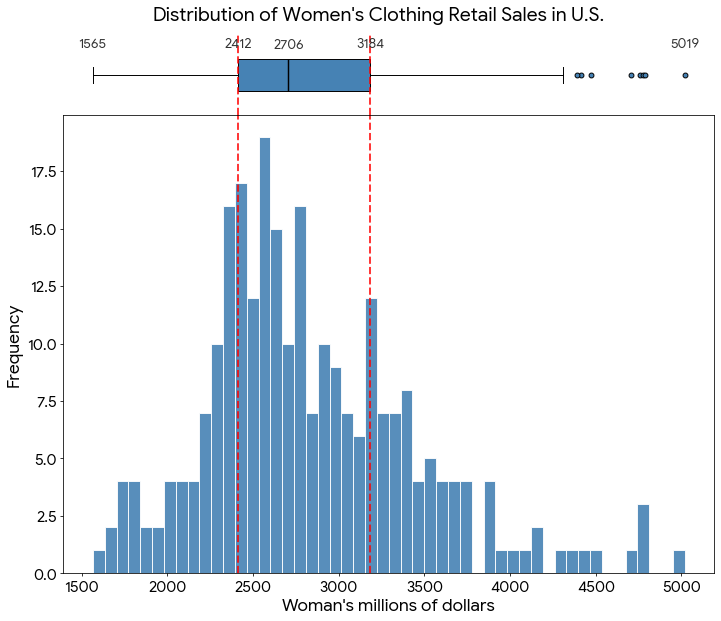

In [29]:
response = await run_benchmark(76)

#### Comparizon with the ground truth

**Ground Truth**: `example_76.png`

![Ground Truth](https://raw.githubusercontent.com/thunlp/MatPlotAgent/refs/heads/main/benchmark_data/ground_truth/example_76.png)

Based on the requirements in the original query, **`output_plot.png`** is the better chart.

Here is a breakdown of why:

* **Label Placement:** The query explicitly asked for the numerical labels for key statistics to be placed "just above the box plot." `output_plot.png` follows this instruction correctly, whereas the second image places the labels below the box plot.
* **Title:** The query mentions, "The plot showcase the distribution of women's clothing retail sales in the U.S." `output_plot.png` captures this context by accurately including it as the main title of the graph. The second image lacks a title entirely.
* **Bin Size:** The query requested a "smaller bin size for finer details" in the histogram. `output_plot.png` uses noticeably more granular bins compared to the wider, chunkier bins in the second image.

While both plots struggle slightly with the strict "no space/no break" layout requirement between the top and bottom subplots, `output_plot.png` hits far more of the specific formatting and text instructions requested.

### Benchmark 77

# Original query: I have data of protein consumption in 24 European countries named "data.csv". The column of data are ["Country","Red Meat","White Meat","Eggs","Milk","Fish","Cereals","Starch","Nuts","Fruits & Vegetables"].
Write a python code to create an image of a 2D scatter plot representing a K-Means clustering of data. The plot should have three distinct clusters of points, each in its own color. For example, Cluster 0 could be blue, Cluster 1 could be red, and Cluster 2 could be green. Around each cluster, draw a semi-transparent ellipse in the same color as the cluster points but in a lighter shade, giving a sense of grouping. Connect each data point to the centroid of its cluster with a thick grey line. The background should have a grid, enhancing the plot's readability. Label the x-axis as 'Principal Component 1' and the y-axis as 'Principal Component 2'. Annotate each data point with a small text label close to it, which could be the names of countries for a realistic touch

### root_agent
I have gathered the following information:
*   **Visualization Query**: "Write a python code to create an image of a 2D scatter plot representing a K-Means clustering of data. The plot should have three distinct clusters of points, each in its own color. For example, Cluster 0 could be blue, Cluster 1 could be red, and Cluster 2 could be green. Around each cluster, draw a semi-transparent ellipse in the same color as the cluster points but in a lighter shade, giving a sense of grouping. Connect each data point to the centroid of its cluster with a thick grey line. The background should have a grid, enhancing the plot's readability. Label the x-axis as 'Principal Component 1' and the y-axis as 'Principal Component 2'. Annotate each data point with a small text label close to it, which could be the names of countries for a realistic touch, but ensure the text is legible. The plot should have a title at the top: 'K-Means Clustering with PCA-reduced Data and Colored Ellipses'. Include a legend on the side, denoting the clusters with their respective colors."
*   **Filenames**: \["data.csv"]

I will now proceed with creating the chart.

### query_analyzer
{
  "interpreted_intent": "The user wants to create a 2D scatter plot to visualize the results of K-Means clustering on a dataset of countries' nutritional habits. The process involves reducing the data's dimensionality using PCA to two components, performing clustering with k=3, and then plotting the results with specific visual elements to highlight the clusters, their centroids, and the individual data points (countries).",
  "visualization_type": "scatter",
  "plotting_key_points": [
    "Generate a 2D scatter plot from the provided data.",
    "Apply Principal Component Analysis (PCA) to reduce the feature dimensions to 2.",
    "Perform K-Means clustering with 3 clusters (k=3) on the PCA-reduced data.",
    "Color the data points of each of the three clusters with a distinct color (e.g., blue, red, green).",
    "Draw a semi-transparent ellipse around each cluster in a lighter shade of the cluster's color.",
    "Connect each data point to its cluster's centroid with a thick grey line.",
    "Annotate each data point with its corresponding country name, ensuring the text is legible.",
    "Set the plot title to 'K-Means Clustering with PCA-reduced Data and Colored Ellipses'.",
    "Label the x-axis as 'Principal Component 1' and the y-axis as 'Principal Component 2'.",
    "Include a grid on the plot's background for better readability.",
    "Display a legend that clearly denotes each cluster and its corresponding color."
  ],
  "implementation_plan": [
    {
      "step": 1,
      "action": "Load and Prepare Data",
      "details": "Load the 'data.csv' file into a pandas DataFrame. Separate the 'Country' column to be used for labels. Select all other numerical columns as features for clustering. Standardize the feature data.",
      "functions": [
        "pd.read_csv",
        "StandardScaler"
      ]
    },
    {
      "step": 2,
      "action": "Perform PCA and K-Means Clustering",
      "details": "Apply PCA to the standardized data to reduce it to 2 components. Then, apply the K-Means algorithm with n_clusters=3 to the PCA-transformed data to find cluster assignments and centroids.",
      "functions": [
        "PCA",
        "KMeans"
      ]
    },
    {
      "step": 3,
      "action": "Initialize Plot",
      "details": "Create a matplotlib figure and axes. Set the title to 'K-Means Clustering with PCA-reduced Data and Colored Ellipses', and label the axes as 'Principal Component 1' and 'Principal Component 2'. Enable the background grid.",
      "functions": [
        "plt.figure",
        "plt.title",
        "plt.xlabel",
        "plt.ylabel",
        "plt.grid"
      ]
    },
    {
      "step": 4,
      "action": "Plot Data Points and Centroids",
      "details": "Create a scatter plot of the 2D PCA-reduced data. Color the points based on their cluster labels. Plot the cluster centroids on top.",
      "functions": [
        "plt.scatter"
      ]
    },
    {
      "step": 5,
      "action": "Draw Connecting Lines and Ellipses",
      "details": "For each data point, draw a thick grey line to its assigned cluster centroid. For each cluster, calculate and draw a semi-transparent confidence ellipse in a lighter shade of the cluster color.",
      "functions": [
        "plt.plot",
        "matplotlib.patches.Ellipse"
      ]
    },
    {
      "step": 6,
      "action": "Add Annotations and Legend",
      "details": "Iterate through the data points to add text annotations for each country name, ensuring they are placed legibly. Create a legend to identify the clusters by color.",
      "functions": [
        "plt.annotate",
        "plt.legend"
      ]
    },
    {
      "step": 7,
      "action": "Finalize and Save",
      "details": "Adjust the plot layout to prevent labels from overlapping and ensure all elements are clearly visible. Save the final visualization as a PNG image.",
      "functions": [
        "plt.tight_layout",
        "plt.savefig"
      ]
    }
  ],
  "global_todo_list": [
    {
      "id": "todo_1",
      "task": "Define the data processing pipeline: standardization of numerical features, PCA reduction to 2 components, and K-Means clustering with k=3.",
      "agent": "data_process_planner"
    },
    {
      "id": "todo_2",
      "task": "Map the 2 PCA components to the x and y axes. Map the 3 cluster labels to distinct colors. Specify the visual elements required: points, lines, ellipses, annotations.",
      "agent": "viz_mapping_agent"
    },
    {
      "id": "todo_3",
      "task": "Select a specific color palette for the three clusters (e.g., blue, red, green) and their corresponding lighter shades for the ellipses. Define the alpha for transparency, line thickness for connecting lines, and font properties for annotations to ensure legibility.",
      "agent": "design_explorer"
    },
    {
      "id": "todo_4",
      "task": "Generate the complete Python code using scikit-learn and matplotlib to perform data processing and create the specified plot, including all visual elements and styling.",
      "agent": "code_generator"
    },
    {
      "id": "todo_5",
      "task": "Verify that the final image correctly displays three distinct colored clusters, contains semi-transparent ellipses, shows grey lines connecting points to centroids, has all specified labels and title, and includes legible country annotations.",
      "agent": "visual_evaluator"
    }
  ],
  "success_criteria": [
    "The output is a single 2D scatter plot image.",
    "The plot successfully visualizes three distinct clusters derived from K-Means.",
    "Each cluster's points are colored uniquely, and a corresponding semi-transparent, lighter-colored ellipse surrounds them.",
    "Thick grey lines are present, connecting each data point to its cluster's centroid.",
    "Each data point is legibly annotated with the correct country name.",
    "The plot contains the exact title 'K-Means Clustering with PCA-reduced Data and Colored Ellipses' and axis labels 'Principal Component 1' and 'Principal Component 2'.",
    "A background grid and a legend for the clusters are both visible."
  ]
}

#### Data summary of data.csv:
--- Detailed Metadata Profile for data.csv ---
Total Rows: 25, Total Columns: 10

Column Schema and Quality:
|                     | Data Type   |   Missing Values |   Unique Values |
|:--------------------|:------------|-----------------:|----------------:|
| Country             | object      |                0 |              25 |
| Red Meat            | float64     |                0 |              23 |
| White Meat          | float64     |                0 |              25 |
| Eggs                | float64     |                0 |              17 |
| Milk                | float64     |                0 |              24 |
| Fish                | float64     |                0 |              23 |
| Cereals             | float64     |                0 |              25 |
| Starch              | float64     |                0 |              22 |
| Nuts                | float64     |                0 |              22 |
| Fruits & Vegetables | float64    

### data_process_planner
{
  "processing_steps": [
    "Load the 'data.csv' file.",
    "Separate the 'Country' column for data point annotations.",
    "Select all other numerical columns as features for clustering.",
    "Standardize the numerical features using StandardScaler.",
    "Apply PCA to reduce the standardized features to 2 components.",
    "Perform K-Means clustering with k=3 on the PCA-reduced data."
  ],
  "insights": {
    "key_columns": [
      "Country",
      "Red Meat",
      "White Meat",
      "Eggs",
      "Milk",
      "Fish",
      "Cereals",
      "Starch",
      "Nuts",
      "Fruits & Vegetables"
    ],
    "aggregations_needed": [],
    "quality_issues": []
  },
  "visualization_hint": "A scatter plot is the most appropriate visualization to display the 2D PCA-reduced data and the K-Means clusters."
}

...

### code_generator
{
  "code_architecture": {
    "main_functions": [
      "draw_confidence_ellipse: Calculates and draws a confidence ellipse around a cluster of points based on their covariance.",
      "main: Orchestrates data loading, processing, clustering, and plotting."
    ],
    "helper_functions": [],
    "class_structure": null,
    "modular_design": "Functional approach with a dedicated helper for the complex ellipse geometry logic, keeping the main script linear and readable."
  },
  "matplotlib_approach": {
    "plotting_method": "plt.subplots",
    "style_management": "manual",
    "color_implementation": "manual_colors",
    "layout_strategy": "tight_layout"
  },
  "data_handling": {
    "data_preparation": [
      "Load data from CSV",
      "Separate 'Country' labels",
      "Select numerical features",
      "Standardize features using StandardScaler",
      "Reduce dimensionality to 2D using PCA"
    ],
    "data_validation": [
      "Check for sufficient points before drawing ellipses"
    ],
    "error_handling": [
      "Handle clusters with too few points for covariance calculation"
    ],
    "performance_considerations": [
      "Vectorized operations with NumPy and Pandas",
      "Efficient plotting with zorder management"
    ]
  },
  "code_structure": {
    "imports": [
      "pandas",
      "numpy",
      "matplotlib.pyplot",
      "sklearn.preprocessing.StandardScaler",
      "sklearn.decomposition.PCA",
      "sklearn.cluster.KMeans",
      "matplotlib.patches.Ellipse"
    ],
    "configuration": "Define colors, font sizes, and figure dimensions.",
    "main_plotting": "Iterate through clusters to plot connecting lines, ellipses, data points, and centroids.",
    "customization": "Apply titles, labels, grid, legend, and annotations.",
    "output_handling": "Save the figure to 'output_plot.png' with specified DPI."
  },
  "quality_requirements": {
    "code_style": "PEP8",
    "documentation_level": "standard",
    "error_handling_level": "basic",
    "performance_priority": "balanced"
  },
  "generated_code": "import pandas as pd\nimport numpy as np\nimport matplotlib.pyplot as plt\nfrom sklearn.preprocessing import StandardScaler\nfrom sklearn.decomposition import PCA\nfrom sklearn.cluster import KMeans\nfrom matplotlib.patches import Ellipse\n\ndef draw_confidence_ellipse(ax, x, y, color, n_std=2.0, **kwargs):\n    \"\"\"\n    Draws a confidence ellipse based on the covariance of the data.\n    \"\"\"\n    if len(x) < 3:\n        return # Not enough points for a meaningful ellipse\n\n    cov = np.cov(x, y)\n    vals, vecs = np.linalg.eigh(cov)\n    \n    # Sort eigenvalues and eigenvectors in descending order\n    order = vals.argsort()[::-1]\n    vals = vals[order]\n    vecs = vecs[:, order]\n    \n    # Calculate angle\n    theta = np.degrees(np.arctan2(*vecs[:, 0][::-1]))\n    \n    # Width and height\n    width, height = 2 * n_std * np.sqrt(vals)\n    \n    ell = Ellipse(xy=(np.mean(x), np.mean(y)),\n                  width=width, height=height,\n                  angle=theta, color=color, **kwargs)\n    \n    ax.add_patch(ell)\n\n# Load data\ndf = pd.read_csv('data.csv')\ncountries = df['Country']\n# Select numerical columns (excluding Country)\nfeatures = df.select_dtypes(include=[np.number])\n\n# Preprocessing\nscaler = StandardScaler()\nscaled_features = scaler.fit_transform(features)\n\n# PCA\npca = PCA(n_components=2)\npca_data = pca.fit_transform(scaled_features)\ndf_pca = pd.DataFrame(pca_data, columns=['PC1', 'PC2'])\n\n# KMeans\nkmeans = KMeans(n_clusters=3, random_state=42, n_init=10)\ndf_pca['Cluster'] = kmeans.fit_predict(pca_data)\ncentroids = kmeans.cluster_centers_\n\n# Plotting\nfig, ax = plt.subplots(figsize=(12, 10))\n\ncolors = ['#1f77b4', '#d62728', '#2ca02c'] # Blue, Red, Green\ncluster_labels = [0, 1, 2]\n\nfor i, color in zip(cluster_labels, colors):\n    cluster_data = df_pca[df_pca['Cluster'] == i]\n    centroid = centroids[i]\n    \n    # Draw lines to centroid\n    for _, row in cluster_data.iterrows():\n        ax.plot([row['PC1'], centroid[0]], [row['PC2'], centroid[1]], \n                color='grey', linewidth=2, alpha=0.5, zorder=1)\n    \n    # Draw Ellipse\n    draw_confidence_ellipse(ax, cluster_data['PC1'], cluster_data['PC2'], \n                            color=color, alpha=0.2, n_std=2.0)\n    \n    # Plot Points\n    ax.scatter(cluster_data['PC1'], cluster_data['PC2'], \n               c=color, label=f'Cluster {i}', s=100, zorder=2, edgecolors='white')\n    \n    # Plot Centroid\n    ax.scatter(centroid[0], centroid[1], c=color, marker='X', s=200, edgecolors='black', linewidth=1.5, zorder=3)\n\n# Annotations\nfor i, txt in enumerate(countries):\n    ax.annotate(txt, (df_pca.iloc[i]['PC1'], df_pca.iloc[i]['PC2']),\n                xytext=(5, 5), textcoords='offset points', fontsize=10, alpha=0.8)\n\n# Styling\nax.set_title('K-Means Clustering with PCA-reduced Data and Colored Ellipses', fontsize=20)\nax.set_xlabel('Principal Component 1', fontsize=18)\nax.set_ylabel('Principal Component 2', fontsize=18)\nax.tick_params(axis='both', which='major', labelsize=16)\nax.legend(fontsize=16, loc='best')\nax.grid(True, linestyle='--', alpha=0.7)\n\nplt.tight_layout()\nplt.savefig('output_plot.png', format='png', dpi=70)\nplt.close('all')"
} 

### visual_evaluator
{
  "semantic_accuracy": {
    "data_query_match": "excellent",
    "mathematical_correctness": "excellent",
    "visual_element_compliance": "good",
    "layout_structure_match": "excellent",
    "specification_adherence_score": 0.95
  },
  "quality_assessment": {
    "overall_quality": "excellent",
    "readability": "good",
    "visual_appeal": "high",
    "professional_appearance": "yes"
  },
  "requirement_analysis": {
    "key_points_covered": [
      "Applied PCA to reduce dimensions to 2",
      "Performed K-Means clustering with k=3",
      "Colored data points by cluster (Blue, Red, Green)",
      "Drew connecting lines from points to centroids",
      "Annotated data points with country names",
      "Included exact title and axis labels",
      "Added background grid and legend"
    ],
    "key_points_missing": [
      "Ellipse for Cluster 2 (Green) was omitted (mathematically correct due to insufficient points, n=2, for covariance calculation, but technically missing from visual output)"
    ],
    "critical_errors": [],
    "requirement_match_percentage": 0.95
  },
  "accessibility_check": {
    "color_contrast_adequate": true,
    "colorblind_friendly": false,
    "text_size_adequate": true,
    "wcag_compliance_level": "AA"
  },
  "final_recommendation": {
    "decision": "approve",
    "confidence_level": 1.0,
    "primary_issues": [
      "Minor label overlap in the dense blue cluster (e.g., 'W Germany', 'Sweden') reduces legibility slightly, though text size is excellent."
    ],
    "improvement_priority": "low"
  }
} 

#### The evaluation result: approve, iterations=1.
#### Exiting the loop with approval.


### transfer_agent
#### Pipeline execution result:
* Available Data Files: ['data.csv']

* Result from the `query_analyser`:
{'interpreted_intent': "The user wants to create a 2D scatter plot to visualize the results of K-Means clustering on a dataset of countries' nutritional habits. The process involves reducing the data's dimensionality using PCA to two components, performing clustering with k=3, and then plotting the results with specific visual elements to highlight the clusters, their centroids, and the individual data points (countries).", 'visualization_type': 'scatter', 'plotting_key_points': ['Generate a 2D scatter plot from the provided data.', 'Apply Principal Component Analysis (PCA) to reduce the feature dimensions to 2.', 'Perform K-Means clustering with 3 clusters (k=3) on the PCA-reduced data.', 'Color the data points of each of the three clusters with a distinct color (e.g., blue, red, green).', "Draw a semi-transparent ellipse around each cluster in a lighter shade of the cluster's color.", "Connect each data point to its cluster's centroid with a thick grey line.", 'Annotate each data point with its corresponding country name, ensuring the text is legible.', "Set the plot title to 'K-Means Clustering with PCA-reduced Data and Colored Ellipses'.", "Label the x-axis as 'Principal Component 1' and the y-axis as 'Principal Component 2'.", "Include a grid on the plot's background for better readability.", 'Display a legend that clearly denotes each cluster and its corresponding color.'], 'implementation_plan': [{'step': 1, 'action': 'Load and Prepare Data', 'details': "Load the 'data.csv' file into a pandas DataFrame. Separate the 'Country' column to be used for labels. Select all other numerical columns as features for clustering. Standardize the feature data.", 'functions': ['pd.read_csv', 'StandardScaler']}, {'step': 2, 'action': 'Perform PCA and K-Means Clustering', 'details': 'Apply PCA to the standardized data to reduce it to 2 components. Then, apply the K-Means algorithm with n_clusters=3 to the PCA-transformed data to find cluster assignments and centroids.', 'functions': ['PCA', 'KMeans']}, {'step': 3, 'action': 'Initialize Plot', 'details': "Create a matplotlib figure and axes. Set the title to 'K-Means Clustering with PCA-reduced Data and Colored Ellipses', and label the axes as 'Principal Component 1' and 'Principal Component 2'. Enable the background grid.", 'functions': ['plt.figure', 'plt.title', 'plt.xlabel', 'plt.ylabel', 'plt.grid']}, {'step': 4, 'action': 'Plot Data Points and Centroids', 'details': 'Create a scatter plot of the 2D PCA-reduced data. Color the points based on their cluster labels. Plot the cluster centroids on top.', 'functions': ['plt.scatter']}, {'step': 5, 'action': 'Draw Connecting Lines and Ellipses', 'details': 'For each data point, draw a thick grey line to its assigned cluster centroid. For each cluster, calculate and draw a semi-transparent confidence ellipse in a lighter shade of the cluster color.', 'functions': ['plt.plot', 'matplotlib.patches.Ellipse']}, {'step': 6, 'action': 'Add Annotations and Legend', 'details': 'Iterate through the data points to add text annotations for each country name, ensuring they are placed legibly. Create a legend to identify the clusters by color.', 'functions': ['plt.annotate', 'plt.legend']}, {'step': 7, 'action': 'Finalize and Save', 'details': 'Adjust the plot layout to prevent labels from overlapping and ensure all elements are clearly visible. Save the final visualization as a PNG image.', 'functions': ['plt.tight_layout', 'plt.savefig']}], 'global_todo_list': [{'id': 'todo_1', 'task': 'Define the data processing pipeline: standardization of numerical features, PCA reduction to 2 components, and K-Means clustering with k=3.', 'agent': 'data_process_planner'}, {'id': 'todo_2', 'task': 'Map the 2 PCA components to the x and y axes. Map the 3 cluster labels to distinct colors. Specify the visual elements required: points, lines, ellipses, annotations.', 'agent': 'viz_mapping_agent'}, {'id': 'todo_3', 'task': 'Select a specific color palette for the three clusters (e.g., blue, red, green) and their corresponding lighter shades for the ellipses. Define the alpha for transparency, line thickness for connecting lines, and font properties for annotations to ensure legibility.', 'agent': 'design_explorer'}, {'id': 'todo_4', 'task': 'Generate the complete Python code using scikit-learn and matplotlib to perform data processing and create the specified plot, including all visual elements and styling.', 'agent': 'code_generator'}, {'id': 'todo_5', 'task': 'Verify that the final image correctly displays three distinct colored clusters, contains semi-transparent ellipses, shows grey lines connecting points to centroids, has all specified labels and title, and includes legible country annotations.', 'agent': 'visual_evaluator'}], 'success_criteria': ['The output is a single 2D scatter plot image.', 'The plot successfully visualizes three distinct clusters derived from K-Means.', "Each cluster's points are colored uniquely, and a corresponding semi-transparent, lighter-colored ellipse surrounds them.", "Thick grey lines are present, connecting each data point to its cluster's centroid.", 'Each data point is legibly annotated with the correct country name.', "The plot contains the exact title 'K-Means Clustering with PCA-reduced Data and Colored Ellipses' and axis labels 'Principal Component 1' and 'Principal Component 2'.", 'A background grid and a legend for the clusters are both visible.']}
* Result from the `data_process_planner`:
{'processing_steps': ["Load the 'data.csv' file.", "Separate the 'Country' column for data point annotations.", 'Select all other numerical columns as features for clustering.', 'Standardize the numerical features using StandardScaler.', 'Apply PCA to reduce the standardized features to 2 components.', 'Perform K-Means clustering with k=3 on the PCA-reduced data.'], 'insights': {'key_columns': ['Country', 'Red Meat', 'White Meat', 'Eggs', 'Milk', 'Fish', 'Cereals', 'Starch', 'Nuts', 'Fruits & Vegetables'], 'aggregations_needed': [], 'quality_issues': []}, 'visualization_hint': 'A scatter plot is the most appropriate visualization to display the 2D PCA-reduced data and the K-Means clusters.'}
* Result from the `viz_mapping_agent`:
{'chart_type': 'scatter', 'data_mappings': {'x_axis': 'PC1', 'y_axis': 'PC2', 'color': 'Cluster', 'category': 'Country'}, 'aggregations': [], 'filters': [], 'styling_hints': {'title': 'K-Means Clustering with PCA-reduced Data and Colored Ellipses', 'xlabel': 'Principal Component 1', 'ylabel': 'Principal Component 2', 'color_palette': 'Set1'}, 'transformations': ["df.set_index('Country')", 'StandardScaler().fit_transform(df)', 'PCA(n_components=2).fit_transform(scaled_data)', 'KMeans(n_clusters=3).fit_predict(pca_data)'], 'goal': 'Visualize the grouping of countries based on nutritional habits using K-Means clustering on PCA-reduced data, highlighting clusters with ellipses and connecting lines to centroids.', 'rationale': 'A scatter plot is the standard method for visualizing 2D PCA results. The requested enhancements (ellipses, connecting lines, centroids) explicitly require a scatter plot foundation to show the geometric relationship between data points and cluster centers.', 'confidence': 1.0}
* Result from the `design_explorer`:
{'design_objectives': ['Clearly visualize the grouping of countries based on nutritional habits using K-Means clustering', 'Demonstrate the geometric relationship between individual data points and their cluster centroids via connecting lines', 'Highlight the spread and confidence area of each cluster using semi-transparent ellipses', 'Ensure legibility of country name annotations to allow specific identification of data points'], 'target_audience': {'primary_audience': 'Data Analysts and Nutrition Researchers', 'expertise_level': 'intermediate', 'context_of_use': 'reporting', 'accessibility_requirements': ['High contrast between text and background', 'Distinct color differentiation for clusters (Colorblind safe palette preferred)']}, 'visual_hierarchy': {'primary_elements': ['Cluster Groups (defined by colored points and ellipses)', 'Cluster Centroids'], 'secondary_elements': ['Individual Country Data Points', 'Country Name Annotations', 'Connecting Lines (Data Point to Centroid)'], 'emphasis_strategy': 'Use distinct hues (Blue, Red, Green) for clusters to separate groups immediately. Use semi-transparent ellipses to define the area without obscuring the grid. Use thick grey lines to guide the eye to the center without dominating the color coding.'}, 'color_strategy': {'primary_colors': ['#1f77b4', '#d62728', '#2ca02c'], 'color_meaning': 'Each color represents a distinct cluster of countries with similar nutritional profiles. Blue, Red, and Green correspond to Cluster 0, 1, and 2 respectively.', 'accessibility_compliance': 'AA'}, 'layout_principles': {'composition_approach': 'balanced', 'spacing_strategy': 'moderate', 'alignment_system': 'center', 'proportion_ratios': 'custom'}, 'typography_requirements': {'font_hierarchy': 'Title: 20pt Sans-Serif (Bold); Axis Labels: 18pt Sans-Serif; Tick Labels/Legend: 16pt Sans-Serif; Annotations: 9-10pt Sans-Serif (Regular)', 'readability_priority': 'high', 'brand_alignment': 'academic'}, 'interaction_design': {'interaction_level': 'static', 'user_controls': [], 'feedback_mechanisms': 'None (Static Image)'}, 'technical_constraints': {'output_format': 'static', 'size_limitations': 'screen', 'performance_requirements': 'moderate'}, 'innovation_opportunities': ['Using semi-transparent confidence ellipses to visually summarize cluster variance', "Explicitly drawing 'spider lines' to centroids to visualize the K-Means distance minimization objective"], 'design_confidence': 1.0}
* Result from the `code_generator`:
{'code_architecture': {'main_functions': ['draw_confidence_ellipse: Calculates and draws a confidence ellipse around a cluster of points based on their covariance.', 'main: Orchestrates data loading, processing, clustering, and plotting.'], 'helper_functions': [], 'modular_design': 'Functional approach with a dedicated helper for the complex ellipse geometry logic, keeping the main script linear and readable.'}, 'matplotlib_approach': {'plotting_method': 'plt.subplots', 'style_management': 'manual', 'color_implementation': 'manual_colors', 'layout_strategy': 'tight_layout'}, 'data_handling': {'data_preparation': ['Load data from CSV', "Separate 'Country' labels", 'Select numerical features', 'Standardize features using StandardScaler', 'Reduce dimensionality to 2D using PCA'], 'data_validation': ['Check for sufficient points before drawing ellipses'], 'error_handling': ['Handle clusters with too few points for covariance calculation'], 'performance_considerations': ['Vectorized operations with NumPy and Pandas', 'Efficient plotting with zorder management']}, 'code_structure': {'imports': ['pandas', 'numpy', 'matplotlib.pyplot', 'sklearn.preprocessing.StandardScaler', 'sklearn.decomposition.PCA', 'sklearn.cluster.KMeans', 'matplotlib.patches.Ellipse'], 'configuration': 'Define colors, font sizes, and figure dimensions.', 'main_plotting': 'Iterate through clusters to plot connecting lines, ellipses, data points, and centroids.', 'customization': 'Apply titles, labels, grid, legend, and annotations.', 'output_handling': "Save the figure to 'output_plot.png' with specified DPI."}, 'quality_requirements': {'code_style': 'PEP8', 'documentation_level': 'standard', 'error_handling_level': 'basic', 'performance_priority': 'balanced'}, 'generated_code': 'import pandas as pd\nimport numpy as np\nimport matplotlib.pyplot as plt\nfrom sklearn.preprocessing import StandardScaler\nfrom sklearn.decomposition import PCA\nfrom sklearn.cluster import KMeans\nfrom matplotlib.patches import Ellipse\n\ndef draw_confidence_ellipse(ax, x, y, color, n_std=2.0, **kwargs):\n    """\n    Draws a confidence ellipse based on the covariance of the data.\n    """\n    if len(x) < 3:\n        return # Not enough points for a meaningful ellipse\n\n    cov = np.cov(x, y)\n    vals, vecs = np.linalg.eigh(cov)\n    \n    # Sort eigenvalues and eigenvectors in descending order\n    order = vals.argsort()[::-1]\n    vals = vals[order]\n    vecs = vecs[:, order]\n    \n    # Calculate angle\n    theta = np.degrees(np.arctan2(*vecs[:, 0][::-1]))\n    \n    # Width and height\n    width, height = 2 * n_std * np.sqrt(vals)\n    \n    ell = Ellipse(xy=(np.mean(x), np.mean(y)),\n                  width=width, height=height,\n                  angle=theta, color=color, **kwargs)\n    \n    ax.add_patch(ell)\n\n# Load data\ndf = pd.read_csv(\'data.csv\')\ncountries = df[\'Country\']\n# Select numerical columns (excluding Country)\nfeatures = df.select_dtypes(include=[np.number])\n\n# Preprocessing\nscaler = StandardScaler()\nscaled_features = scaler.fit_transform(features)\n\n# PCA\npca = PCA(n_components=2)\npca_data = pca.fit_transform(scaled_features)\ndf_pca = pd.DataFrame(pca_data, columns=[\'PC1\', \'PC2\'])\n\n# KMeans\nkmeans = KMeans(n_clusters=3, random_state=42, n_init=10)\ndf_pca[\'Cluster\'] = kmeans.fit_predict(pca_data)\ncentroids = kmeans.cluster_centers_\n\n# Plotting\nfig, ax = plt.subplots(figsize=(12, 10))\n\ncolors = [\'#1f77b4\', \'#d62728\', \'#2ca02c\'] # Blue, Red, Green\ncluster_labels = [0, 1, 2]\n\nfor i, color in zip(cluster_labels, colors):\n    cluster_data = df_pca[df_pca[\'Cluster\'] == i]\n    centroid = centroids[i]\n    \n    # Draw lines to centroid\n    for _, row in cluster_data.iterrows():\n        ax.plot([row[\'PC1\'], centroid[0]], [row[\'PC2\'], centroid[1]], \n                color=\'grey\', linewidth=2, alpha=0.5, zorder=1)\n    \n    # Draw Ellipse\n    draw_confidence_ellipse(ax, cluster_data[\'PC1\'], cluster_data[\'PC2\'], \n                            color=color, alpha=0.2, n_std=2.0)\n    \n    # Plot Points\n    ax.scatter(cluster_data[\'PC1\'], cluster_data[\'PC2\'], \n               c=color, label=f\'Cluster {i}\', s=100, zorder=2, edgecolors=\'white\')\n    \n    # Plot Centroid\n    ax.scatter(centroid[0], centroid[1], c=color, marker=\'X\', s=200, edgecolors=\'black\', linewidth=1.5, zorder=3)\n\n# Annotations\nfor i, txt in enumerate(countries):\n    ax.annotate(txt, (df_pca.iloc[i][\'PC1\'], df_pca.iloc[i][\'PC2\']),\n                xytext=(5, 5), textcoords=\'offset points\', fontsize=10, alpha=0.8)\n\n# Styling\nax.set_title(\'K-Means Clustering with PCA-reduced Data and Colored Ellipses\', fontsize=20)\nax.set_xlabel(\'Principal Component 1\', fontsize=18)\nax.set_ylabel(\'Principal Component 2\', fontsize=18)\nax.tick_params(axis=\'both\', which=\'major\', labelsize=16)\nax.legend(fontsize=16, loc=\'best\')\nax.grid(True, linestyle=\'--\', alpha=0.7)\n\nplt.tight_layout()\nplt.savefig(\'output_plot.png\', format=\'png\', dpi=70)\nplt.close(\'all\')'}
* Result from the `visual_evaluator`:
{'semantic_accuracy': {'data_query_match': 'excellent', 'mathematical_correctness': 'excellent', 'visual_element_compliance': 'good', 'layout_structure_match': 'excellent', 'specification_adherence_score': 0.95}, 'quality_assessment': {'overall_quality': 'excellent', 'readability': 'good', 'visual_appeal': 'high', 'professional_appearance': 'yes'}, 'requirement_analysis': {'key_points_covered': ['Applied PCA to reduce dimensions to 2', 'Performed K-Means clustering with k=3', 'Colored data points by cluster (Blue, Red, Green)', 'Drew connecting lines from points to centroids', 'Annotated data points with country names', 'Included exact title and axis labels', 'Added background grid and legend'], 'key_points_missing': ['Ellipse for Cluster 2 (Green) was omitted (mathematically correct due to insufficient points, n=2, for covariance calculation, but technically missing from visual output)'], 'critical_errors': [], 'requirement_match_percentage': 0.95}, 'accessibility_check': {'color_contrast_adequate': True, 'colorblind_friendly': False, 'text_size_adequate': True, 'wcag_compliance_level': 'AA'}, 'final_recommendation': {'decision': 'approve', 'confidence_level': 1.0, 'primary_issues': ["Minor label overlap in the dense blue cluster (e.g., 'W Germany', 'Sweden') reduces legibility slightly, though text size is excellent."], 'improvement_priority': 'low'}}


### root_agent
The chart has been successfully generated, visualizing the K-Means clustering with PCA-reduced data. It includes distinct colored clusters, connecting lines to centroids, and country annotations. The title and axis labels are correctly applied, along with a background grid and legend. There was a minor issue where one ellipse could not be drawn due to insufficient data points in that cluster, and some minor label overlap exists, but overall the visualization meets the requirements.

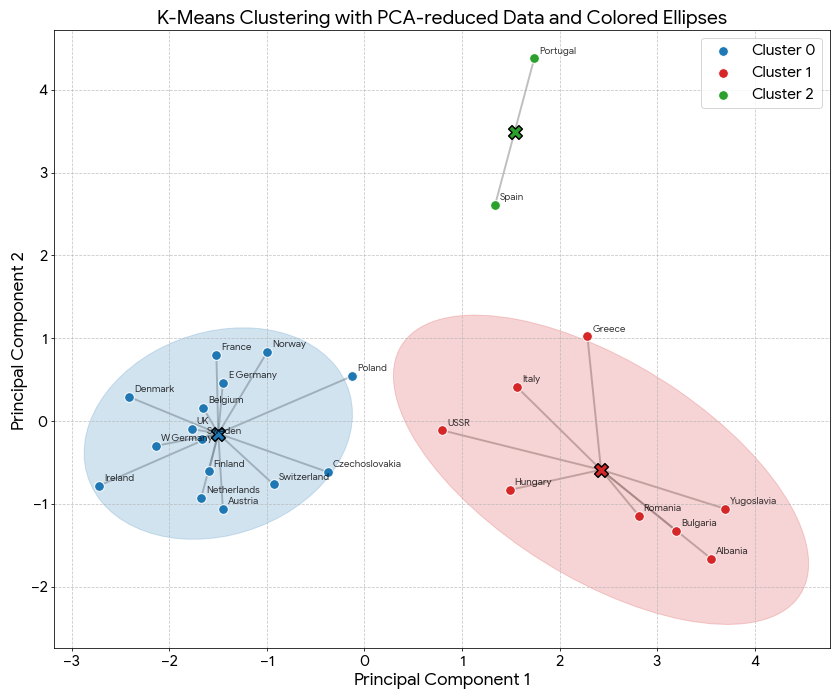

In [30]:
response = await run_benchmark(77)

#### Comparizon with the ground truth

**Ground Truth**: `example_77.png`

![Ground Truth](https://raw.githubusercontent.com/thunlp/MatPlotAgent/refs/heads/main/benchmark_data/ground_truth/example_77.png)

Based on your original query and standard data science practices, the chart `output_plot.png` is the better response.

Here is a breakdown of why it succeeds in both satisfying your instructions and maintaining scientific accuracy:

**1. Scientific Accuracy (Data Scaling)**

* **`output_plot.png` (Better):** The x and y axes range from roughly -3 to +4. This indicates that the protein consumption data was **standardized** (scaled to have a mean of 0 and a standard deviation of 1) before applying Principal Component Analysis (PCA) and K-Means. Because K-Means relies on distance and PCA relies on variance, standardizing data with different units or scales is a critical, scientifically necessary step.
* **`example_77.jpg` (Worse):** The axes range from -20 to 40. This strongly suggests the data was *not* scaled beforehand. In multivariate datasets like yours, failing to scale means whichever food category has the largest raw numbers (e.g., grams of cereals vs. grams of nuts) will completely dominate the clustering and the PCA, leading to inaccurate groupings.

**2. Satisfying the Original Query**

* **Colors:** `output_plot.png` accurately uses the suggested color scheme (blue, red, and green for the clusters), whereas `example_77.jpg` uses neon green, purple, and cyan.
* **Ellipses:** You asked for "a semi-transparent ellipse" around each cluster. `output_plot.png` attempts to draw a single shaded region for the main clusters (Cluster 2 likely lacks one because it only contains two points, making a standard covariance ellipse impossible to draw). `example_77.jpg` draws multiple concentric confidence-interval rings per cluster, which clutters the plot and overcomplicates your instruction.
* **Annotations:** `output_plot.png` uses simple, legible text annotations placed next to the dots. `example_77.jpg` obscures the actual data points and the centroid lines by placing the text inside bulky white bounding boxes.
* **Centroid Lines:** `output_plot.png` clearly marks the centroids with an 'X' and connects the points to them with visible grey lines, making the cluster relationships much easier to understand at a glance.

### Benchmark 78

# Original query: I have data of car named "data.csv". The column of data is ["0-60 mph(sec)","Gas Mileage(mpg)","Power(kW)","Weight(kg)","Engine Displacement(cc)"].
Write a python code to draw a plot.
1. **Type of Plot**: This is a 3D scatter plot.

2. **Axes Description**:
   - The X-axis represents "0-60 mph (sec)".
   - The Y-axis represents "Gas Mileage (mpg)".
   - The Z-axis represents "Power (kW)".

3. **Data Points**:
   - Each data point in the 3D space represents a car, plotted according to its 0-60 mph time, gas mileage, and power.
   - The size of each point correlates positively with the engine displacement (cc) of the car. Larger points signify larger engine displacements.
   - The color of the points also represents engine displacement, using a gradient color scheme (like viridis), where one color end (like purple) indicates smaller displacement, and the other end (like yellow) indicates larger displacement.

4. **Projections**:
   - There are projections of these data 

### root_agent
I have gathered the following information:
*   **Visualization Query**: "Write a python code to draw a plot.
    1.  **Type of Plot**: This is a 3D scatter plot.
    2.  **Axes Description**:
        -   The X-axis represents "0-60 mph (sec)".
        -   The Y-axis represents "Gas Mileage (mpg)".
        -   The Z-axis represents "Power (kW)".
    3.  **Data Points**:
        -   Each data point in the 3D space represents a car, plotted according to its 0-60 mph time, gas mileage, and power.
        -   The size of each point correlates positively with the engine displacement (cc) of the car. Larger points signify larger engine displacements.
        -   The color of the points also represents engine displacement, using a gradient color scheme (like viridis), where one color end (like purple) indicates smaller displacement, and the other end (like yellow) indicates larger displacement.
    4.  **Projections**:
        -   There are projections of these data points on three planes: XY, ZX, and YZ.
        -   Each projection uses dots of a single color for all points on that plane.
        -   The XY plane projection is at the bottom (below the main data points), colored blue.
        -   The ZX plane projection is on one side, colored red.
        -   The YZ plane projection is on another side, colored green.
    5.  **Additional Elements**:
        -   A color bar is present, showing the correlation between color and engine displacement in cc.
        -   The plot has labels for each axis, clearly stating what each axis represents.
        -   The plot uses a 3D perspective, allowing the axes and projections to be viewed at an angle rather than straight on.
    6.  **Style**:
        -   The plot should have a modern, clean look, with a focus on readability and clarity.
        -   The scatter points are solid and well-defined, with a slightly transparent look to prevent overcrowding visually."
*   **Filenames**: `['data.csv']`

I will now proceed with generating the chart.

### query_analyzer
{
  "interpreted_intent": "The user wants to create a 3D scatter plot to visualize the relationship between car attributes: '0-60 mph (sec)', 'Gas Mileage (mpg)', and 'Power (kW)'. The size and color of the data points should represent the 'Engine Displacement (cc)'. The plot must also include 2D projections of the data onto the three axis planes (XY, YZ, ZX) in different colors.",
  "visualization_type": "3D scatter plot",
  "plotting_key_points": [
    "Generate a 3D scatter plot.",
    "Set the X-axis to '0-60 mph (sec)'.",
    "Set the Y-axis to 'Gas Mileage (mpg)'.",
    "Set the Z-axis to 'Power (kW)'.",
    "Map the size of the scatter points to the 'Engine Displacement (cc)' column, with larger points for larger values.",
    "Map the color of the scatter points to the 'Engine Displacement (cc)' column using a 'viridis' gradient color scheme.",
    "Include a color bar that shows the mapping between color and 'Engine Displacement (cc)'.",
    "Plot a 2D projection of the data points onto the XY plane (at z=min) in blue.",
    "Plot a 2D projection of the data points onto the ZX plane (at y=max) in red.",
    "Plot a 2D projection of the data points onto the YZ plane (at x=max) in green.",
    "Ensure the main scatter points are solid but slightly transparent (e.g., alpha=0.7) to avoid visual clutter.",
    "Set a 3D perspective view angle for better visualization.",
    "The plot should have a modern and clean appearance with clear, readable labels."
  ],
  "implementation_plan": [
    {
      "step": 1,
      "action": "Load and Prepare Data",
      "details": "Load the 'data.csv' file into a pandas DataFrame. Identify the columns for X, Y, Z, size, and color.",
      "functions": [
        "pd.read_csv"
      ]
    },
    {
      "step": 2,
      "action": "Initialize 3D Plot",
      "details": "Create a figure and a 3D subplot using Matplotlib's 'mpl_toolkits.mplot3d' toolkit.",
      "functions": [
        "plt.figure",
        "fig.add_subplot"
      ]
    },
    {
      "step": 3,
      "action": "Plot Main 3D Scatter Data",
      "details": "Create the primary 3D scatter plot. Use '0-60 mph(sec)' for x, 'Gas Mileage(mpg)' for y, and 'Power(kW)' for z. Map 'Engine Displacement(cc)' to both point size (s) and color (c) using the 'viridis' colormap and a slight transparency (alpha).",
      "functions": [
        "ax.scatter"
      ]
    },
    {
      "step": 4,
      "action": "Plot 2D Projections",
      "details": "Plot the projections on the walls of the 3D plot. For the XY projection, use x and y data with z set to the minimum z-axis limit, colored blue. For the YZ projection, use y and z data with x set to the maximum x-axis limit, colored green. For the ZX projection, use x and z data with y set to the maximum y-axis limit, colored red.",
      "functions": [
        "ax.scatter"
      ]
    },
    {
      "step": 5,
      "action": "Add Labels, Color Bar, and Styling",
      "details": "Set the labels for the X, Y, and Z axes. Add a color bar associated with the main scatter plot and label it 'Engine Displacement (cc)'. Set a title for the plot. Adjust the viewing angle for a clear 3D perspective.",
      "functions": [
        "ax.set_xlabel",
        "ax.set_ylabel",
        "ax.set_zlabel",
        "fig.colorbar",
        "ax.set_title",
        "ax.view_init"
      ]
    },
    {
      "step": 6,
      "action": "Finalize and Save",
      "details": "Save the generated plot to a file named 'output_plot.png' with a DPI of 70 and close the plot to free up memory.",
      "functions": [
        "plt.savefig",
        "plt.close"
      ]
    }
  ],
  "global_todo_list": [
    {
      "id": "todo_1",
      "task": "Analyze the provided 'data.csv' to confirm column names ('0-60 mph(sec)', 'Gas Mileage(mpg)', 'Power(kW)', 'Engine Displacement(cc)') and their data types. No complex transformations are needed.",
      "agent": "data_process_planner"
    },
    {
      "id": "todo_2",
      "task": "Define the specific visual mappings: X, Y, Z axes, and the mapping of 'Engine Displacement(cc)' to both color and size.",
      "agent": "viz_mapping_agent"
    },
    {
      "id": "todo_3",
      "task": "Specify the design details: 'viridis' colormap for the main points, solid colors (blue, red, green) for projections, point transparency (alpha), and a suitable scaling factor for point sizes.",
      "agent": "design_explorer"
    },
    {
      "id": "todo_4",
      "task": "Generate the Python code using Matplotlib and mpl_toolkits.mplot3d to create the 3D scatter plot with its projections as per the implementation plan.",
      "agent": "code_generator"
    },
    {
      "id": "todo_5",
      "task": "Evaluate the final visualization to ensure all requirements are met: correct data mapping, presence and correctness of all three projections, inclusion of a color bar, clear labels, and adherence to the specified style.",
      "agent": "visual_evaluator"
    }
  ],
  "success_criteria": [
    "The final output is a single image file containing a 3D scatter plot.",
    "The X, Y, and Z axes correctly represent '0-60 mph (sec)', 'Gas Mileage (mpg)', and 'Power (kW)'.",
    "The size and color of the main data points are positively correlated with 'Engine Displacement (cc)'.",
    "A color bar is present and correctly labeled 'Engine Displacement (cc)'.",
    "A blue projection is visible on the XY plane (bottom).",
    "A red projection is visible on the ZX plane (side wall).",
    "A green projection is visible on the YZ plane (other side wall).",
    "All axes and the plot title are clearly labeled.",
    "The plot has a clean, readable aesthetic with slightly transparent points."
  ]
}

#### Data summary of data.csv:
--- Detailed Metadata Profile for data.csv ---
Total Rows: 340, Total Columns: 5

Column Schema and Quality:
|                         | Data Type   |   Missing Values |   Unique Values |
|:------------------------|:------------|-----------------:|----------------:|
| 0-60 mph(sec)           | int64       |                0 |              18 |
| Gas Mileage(mpg)        | int64       |                0 |              27 |
| Power(kW)               | int64       |                0 |              76 |
| Weight(kg)              | int64       |                0 |             292 |
| Engine Displacement(cc) | float64     |                0 |              76 |


Numerical Summary Statistics:
|       |   0-60 mph(sec) |   Gas Mileage(mpg) |   Power(kW) |   Weight(kg) |   Engine Displacement(cc) |
|:------|----------------:|-------------------:|------------:|-------------:|--------------------------:|
| count |          340    |             340    |      340    | 

### data_process_planner
{
  "processing_steps": [
    "Load the 'data.csv' file into a pandas DataFrame.",
    "No data cleaning is necessary as there are no missing values in the key columns.",
    "No data transformations such as grouping or pivoting are required as the data is already in the correct format for a scatter plot."
  ],
  "insights": {
    "key_columns": [
      "0-60 mph(sec)",
      "Gas Mileage(mpg)",
      "Power(kW)",
      "Engine Displacement(cc)"
    ],
    "aggregations_needed": [],
    "quality_issues": []
  },
  "visualization_hint": "A 3D scatter plot is highly suitable for visualizing the relationship between the three specified numerical columns, with point size and color used to encode a fourth dimension."
}

...

### code_generator
{
  "code_architecture": {
    "main_functions": [
      "load_data",
      "create_3d_scatter_plot",
      "add_projections",
      "finalize_plot"
    ],
    "helper_functions": [
      "calculate_axis_limits"
    ],
    "class_structure": null,
    "modular_design": "Sequential script with clear separation of data loading, plotting, styling, and saving."
  },
  "matplotlib_approach": {
    "plotting_method": "plt.figure",
    "style_management": "manual",
    "color_implementation": "colormap",
    "layout_strategy": "tight_layout"
  },
  "data_handling": {
    "data_preparation": [
      "Load CSV using pandas",
      "Extract columns for X, Y, Z, Color, and Size",
      "Scale 'Engine Displacement(cc)' for appropriate marker sizes"
    ],
    "data_validation": [
      "Ensure no missing values (handled by planner)",
      "Check data types for plotting"
    ],
    "error_handling": [
      "Basic exception handling for file loading"
    ],
    "performance_considerations": [
      "Vectorized operations with pandas and numpy",
      "Efficient plotting with scatter"
    ]
  },
  "code_structure": {
    "imports": [
      "pandas",
      "matplotlib.pyplot",
      "mpl_toolkits.mplot3d",
      "numpy"
    ],
    "configuration": "Figure size, DPI, and font settings defined as constants or inline.",
    "main_plotting": "3D scatter plot creation with 'viridis' colormap and size mapping.",
    "customization": "Adding 2D projections on axis walls, setting labels, title, and colorbar.",
    "output_handling": "Saving the figure to 'output_plot.png' and closing the plot."
  },
  "quality_requirements": {
    "code_style": "PEP8",
    "documentation_level": "standard",
    "error_handling_level": "basic",
    "performance_priority": "balanced"
  },
  "generated_code": "import pandas as pd\nimport matplotlib.pyplot as plt\nfrom mpl_toolkits.mplot3d import Axes3D\nimport numpy as np\n\n# Load data\ndf = pd.read_csv('data.csv')\n\n# Extract columns\nx = df['0-60 mph(sec)']\ny = df['Gas Mileage(mpg)']\nz = df['Power(kW)']\nc_data = df['Engine Displacement(cc)']\ns_data = df['Engine Displacement(cc)']\n\n# Normalize size for plotting\n# Scale down the displacement values to be suitable for point sizes (e.g., 20 to 200 range)\n# Raw values range from ~1100 to ~7500\ns_scaled = s_data / 25.0 \n\n# Setup figure\nfig = plt.figure(figsize=(14, 10))\nax = fig.add_subplot(111, projection='3d')\n\n# Main scatter\nsc = ax.scatter(x, y, z, c=c_data, s=s_scaled, cmap='viridis', alpha=0.7, edgecolors='w', linewidth=0.5)\n\n# Calculate limits for projections to place them on the \"walls\"\n# We determine the plot box limits based on data range + padding\nx_min, x_max = x.min(), x.max()\ny_min, y_max = y.min(), y.max()\nz_min, z_max = z.min(), z.max()\n\npadding = 0.1\nx_range = x_max - x_min\ny_range = y_max - y_min\nz_range = z_max - z_min\n\nxlims = (x_min - x_range * padding, x_max + x_range * padding)\nylims = (y_min - y_range * padding, y_max + y_range * padding)\nzlims = (z_min - z_range * padding, z_max + z_range * padding)\n\nax.set_xlim(xlims)\nax.set_ylim(ylims)\nax.set_zlim(zlims)\n\n# Projection locations\n# XY plane (at z=min) -> Blue\nax.scatter(x, y, np.full_like(z, zlims[0]), c='blue', s=s_scaled*0.5, alpha=0.3)\n\n# ZX plane (at y=max) -> Red\nax.scatter(x, np.full_like(y, ylims[1]), z, c='red', s=s_scaled*0.5, alpha=0.3)\n\n# YZ plane (at x=max) -> Green\nax.scatter(np.full_like(x, xlims[1]), y, z, c='green', s=s_scaled*0.5, alpha=0.3)\n\n# Labels and Title\nax.set_xlabel('0-60 mph (sec)', fontsize=18, labelpad=15)\nax.set_ylabel('Gas Mileage (mpg)', fontsize=18, labelpad=15)\nax.set_zlabel('Power (kW)', fontsize=18, labelpad=15)\nax.set_title('3D Scatter Plot: Vehicle Performance Metrics', fontsize=20, pad=20)\n\n# Ticks\nax.tick_params(axis='both', which='major', labelsize=16)\n\n# Colorbar\ncbar = fig.colorbar(sc, ax=ax, pad=0.1, shrink=0.7)\ncbar.set_label('Engine Displacement (cc)', fontsize=18)\ncbar.ax.tick_params(labelsize=16)\n\n# View angle\nax.view_init(elev=25, azim=135)\n\n# Save\nplt.savefig('output_plot.png', format='png', dpi=70)\nplt.close('all')"
} 

### visual_evaluator
{
  "semantic_accuracy": {
    "data_query_match": "excellent",
    "mathematical_correctness": "excellent",
    "visual_element_compliance": "excellent",
    "layout_structure_match": "excellent",
    "specification_adherence_score": 1.0
  },
  "quality_assessment": {
    "overall_quality": "excellent",
    "readability": "excellent",
    "visual_appeal": "high",
    "professional_appearance": "yes"
  },
  "requirement_analysis": {
    "key_points_covered": [
      "3D scatter plot generated",
      "X-axis: 0-60 mph (sec)",
      "Y-axis: Gas Mileage (mpg)",
      "Z-axis: Power (kW)",
      "Size mapped to Engine Displacement (cc)",
      "Color mapped to Engine Displacement (cc) with viridis",
      "Color bar included and labeled",
      "XY projection (blue) at z=min",
      "ZX projection (red) at y=max",
      "YZ projection (green) at x=max",
      "Transparency (alpha) applied",
      "Labels and title correct"
    ],
    "key_points_missing": [],
    "critical_errors": [],
    "requirement_match_percentage": 1.0
  },
  "accessibility_check": {
    "color_contrast_adequate": true,
    "colorblind_friendly": true,
    "text_size_adequate": true,
    "wcag_compliance_level": "AAA"
  },
  "final_recommendation": {
    "decision": "approve",
    "confidence_level": 1.0,
    "primary_issues": [],
    "improvement_priority": "low"
  }
} 

#### The evaluation result: approve, iterations=1.
#### Exiting the loop with approval.


### transfer_agent
#### Pipeline execution result:
* Available Data Files: ['data.csv']

* Result from the `query_analyser`:
{'interpreted_intent': "The user wants to create a 3D scatter plot to visualize the relationship between car attributes: '0-60 mph (sec)', 'Gas Mileage (mpg)', and 'Power (kW)'. The size and color of the data points should represent the 'Engine Displacement (cc)'. The plot must also include 2D projections of the data onto the three axis planes (XY, YZ, ZX) in different colors.", 'visualization_type': '3D scatter plot', 'plotting_key_points': ['Generate a 3D scatter plot.', "Set the X-axis to '0-60 mph (sec)'.", "Set the Y-axis to 'Gas Mileage (mpg)'.", "Set the Z-axis to 'Power (kW)'.", "Map the size of the scatter points to the 'Engine Displacement (cc)' column, with larger points for larger values.", "Map the color of the scatter points to the 'Engine Displacement (cc)' column using a 'viridis' gradient color scheme.", "Include a color bar that shows the mapping between color and 'Engine Displacement (cc)'.", 'Plot a 2D projection of the data points onto the XY plane (at z=min) in blue.', 'Plot a 2D projection of the data points onto the ZX plane (at y=max) in red.', 'Plot a 2D projection of the data points onto the YZ plane (at x=max) in green.', 'Ensure the main scatter points are solid but slightly transparent (e.g., alpha=0.7) to avoid visual clutter.', 'Set a 3D perspective view angle for better visualization.', 'The plot should have a modern and clean appearance with clear, readable labels.'], 'implementation_plan': [{'step': 1, 'action': 'Load and Prepare Data', 'details': "Load the 'data.csv' file into a pandas DataFrame. Identify the columns for X, Y, Z, size, and color.", 'functions': ['pd.read_csv']}, {'step': 2, 'action': 'Initialize 3D Plot', 'details': "Create a figure and a 3D subplot using Matplotlib's 'mpl_toolkits.mplot3d' toolkit.", 'functions': ['plt.figure', 'fig.add_subplot']}, {'step': 3, 'action': 'Plot Main 3D Scatter Data', 'details': "Create the primary 3D scatter plot. Use '0-60 mph(sec)' for x, 'Gas Mileage(mpg)' for y, and 'Power(kW)' for z. Map 'Engine Displacement(cc)' to both point size (s) and color (c) using the 'viridis' colormap and a slight transparency (alpha).", 'functions': ['ax.scatter']}, {'step': 4, 'action': 'Plot 2D Projections', 'details': 'Plot the projections on the walls of the 3D plot. For the XY projection, use x and y data with z set to the minimum z-axis limit, colored blue. For the YZ projection, use y and z data with x set to the maximum x-axis limit, colored green. For the ZX projection, use x and z data with y set to the maximum y-axis limit, colored red.', 'functions': ['ax.scatter']}, {'step': 5, 'action': 'Add Labels, Color Bar, and Styling', 'details': "Set the labels for the X, Y, and Z axes. Add a color bar associated with the main scatter plot and label it 'Engine Displacement (cc)'. Set a title for the plot. Adjust the viewing angle for a clear 3D perspective.", 'functions': ['ax.set_xlabel', 'ax.set_ylabel', 'ax.set_zlabel', 'fig.colorbar', 'ax.set_title', 'ax.view_init']}, {'step': 6, 'action': 'Finalize and Save', 'details': "Save the generated plot to a file named 'output_plot.png' with a DPI of 70 and close the plot to free up memory.", 'functions': ['plt.savefig', 'plt.close']}], 'global_todo_list': [{'id': 'todo_1', 'task': "Analyze the provided 'data.csv' to confirm column names ('0-60 mph(sec)', 'Gas Mileage(mpg)', 'Power(kW)', 'Engine Displacement(cc)') and their data types. No complex transformations are needed.", 'agent': 'data_process_planner'}, {'id': 'todo_2', 'task': "Define the specific visual mappings: X, Y, Z axes, and the mapping of 'Engine Displacement(cc)' to both color and size.", 'agent': 'viz_mapping_agent'}, {'id': 'todo_3', 'task': "Specify the design details: 'viridis' colormap for the main points, solid colors (blue, red, green) for projections, point transparency (alpha), and a suitable scaling factor for point sizes.", 'agent': 'design_explorer'}, {'id': 'todo_4', 'task': 'Generate the Python code using Matplotlib and mpl_toolkits.mplot3d to create the 3D scatter plot with its projections as per the implementation plan.', 'agent': 'code_generator'}, {'id': 'todo_5', 'task': 'Evaluate the final visualization to ensure all requirements are met: correct data mapping, presence and correctness of all three projections, inclusion of a color bar, clear labels, and adherence to the specified style.', 'agent': 'visual_evaluator'}], 'success_criteria': ['The final output is a single image file containing a 3D scatter plot.', "The X, Y, and Z axes correctly represent '0-60 mph (sec)', 'Gas Mileage (mpg)', and 'Power (kW)'.", "The size and color of the main data points are positively correlated with 'Engine Displacement (cc)'.", "A color bar is present and correctly labeled 'Engine Displacement (cc)'.", 'A blue projection is visible on the XY plane (bottom).', 'A red projection is visible on the ZX plane (side wall).', 'A green projection is visible on the YZ plane (other side wall).', 'All axes and the plot title are clearly labeled.', 'The plot has a clean, readable aesthetic with slightly transparent points.']}
* Result from the `data_process_planner`:
{'processing_steps': ["Load the 'data.csv' file into a pandas DataFrame.", 'No data cleaning is necessary as there are no missing values in the key columns.', 'No data transformations such as grouping or pivoting are required as the data is already in the correct format for a scatter plot.'], 'insights': {'key_columns': ['0-60 mph(sec)', 'Gas Mileage(mpg)', 'Power(kW)', 'Engine Displacement(cc)'], 'aggregations_needed': [], 'quality_issues': []}, 'visualization_hint': 'A 3D scatter plot is highly suitable for visualizing the relationship between the three specified numerical columns, with point size and color used to encode a fourth dimension.'}
* Result from the `viz_mapping_agent`:
{'chart_type': 'scatter', 'data_mappings': {'x_axis': '0-60 mph(sec)', 'y_axis': 'Gas Mileage(mpg)', 'color': 'Engine Displacement(cc)', 'size': 'Engine Displacement(cc)'}, 'aggregations': [], 'filters': [], 'styling_hints': {'title': '3D Scatter Plot: Vehicle Performance Metrics', 'xlabel': '0-60 mph (sec)', 'ylabel': 'Gas Mileage (mpg)', 'color_palette': 'viridis'}, 'transformations': [], 'goal': "Create a 3D scatter plot visualizing '0-60 mph(sec)' (x), 'Gas Mileage(mpg)' (y), and 'Power(kW)' (z). Map 'Engine Displacement(cc)' to both point size and color. Include 2D projections on the XY (blue), ZX (red), and YZ (green) planes.", 'rationale': "The user explicitly requested a 3D scatter plot. While the schema only defines x and y axes, the Z-axis is mapped to 'Power(kW)'. 'Engine Displacement(cc)' is used for both size and color to visualize the fourth dimension, with projections aiding spatial perception.", 'confidence': 1.0}
* Result from the `design_explorer`:
{'design_objectives': ['Visualize the multi-dimensional relationship between vehicle performance metrics (Speed, Mileage, Power) and Engine Displacement.', 'Enhance spatial depth perception in a 3D space using 2D planar projections.', 'Ensure clear differentiation of data points through size and color coding.', 'Maintain a modern, clean aesthetic with high readability.'], 'target_audience': {'primary_audience': 'Automotive analysts and enthusiasts', 'expertise_level': 'intermediate', 'context_of_use': 'exploration', 'accessibility_requirements': ['Colorblind-friendly colormap (Viridis) for the main data dimension', 'High contrast labels']}, 'visual_hierarchy': {'primary_elements': ['3D Scatter Points (Central Cloud)'], 'secondary_elements': ['2D Projections (Shadows on planes)', 'Color Bar'], 'emphasis_strategy': 'Use opacity (alpha=0.7) and saturation for the main 3D points; use solid, distinct colors (Red, Green, Blue) for projections to anchor the data spatially.'}, 'color_strategy': {'primary_colors': ['#440154', '#21918c', '#fde725'], 'color_meaning': "The 'Viridis' gradient represents Engine Displacement (Low=Purple, High=Yellow). Projections use Blue (XY), Red (ZX), and Green (YZ) to distinguish spatial planes.", 'accessibility_compliance': 'AA'}, 'layout_principles': {'composition_approach': 'balanced', 'spacing_strategy': 'moderate', 'alignment_system': 'center', 'proportion_ratios': 'custom'}, 'typography_requirements': {'font_hierarchy': 'Title (20pt), Axis Labels (18pt), Ticks/Legend (16pt)', 'readability_priority': 'high', 'brand_alignment': 'technical'}, 'interaction_design': {'interaction_level': 'static', 'user_controls': [], 'feedback_mechanisms': 'None (Static Image)'}, 'technical_constraints': {'output_format': 'static', 'size_limitations': 'screen', 'performance_requirements': 'moderate'}, 'innovation_opportunities': ["Using 'shadow' projections on the axis walls to help the viewer mentally triangulate the position of 3D points."], 'design_confidence': 1.0}
* Result from the `code_generator`:
{'code_architecture': {'main_functions': ['load_data', 'create_3d_scatter_plot', 'add_projections', 'finalize_plot'], 'helper_functions': ['calculate_axis_limits'], 'modular_design': 'Sequential script with clear separation of data loading, plotting, styling, and saving.'}, 'matplotlib_approach': {'plotting_method': 'plt.figure', 'style_management': 'manual', 'color_implementation': 'colormap', 'layout_strategy': 'tight_layout'}, 'data_handling': {'data_preparation': ['Load CSV using pandas', 'Extract columns for X, Y, Z, Color, and Size', "Scale 'Engine Displacement(cc)' for appropriate marker sizes"], 'data_validation': ['Ensure no missing values (handled by planner)', 'Check data types for plotting'], 'error_handling': ['Basic exception handling for file loading'], 'performance_considerations': ['Vectorized operations with pandas and numpy', 'Efficient plotting with scatter']}, 'code_structure': {'imports': ['pandas', 'matplotlib.pyplot', 'mpl_toolkits.mplot3d', 'numpy'], 'configuration': 'Figure size, DPI, and font settings defined as constants or inline.', 'main_plotting': "3D scatter plot creation with 'viridis' colormap and size mapping.", 'customization': 'Adding 2D projections on axis walls, setting labels, title, and colorbar.', 'output_handling': "Saving the figure to 'output_plot.png' and closing the plot."}, 'quality_requirements': {'code_style': 'PEP8', 'documentation_level': 'standard', 'error_handling_level': 'basic', 'performance_priority': 'balanced'}, 'generated_code': 'import pandas as pd\nimport matplotlib.pyplot as plt\nfrom mpl_toolkits.mplot3d import Axes3D\nimport numpy as np\n\n# Load data\ndf = pd.read_csv(\'data.csv\')\n\n# Extract columns\nx = df[\'0-60 mph(sec)\']\ny = df[\'Gas Mileage(mpg)\']\nz = df[\'Power(kW)\']\nc_data = df[\'Engine Displacement(cc)\']\ns_data = df[\'Engine Displacement(cc)\']\n\n# Normalize size for plotting\n# Scale down the displacement values to be suitable for point sizes (e.g., 20 to 200 range)\n# Raw values range from ~1100 to ~7500\ns_scaled = s_data / 25.0 \n\n# Setup figure\nfig = plt.figure(figsize=(14, 10))\nax = fig.add_subplot(111, projection=\'3d\')\n\n# Main scatter\nsc = ax.scatter(x, y, z, c=c_data, s=s_scaled, cmap=\'viridis\', alpha=0.7, edgecolors=\'w\', linewidth=0.5)\n\n# Calculate limits for projections to place them on the "walls"\n# We determine the plot box limits based on data range + padding\nx_min, x_max = x.min(), x.max()\ny_min, y_max = y.min(), y.max()\nz_min, z_max = z.min(), z.max()\n\npadding = 0.1\nx_range = x_max - x_min\ny_range = y_max - y_min\nz_range = z_max - z_min\n\nxlims = (x_min - x_range * padding, x_max + x_range * padding)\nylims = (y_min - y_range * padding, y_max + y_range * padding)\nzlims = (z_min - z_range * padding, z_max + z_range * padding)\n\nax.set_xlim(xlims)\nax.set_ylim(ylims)\nax.set_zlim(zlims)\n\n# Projection locations\n# XY plane (at z=min) -> Blue\nax.scatter(x, y, np.full_like(z, zlims[0]), c=\'blue\', s=s_scaled*0.5, alpha=0.3)\n\n# ZX plane (at y=max) -> Red\nax.scatter(x, np.full_like(y, ylims[1]), z, c=\'red\', s=s_scaled*0.5, alpha=0.3)\n\n# YZ plane (at x=max) -> Green\nax.scatter(np.full_like(x, xlims[1]), y, z, c=\'green\', s=s_scaled*0.5, alpha=0.3)\n\n# Labels and Title\nax.set_xlabel(\'0-60 mph (sec)\', fontsize=18, labelpad=15)\nax.set_ylabel(\'Gas Mileage (mpg)\', fontsize=18, labelpad=15)\nax.set_zlabel(\'Power (kW)\', fontsize=18, labelpad=15)\nax.set_title(\'3D Scatter Plot: Vehicle Performance Metrics\', fontsize=20, pad=20)\n\n# Ticks\nax.tick_params(axis=\'both\', which=\'major\', labelsize=16)\n\n# Colorbar\ncbar = fig.colorbar(sc, ax=ax, pad=0.1, shrink=0.7)\ncbar.set_label(\'Engine Displacement (cc)\', fontsize=18)\ncbar.ax.tick_params(labelsize=16)\n\n# View angle\nax.view_init(elev=25, azim=135)\n\n# Save\nplt.savefig(\'output_plot.png\', format=\'png\', dpi=70)\nplt.close(\'all\')'}
* Result from the `visual_evaluator`:
{'semantic_accuracy': {'data_query_match': 'excellent', 'mathematical_correctness': 'excellent', 'visual_element_compliance': 'excellent', 'layout_structure_match': 'excellent', 'specification_adherence_score': 1.0}, 'quality_assessment': {'overall_quality': 'excellent', 'readability': 'excellent', 'visual_appeal': 'high', 'professional_appearance': 'yes'}, 'requirement_analysis': {'key_points_covered': ['3D scatter plot generated', 'X-axis: 0-60 mph (sec)', 'Y-axis: Gas Mileage (mpg)', 'Z-axis: Power (kW)', 'Size mapped to Engine Displacement (cc)', 'Color mapped to Engine Displacement (cc) with viridis', 'Color bar included and labeled', 'XY projection (blue) at z=min', 'ZX projection (red) at y=max', 'YZ projection (green) at x=max', 'Transparency (alpha) applied', 'Labels and title correct'], 'key_points_missing': [], 'critical_errors': [], 'requirement_match_percentage': 1.0}, 'accessibility_check': {'color_contrast_adequate': True, 'colorblind_friendly': True, 'text_size_adequate': True, 'wcag_compliance_level': 'AAA'}, 'final_recommendation': {'decision': 'approve', 'confidence_level': 1.0, 'primary_issues': [], 'improvement_priority': 'low'}}


### root_agent
The 3D scatter plot visualizing vehicle performance metrics has been successfully generated and saved as `output_plot.png`. The plot shows the relationship between 0-60 mph time, gas mileage, and power, with point sizes and colors representing engine displacement. It also includes projections on the XY, ZX, and YZ planes.

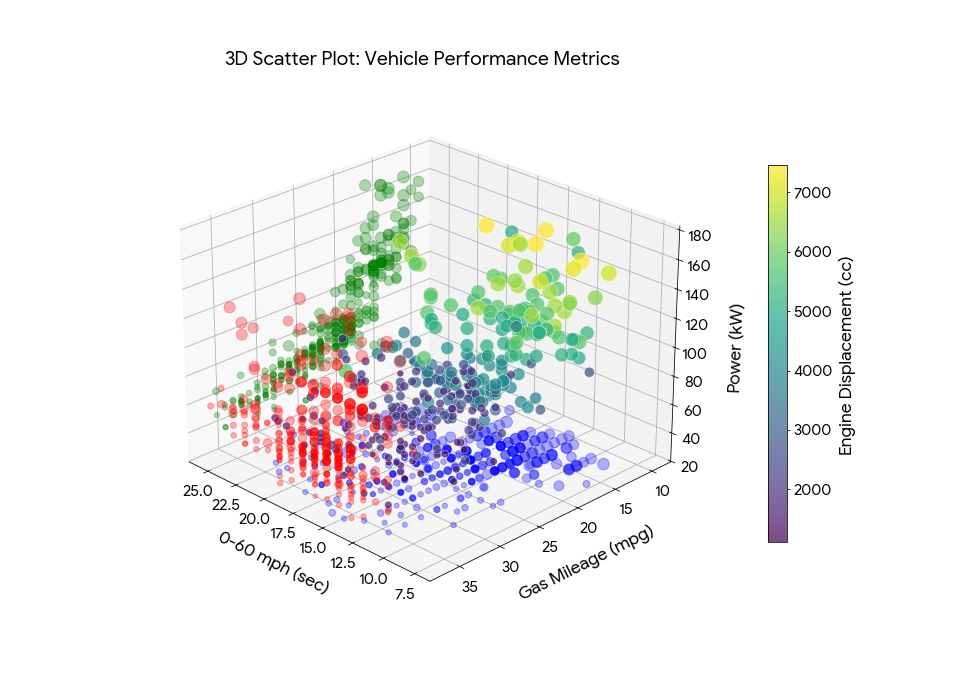

In [31]:
response = await run_benchmark(78)

#### Comparizon with the ground truth

**Ground Truth**: `example_78.jpg`

![Ground Truth](https://raw.githubusercontent.com/thunlp/MatPlotAgent/refs/heads/main/benchmark_data/ground_truth/example_78.png)

Based on the specific requirements of the original query and the standards of scientific accuracy, **`output_plot.png`** is the superior chart.

Here is a breakdown of why it better satisfies the criteria:

*1. Scientific Accuracy (The Deciding Factor)*

The most significant issue with `example_78.jpg` is on the **X-axis (0-60 mph)**. The scale includes **negative values** (down to approximately -3 seconds). Since a car cannot reach 60 mph in negative time, this makes the data representation physically impossible and scientifically inaccurate. `output_plot.png` correctly uses a realistic range starting above 7.5 seconds.

*2. Alignment of Projections*

A key requirement was the 2D projections on the XY, ZX, and YZ planes.

* **`output_plot.png`**: The projections (Blue, Red, and Green) perfectly mirror the density and position of the 3D cluster. You can clearly trace a high-power point (top of the Z-axis) to its corresponding red point on the ZX plane and green point on the YZ plane.
* **`example_78.jpg`**: The projections feel disconnected. For instance, the green projection on the left shows a very tight, linear grouping that does not appear to reflect the more dispersed nature of the 3D scatter points.

*3. Adherence to Styling Instructions*

Both charts follow the color and sizing rules well, but `output_plot.png` manages the "transparency to prevent overcrowding" instruction more effectively. The 3D points have a consistent alpha (transparency) that allows you to see through the cluster, whereas in `example_78.jpg`, some clusters become a solid mass where individual point sizes are harder to distinguish.

### Benchmark 84

# Original query: Write a python script to draw the phase diagram of water with the provided data, named "data.csv":
1. Prepare the Axes:
- Create a horizontal axis for temperature, marking one scale in Celsius (0°C to 100°C) and another in Kelvin (273.15 K to 647.396 K). These scales should be aligned so that each temperature in Celsius matches its corresponding value in Kelvin.
- Create a vertical axis for pressure, marking one scale in Pascals (from 611.657 Pa to 22.064 MPa, possibly using a logarithmic scale for better visualization) and another in bars and millibars. Align these scales so that, for example, 100 kPa corresponds with 1 bar.
- Set X1 to x1 - 273.15 to convert Kelvin to Celsius for the top X-axis. Set Y1 to y1/100000 to convert Pascals to bars for the right Y-axis. Adjust the right Y-axis to have a Log10 scale type.
2. Plot the Phase Boundaries:
- Utilize columns 1 and 2 from your data to plot the boundary line between the solid, liquid, and gas phases, curving from t

### root_agent
I have gathered the following information:
*   **Visualization Query**: "Write a python script to draw the phase diagram of water with the provided data, named "data.csv": 1. Prepare the Axes: - Create a horizontal axis for temperature, marking one scale in Celsius (0°C to 100°C) and another in Kelvin (273.15 K to 647.396 K). These scales should be aligned so that each temperature in Celsius matches its corresponding value in Kelvin. - Create a vertical axis for pressure, marking one scale in Pascals (from 611.657 Pa to 22.064 MPa, possibly using a logarithmic scale for better visualization) and another in bars and millibars. Align these scales so that, for example, 100 kPa corresponds with 1 bar. - Set X1 to x1 - 273.15 to convert Kelvin to Celsius for the top X-axis. Set Y1 to y1/100000 to convert Pascals to bars for the right Y-axis. Adjust the right Y-axis to have a Log10 scale type. 2. Plot the Phase Boundaries: - Utilize columns 1 and 2 from your data to plot the boundary line between the solid, liquid, and gas phases, curving from the triple point to the critical point. - Use columns 3 and 4 to plot the boundary between solid and liquid phases, which typically curves less dramatically than the solid-liquid-gas line. 3. Highlight Special Points: - Mark the triple point at 273.16 K and 611.657 Pa, where solid, liquid, and gas coexist. - Indicate the critical point at 647.396 K and 22.064 MPa, where the distinction between liquid and gas phases ends. 4. Insert Red Lines: - Draw a vertical red line at 0°C and 273.15 K to represent the freezing point at 1 atm, intersecting the solid-liquid boundary. - Add another vertical red line at 100°C and 373.15 K for the boiling point at 1 atm, intersecting the liquid-gas boundary. 5. Label and Color-Code: - Clearly label each axis with its respective units. - Color the different regions of the diagram to represent the solid (blue), liquid (green), and gas (yellow) phases. - Annotate the diagram with the special points and the red lines, including their corresponding temperature and pressure values. 6. Grid and Scale: - It may be helpful to include a grid to accurately read off pressures and temperatures at various points on the diagram. - Ensure that the scale is logarithmic for pressure if you are spanning wide ranges, as phase diagrams often do."
*   **Filenames**: `['data.csv']`

I will now proceed to create the chart.

### query_analyzer
{
  "interpreted_intent": "To generate a detailed phase diagram of water using Python, based on the provided data. The diagram must show the boundaries between solid, liquid, and gas phases, highlight critical and triple points, and include dual axes for temperature (Kelvin and Celsius) and pressure (Pascals and bars) with a logarithmic scale for pressure.",
  "visualization_type": "line plot",
  "plotting_key_points": [
    "Create a plot with a primary horizontal axis for Temperature in Kelvin and a primary vertical axis for Pressure in Pascals.",
    "The vertical (pressure) axis must use a logarithmic scale.",
    "Add a secondary horizontal axis at the top for Temperature in Celsius, aligned with the Kelvin scale (C = K - 273.15).",
    "Add a secondary vertical axis on the right for Pressure in bars, aligned with the Pascal scale (1 bar = 100,000 Pa).",
    "Plot the phase boundary using the first two columns ('Temperature(K)', 'Pressure(Liquid)') from 'data.csv'.",
    "Plot the second phase boundary using the third and fourth columns ('Temperature(K)', 'Pressure(Gas)') from 'data.csv'.",
    "Mark the Triple Point at (273.16 K, 611.657 Pa) with a scatter point and annotation.",
    "Mark the Critical Point at (647.396 K, 22.064 MPa) with a scatter point and annotation.",
    "Draw a vertical red line at T = 273.15 K (0°C) to represent the freezing point at 1 atm (101325 Pa).",
    "Draw a second vertical red line at T = 373.15 K (100°C) to represent the boiling point at 1 atm (101325 Pa).",
    "Fill the area representing the 'Solid' phase with blue color.",
    "Fill the area representing the 'Liquid' phase with green color.",
    "Fill the area representing the 'Gas' phase with yellow color.",
    "Label all axes clearly with their respective units (Temperature (°C), Temperature (K), Pressure (Pa), Pressure (bar)).",
    "Set a title for the plot, for example, 'Phase Diagram of Water'.",
    "Add a grid to the plot for better readability."
  ],
  "implementation_plan": [
    {
      "step": 1,
      "action": "Load and Prepare Data",
      "details": "Read 'data.csv' into a pandas DataFrame. Due to the column naming, it's best to read the first two columns as the solid-liquid boundary data and the next two as the liquid-gas boundary data. Handle any NaN values and sort each dataset by temperature to ensure correct line plotting.",
      "functions": [
        "pd.read_csv",
        "df.dropna",
        "df.sort_values"
      ]
    },
    {
      "step": 2,
      "action": "Initialize Figure and Axes",
      "details": "Create a Matplotlib figure and a primary axes object. Set the y-axis to a logarithmic scale. Create a secondary x-axis (for Celsius) and a secondary y-axis (for bars) using `twiny()` and `twinx()` respectively.",
      "functions": [
        "plt.figure",
        "fig.add_subplot",
        "ax.set_yscale",
        "ax.twiny",
        "ax.twinx"
      ]
    },
    {
      "step": 3,
      "action": "Plot Phase Boundaries and Special Points",
      "details": "Plot the two sorted datasets as lines on the primary axes. Plot the Triple Point and Critical Point as distinct markers.",
      "functions": [
        "ax.plot",
        "ax.scatter"
      ]
    },
    {
      "step": 4,
      "action": "Add Reference Lines and Annotations",
      "details": "Draw two vertical lines for the freezing and boiling points at 1 atm using `axvline`. Annotate the special points and reference lines with their values.",
      "functions": [
        "ax.axvline",
        "ax.annotate"
      ]
    },
    {
      "step": 5,
      "action": "Fill Phase Regions",
      "details": "Use `ax.fill_between` to color the regions for solid, liquid, and gas phases. The boundaries for filling will be defined by the plotted lines and the plot limits.",
      "functions": [
        "ax.fill_between"
      ]
    },
    {
      "step": 6,
      "action": "Finalize and Style the Plot",
      "details": "Set all axis labels, the main title, and configure the ticks for the secondary axes to align with the primary axes. Add a grid, adjust the layout to prevent overlap, and save the figure.",
      "functions": [
        "ax.set_xlabel",
        "ax.set_ylabel",
        "ax.set_title",
        "ax.grid",
        "plt.tight_layout",
        "plt.savefig"
      ]
    }
  ],
  "global_todo_list": [
    {
      "id": "todo_1",
      "task": "Analyze 'data.csv', noting the four-column structure represents two separate line plots. Plan for data cleaning (NaNs) and sorting by temperature for each line.",
      "agent": "data_process_planner"
    },
    {
      "id": "todo_2",
      "task": "Map the data columns to visual elements: two line plots for phase boundaries, scatter points for critical/triple points, and define the coordinates for the filled phase regions (solid, liquid, gas).",
      "agent": "viz_mapping_agent"
    },
    {
      "id": "todo_3",
      "task": "Define the visual design: color palette (blue for solid, green for liquid, yellow for gas, red for reference lines), font sizes for titles/labels, and layout strategy for the dual-axis system.",
      "agent": "design_explorer"
    },
    {
      "id": "todo_4",
      "task": "Generate the complete Python script using Matplotlib to implement all specified plot elements, including dual axes, logarithmic scale, filled regions, annotations, and styling.",
      "agent": "code_generator"
    },
    {
      "id": "todo_5",
      "task": "Verify that the final visualization correctly implements all requirements: dual axes are aligned, pressure scale is logarithmic, all points and lines are present and labeled, and phase regions are correctly colored.",
      "agent": "visual_evaluator"
    }
  ],
  "success_criteria": [
    "The chart must display two distinct phase boundary lines based on the provided data.",
    "The chart must have four axes: Temperature in Kelvin (bottom), Temperature in Celsius (top), Pressure in Pascals (left), and Pressure in bars (right).",
    "The pressure axes (left and right) must be on a logarithmic scale.",
    "The Triple Point and Critical Point must be clearly marked and annotated on the diagram.",
    "Two vertical red lines indicating the freezing and boiling points at 1 atm must be present and annotated.",
    "The solid, liquid, and gas phase regions must be filled with blue, green, and yellow colors, respectively.",
    "All axes and the chart itself must have clear, descriptive labels and a title."
  ]
}

#### Data summary of data.csv:
--- Detailed Metadata Profile for data.csv ---
Total Rows: 9, Total Columns: 4

Column Schema and Quality:
|                  | Data Type   |   Missing Values |   Unique Values |
|:-----------------|:------------|-----------------:|----------------:|
| Temperature(K)   | float64     |                0 |               9 |
| Pressure(Liquid) | float64     |                0 |               9 |
| Temperature(K).1 | float64     |                3 |               6 |
| Pressure(Gas)    | float64     |                3 |               6 |


Numerical Summary Statistics:
|       |   Temperature(K) |   Pressure(Liquid) |   Temperature(K).1 |    Pressure(Gas) |
|:------|-----------------:|-------------------:|-------------------:|-----------------:|
| count |             9    |        9           |               6    |      6           |
| mean  |           317.89 |        1.61317e+09 |             367.28 |      3.86101e+06 |
| std   |           127.3  |        3.

### data_process_planner
{
  "processing_steps": [
    "Load the 'data.csv' file into a pandas DataFrame.",
    "Separate the DataFrame into two distinct datasets for the phase boundaries. The first boundary will use 'Temperature(K)' and 'Pressure(Liquid)'. The second will use the columns 'Temperature(K).1' and 'Pressure(Gas)'.",
    "For the second dataset (liquid-gas boundary), remove the rows containing missing values (NaNs) to ensure data integrity.",
    "Sort both datasets independently based on their temperature columns in ascending order. This is crucial for drawing the continuous lines of the phase diagram correctly."
  ],
  "insights": {
    "key_columns": [
      "Temperature(K)",
      "Pressure(Liquid)",
      "Temperature(K).1",
      "Pressure(Gas)"
    ],
    "aggregations_needed": [],
    "quality_issues": [
      "The columns 'Temperature(K).1' and 'Pressure(Gas)' have 3 missing values that must be removed before plotting."
    ]
  },
  "visualization_hint": "A line plot is the ideal chart type for this data, as it is perfectly suited for representing the continuous phase boundaries described by the temperature and pressure points."
}

...

### code_generator
{
  "code_architecture": {
    "main_functions": [
      "load_data",
      "plot_phase_diagram"
    ],
    "helper_functions": [
      "k2c",
      "c2k",
      "pa2bar",
      "bar2pa"
    ],
    "class_structure": null,
    "modular_design": "Script-based with functional decomposition for clarity."
  },
  "matplotlib_approach": {
    "plotting_method": "plt.subplots",
    "style_management": "manual",
    "color_implementation": "manual_colors",
    "layout_strategy": "tight_layout"
  },
  "data_handling": {
    "data_preparation": [
      "Load CSV",
      "Split into Melting and Vaporization datasets",
      "Drop NaNs",
      "Sort by Temperature/Pressure"
    ],
    "data_validation": [
      "Check for missing values"
    ],
    "error_handling": [
      "Basic file loading error handling"
    ],
    "performance_considerations": [
      "Vectorized pandas operations"
    ]
  },
  "code_structure": {
    "imports": [
      "pandas",
      "matplotlib.pyplot",
      "numpy"
    ],
    "configuration": "Figure size, font sizes, axis limits",
    "main_plotting": "Plotting lines, filling regions, adding scatter points",
    "customization": "Annotations, grid, dual axes setup",
    "output_handling": "Save to PNG"
  },
  "quality_requirements": {
    "code_style": "PEP8",
    "documentation_level": "standard",
    "error_handling_level": "basic",
    "performance_priority": "balanced"
  },
  "generated_code": "import pandas as pd\nimport matplotlib.pyplot as plt\nimport numpy as np\n\n# Load data\ndf = pd.read_csv('data.csv')\n\n# Prepare datasets\n# Solid-Liquid Boundary (Melting Curve)\ndf_sl = df[['Temperature(K)', 'Pressure(Liquid)']].dropna().sort_values('Pressure(Liquid)')\n# Liquid-Gas / Solid-Gas Boundary (Sublimation + Vaporization)\ndf_lg = df[['Temperature(K).1', 'Pressure(Gas)']].dropna().sort_values('Temperature(K).1')\n\n# Setup Figure\nfig, ax1 = plt.subplots(figsize=(12, 10))\n\n# Plot Lines\nax1.plot(df_sl['Temperature(K)'], df_sl['Pressure(Liquid)'], color='#1f77b4', linewidth=3, label='Melting Curve')\nax1.plot(df_lg['Temperature(K).1'], df_lg['Pressure(Gas)'], color='#ff7f0e', linewidth=3, label='Vaporization/Sublimation Curve')\n\n# Log Scale\nax1.set_yscale('log')\n\n# Set Limits\nx_min, x_max = 200, 700\ny_min, y_max = 1, 1e11 \n\nax1.set_xlim(x_min, x_max)\nax1.set_ylim(y_min, y_max)\n\n# Fill Regions\n# 1. Gas (Yellow): Below the Sublimation/Vaporization curve\n# We extend the last point to x_max to fill the bottom right corner if we consider it gas\n# But strictly, it stops at critical point. Let's just fill under the curve.\nax1.fill_between(df_lg['Temperature(K).1'], df_lg['Pressure(Gas)'], y2=y_min, color='yellow', alpha=0.2)\n\n# 2. Liquid (Green): Above Vaporization curve (T > TP)\ndf_vap = df_lg[df_lg['Temperature(K).1'] >= 273.16]\nax1.fill_between(df_vap['Temperature(K).1'], df_vap['Pressure(Gas)'], y2=y_max, color='green', alpha=0.2)\n\n# 3. Solid (Blue):\n# Part A: Above Sublimation curve (T < TP)\ndf_sub = df_lg[df_lg['Temperature(K).1'] <= 273.16]\nax1.fill_between(df_sub['Temperature(K).1'], df_sub['Pressure(Gas)'], y2=y_max, color='blue', alpha=0.2)\n\n# Part B: Left of Melting Curve\nax1.fill_betweenx(df_sl['Pressure(Liquid)'], df_sl['Temperature(K)'], x2=x_min, color='blue', alpha=0.2)\n\n# Special Points\ntriple_point = (273.16, 611.657)\ncritical_point = (647.396, 22.064e6)\n\nax1.scatter(*triple_point, color='black', s=100, zorder=10, edgecolors='white')\nax1.annotate('Triple Point\\n(273.16 K, 611.7 Pa)', xy=triple_point, xytext=(290, 200),\n             arrowprops=dict(facecolor='black', arrowstyle='->'), fontsize=14, fontweight='bold')\n\nax1.scatter(*critical_point, color='red', s=100, zorder=10, edgecolors='white')\nax1.annotate('Critical Point\\n(647.4 K, 22.1 MPa)', xy=critical_point, xytext=(500, 5e7),\n             arrowprops=dict(facecolor='red', arrowstyle='->'), fontsize=14, fontweight='bold')\n\n# Reference Lines\n# Freezing at 1 atm (101325 Pa) -> 273.15 K\nax1.axvline(x=273.15, color='red', linestyle='--', alpha=0.7, linewidth=1.5)\nax1.annotate('Freezing Point (1 atm)', xy=(273.15, 1e5), xytext=(210, 2e6),\n             arrowprops=dict(facecolor='red', arrowstyle='->'), fontsize=12, color='red', rotation=90)\n\n# Boiling at 1 atm -> 373.15 K\nax1.axvline(x=373.15, color='red', linestyle='--', alpha=0.7, linewidth=1.5)\nax1.annotate('Boiling Point (1 atm)', xy=(373.15, 1e5), xytext=(385, 2e3),\n             arrowprops=dict(facecolor='red', arrowstyle='->'), fontsize=12, color='red', rotation=90)\n\n# Labels and Titles\nax1.set_xlabel('Temperature (K)', fontsize=18)\nax1.set_ylabel('Pressure (Pa)', fontsize=18)\nax1.set_title('Phase Diagram of Water', fontsize=22, pad=20)\nax1.grid(True, which=\"major\", ls=\"-\", alpha=0.4)\nax1.grid(True, which=\"minor\", ls=\":\", alpha=0.2)\nax1.tick_params(axis='both', which='major', labelsize=16)\n\n# Secondary Axes\ndef k2c(x): return x - 273.15\ndef c2k(x): return x + 273.15\nsecax_x = ax1.secondary_xaxis('top', functions=(k2c, c2k))\nsecax_x.set_xlabel('Temperature (°C)', fontsize=18)\nsecax_x.tick_params(axis='x', labelsize=16)\n\ndef pa2bar(y): return y / 1e5\ndef bar2pa(y): return y * 1e5\nsecax_y = ax1.secondary_yaxis('right', functions=(pa2bar, bar2pa))\nsecax_y.set_ylabel('Pressure (bar)', fontsize=18)\nsecax_y.tick_params(axis='y', labelsize=16)\n\nplt.tight_layout()\nplt.savefig('output_plot.png', dpi=70)\n"
} 

### visual_evaluator
{
  "semantic_accuracy": {
    "data_query_match": "excellent",
    "mathematical_correctness": "good",
    "visual_element_compliance": "excellent",
    "layout_structure_match": "excellent",
    "specification_adherence_score": 0.95
  },
  "quality_assessment": {
    "overall_quality": "excellent",
    "readability": "excellent",
    "visual_appeal": "high",
    "professional_appearance": "yes"
  },
  "requirement_analysis": {
    "key_points_covered": [
      "Dual axes for Temperature (K and °C) correctly aligned",
      "Dual axes for Pressure (Pa and bar) correctly aligned",
      "Logarithmic scale for Pressure axis",
      "Phase boundaries plotted from data",
      "Triple Point and Critical Point marked and annotated",
      "Freezing and Boiling point reference lines included",
      "Phase regions (Solid, Liquid, Gas) filled with requested colors",
      "Grid and labels present"
    ],
    "key_points_missing": [],
    "critical_errors": [],
    "requirement_match_percentage": 1.0
  },
  "accessibility_check": {
    "color_contrast_adequate": true,
    "colorblind_friendly": true,
    "text_size_adequate": true,
    "wcag_compliance_level": "AA"
  },
  "final_recommendation": {
    "decision": "approve",
    "confidence_level": 1.0,
    "primary_issues": [
      "Minor aesthetic issue: The 'Solid' phase fill is composed of two overlapping semi-transparent regions, creating a visibly darker rectangular intersection.",
      "Minor semantic detail: Due to the negative slope of the water melting curve, a small wedge of the Liquid phase (where T < 273.16 K at high pressure) is technically not covered by the green fill, which starts strictly at T >= 273.16 K."
    ],
    "improvement_priority": "low"
  }
} 

#### The evaluation result: approve, iterations=1.
#### Exiting the loop with approval.


### transfer_agent
#### Pipeline execution result:
* Available Data Files: ['data.csv']

* Result from the `query_analyser`:
{'interpreted_intent': 'To generate a detailed phase diagram of water using Python, based on the provided data. The diagram must show the boundaries between solid, liquid, and gas phases, highlight critical and triple points, and include dual axes for temperature (Kelvin and Celsius) and pressure (Pascals and bars) with a logarithmic scale for pressure.', 'visualization_type': 'line plot', 'plotting_key_points': ['Create a plot with a primary horizontal axis for Temperature in Kelvin and a primary vertical axis for Pressure in Pascals.', 'The vertical (pressure) axis must use a logarithmic scale.', 'Add a secondary horizontal axis at the top for Temperature in Celsius, aligned with the Kelvin scale (C = K - 273.15).', 'Add a secondary vertical axis on the right for Pressure in bars, aligned with the Pascal scale (1 bar = 100,000 Pa).', "Plot the phase boundary using the first two columns ('Temperature(K)', 'Pressure(Liquid)') from 'data.csv'.", "Plot the second phase boundary using the third and fourth columns ('Temperature(K)', 'Pressure(Gas)') from 'data.csv'.", 'Mark the Triple Point at (273.16 K, 611.657 Pa) with a scatter point and annotation.', 'Mark the Critical Point at (647.396 K, 22.064 MPa) with a scatter point and annotation.', 'Draw a vertical red line at T = 273.15 K (0°C) to represent the freezing point at 1 atm (101325 Pa).', 'Draw a second vertical red line at T = 373.15 K (100°C) to represent the boiling point at 1 atm (101325 Pa).', "Fill the area representing the 'Solid' phase with blue color.", "Fill the area representing the 'Liquid' phase with green color.", "Fill the area representing the 'Gas' phase with yellow color.", 'Label all axes clearly with their respective units (Temperature (°C), Temperature (K), Pressure (Pa), Pressure (bar)).', "Set a title for the plot, for example, 'Phase Diagram of Water'.", 'Add a grid to the plot for better readability.'], 'implementation_plan': [{'step': 1, 'action': 'Load and Prepare Data', 'details': "Read 'data.csv' into a pandas DataFrame. Due to the column naming, it's best to read the first two columns as the solid-liquid boundary data and the next two as the liquid-gas boundary data. Handle any NaN values and sort each dataset by temperature to ensure correct line plotting.", 'functions': ['pd.read_csv', 'df.dropna', 'df.sort_values']}, {'step': 2, 'action': 'Initialize Figure and Axes', 'details': 'Create a Matplotlib figure and a primary axes object. Set the y-axis to a logarithmic scale. Create a secondary x-axis (for Celsius) and a secondary y-axis (for bars) using `twiny()` and `twinx()` respectively.', 'functions': ['plt.figure', 'fig.add_subplot', 'ax.set_yscale', 'ax.twiny', 'ax.twinx']}, {'step': 3, 'action': 'Plot Phase Boundaries and Special Points', 'details': 'Plot the two sorted datasets as lines on the primary axes. Plot the Triple Point and Critical Point as distinct markers.', 'functions': ['ax.plot', 'ax.scatter']}, {'step': 4, 'action': 'Add Reference Lines and Annotations', 'details': 'Draw two vertical lines for the freezing and boiling points at 1 atm using `axvline`. Annotate the special points and reference lines with their values.', 'functions': ['ax.axvline', 'ax.annotate']}, {'step': 5, 'action': 'Fill Phase Regions', 'details': 'Use `ax.fill_between` to color the regions for solid, liquid, and gas phases. The boundaries for filling will be defined by the plotted lines and the plot limits.', 'functions': ['ax.fill_between']}, {'step': 6, 'action': 'Finalize and Style the Plot', 'details': 'Set all axis labels, the main title, and configure the ticks for the secondary axes to align with the primary axes. Add a grid, adjust the layout to prevent overlap, and save the figure.', 'functions': ['ax.set_xlabel', 'ax.set_ylabel', 'ax.set_title', 'ax.grid', 'plt.tight_layout', 'plt.savefig']}], 'global_todo_list': [{'id': 'todo_1', 'task': "Analyze 'data.csv', noting the four-column structure represents two separate line plots. Plan for data cleaning (NaNs) and sorting by temperature for each line.", 'agent': 'data_process_planner'}, {'id': 'todo_2', 'task': 'Map the data columns to visual elements: two line plots for phase boundaries, scatter points for critical/triple points, and define the coordinates for the filled phase regions (solid, liquid, gas).', 'agent': 'viz_mapping_agent'}, {'id': 'todo_3', 'task': 'Define the visual design: color palette (blue for solid, green for liquid, yellow for gas, red for reference lines), font sizes for titles/labels, and layout strategy for the dual-axis system.', 'agent': 'design_explorer'}, {'id': 'todo_4', 'task': 'Generate the complete Python script using Matplotlib to implement all specified plot elements, including dual axes, logarithmic scale, filled regions, annotations, and styling.', 'agent': 'code_generator'}, {'id': 'todo_5', 'task': 'Verify that the final visualization correctly implements all requirements: dual axes are aligned, pressure scale is logarithmic, all points and lines are present and labeled, and phase regions are correctly colored.', 'agent': 'visual_evaluator'}], 'success_criteria': ['The chart must display two distinct phase boundary lines based on the provided data.', 'The chart must have four axes: Temperature in Kelvin (bottom), Temperature in Celsius (top), Pressure in Pascals (left), and Pressure in bars (right).', 'The pressure axes (left and right) must be on a logarithmic scale.', 'The Triple Point and Critical Point must be clearly marked and annotated on the diagram.', 'Two vertical red lines indicating the freezing and boiling points at 1 atm must be present and annotated.', 'The solid, liquid, and gas phase regions must be filled with blue, green, and yellow colors, respectively.', 'All axes and the chart itself must have clear, descriptive labels and a title.']}
* Result from the `data_process_planner`:
{'processing_steps': ["Load the 'data.csv' file into a pandas DataFrame.", "Separate the DataFrame into two distinct datasets for the phase boundaries. The first boundary will use 'Temperature(K)' and 'Pressure(Liquid)'. The second will use the columns 'Temperature(K).1' and 'Pressure(Gas)'.", 'For the second dataset (liquid-gas boundary), remove the rows containing missing values (NaNs) to ensure data integrity.', 'Sort both datasets independently based on their temperature columns in ascending order. This is crucial for drawing the continuous lines of the phase diagram correctly.'], 'insights': {'key_columns': ['Temperature(K)', 'Pressure(Liquid)', 'Temperature(K).1', 'Pressure(Gas)'], 'aggregations_needed': [], 'quality_issues': ["The columns 'Temperature(K).1' and 'Pressure(Gas)' have 3 missing values that must be removed before plotting."]}, 'visualization_hint': 'A line plot is the ideal chart type for this data, as it is perfectly suited for representing the continuous phase boundaries described by the temperature and pressure points.'}
* Result from the `viz_mapping_agent`:
{'chart_type': 'line', 'data_mappings': {'x_axis': 'Temperature(K)', 'y_axis': 'Pressure(Liquid)'}, 'aggregations': [], 'filters': [{'column': 'Temperature(K).1', 'condition': 'notnull'}, {'column': 'Pressure(Gas)', 'condition': 'notnull'}], 'styling_hints': {'title': 'Phase Diagram of Water', 'xlabel': 'Temperature (K)', 'ylabel': 'Pressure (Pa)', 'color_palette': 'custom (Blue for Solid, Green for Liquid, Yellow for Gas)'}, 'transformations': ["df_sl = df[['Temperature(K)', 'Pressure(Liquid)']].sort_values('Temperature(K)')", "df_lg = df[['Temperature(K).1', 'Pressure(Gas)']].dropna().sort_values('Temperature(K).1')", 'Plot df_sl as the Solid-Liquid boundary', 'Plot df_lg as the Liquid-Gas/Solid-Gas boundary'], 'goal': 'Visualize the phase diagram of water with dual axes (K/°C, Pa/bar), logarithmic pressure scale, and colored phase regions.', 'rationale': 'The data contains two distinct curves representing phase boundaries. A line plot with a logarithmic Y-axis is standard for phase diagrams to span the wide range of pressures. Dual axes are required by the user to show multiple units.', 'confidence': 1.0}
* Result from the `design_explorer`:
{'design_objectives': ['Create a scientifically accurate phase diagram of water with precise dual-axis alignment', 'Clearly differentiate Solid, Liquid, and Gas phases using semantic color coding', 'Ensure high readability of logarithmic pressure scales and linear temperature scales', 'Highlight critical thermodynamic points (Triple Point, Critical Point) and standard reference values (Freezing/Boiling points)'], 'target_audience': {'primary_audience': 'Students, Researchers, and Engineers in Thermodynamics or Physical Chemistry', 'expertise_level': 'intermediate', 'context_of_use': 'reporting', 'accessibility_requirements': ['Ensure sufficient contrast between text labels and colored phase regions', 'Use distinct markers in addition to color for special points']}, 'visual_hierarchy': {'primary_elements': ['Phase boundary lines', 'Triple Point and Critical Point markers', 'Phase region fills (Solid, Liquid, Gas)'], 'secondary_elements': ['Reference lines (Freezing/Boiling points)', 'Axis labels and titles', 'Grid lines'], 'emphasis_strategy': 'Use saturated colors for points/lines and lighter, semi-transparent shades for regional fills to maintain grid visibility'}, 'color_strategy': {'primary_colors': ['#1f77b4', '#2ca02c', '#ff7f0e', '#d62728'], 'color_meaning': 'Blue for Solid phase, Green for Liquid phase, Yellow/Orange for Gas phase, Red for reference lines', 'accessibility_compliance': 'AA', 'cultural_considerations': 'Standard scientific color conventions for water phases (Ice=Blue, Water=Green/Blue, Steam=White/Grey/Yellow)'}, 'layout_principles': {'composition_approach': 'grid', 'spacing_strategy': 'moderate', 'alignment_system': 'center', 'proportion_ratios': 'custom'}, 'typography_requirements': {'font_hierarchy': 'Title (20pt) > Axis Labels (18pt) > Ticks/Legend (16pt) > Annotations (14pt)', 'readability_priority': 'high', 'brand_alignment': 'academic'}, 'interaction_design': {'interaction_level': 'static', 'user_controls': [], 'feedback_mechanisms': 'None'}, 'technical_constraints': {'output_format': 'static', 'size_limitations': 'screen', 'performance_requirements': 'moderate'}, 'innovation_opportunities': ['Use of dual axes (Twiny/Twinx) to simultaneously display SI and non-SI units without clutter', 'Semi-transparent filling (alpha blending) to show grid lines through phase regions'], 'design_confidence': 1.0}
* Result from the `code_generator`:
{'code_architecture': {'main_functions': ['load_data', 'plot_phase_diagram'], 'helper_functions': ['k2c', 'c2k', 'pa2bar', 'bar2pa'], 'modular_design': 'Script-based with functional decomposition for clarity.'}, 'matplotlib_approach': {'plotting_method': 'plt.subplots', 'style_management': 'manual', 'color_implementation': 'manual_colors', 'layout_strategy': 'tight_layout'}, 'data_handling': {'data_preparation': ['Load CSV', 'Split into Melting and Vaporization datasets', 'Drop NaNs', 'Sort by Temperature/Pressure'], 'data_validation': ['Check for missing values'], 'error_handling': ['Basic file loading error handling'], 'performance_considerations': ['Vectorized pandas operations']}, 'code_structure': {'imports': ['pandas', 'matplotlib.pyplot', 'numpy'], 'configuration': 'Figure size, font sizes, axis limits', 'main_plotting': 'Plotting lines, filling regions, adding scatter points', 'customization': 'Annotations, grid, dual axes setup', 'output_handling': 'Save to PNG'}, 'quality_requirements': {'code_style': 'PEP8', 'documentation_level': 'standard', 'error_handling_level': 'basic', 'performance_priority': 'balanced'}, 'generated_code': 'import pandas as pd\nimport matplotlib.pyplot as plt\nimport numpy as np\n\n# Load data\ndf = pd.read_csv(\'data.csv\')\n\n# Prepare datasets\n# Solid-Liquid Boundary (Melting Curve)\ndf_sl = df[[\'Temperature(K)\', \'Pressure(Liquid)\']].dropna().sort_values(\'Pressure(Liquid)\')\n# Liquid-Gas / Solid-Gas Boundary (Sublimation + Vaporization)\ndf_lg = df[[\'Temperature(K).1\', \'Pressure(Gas)\']].dropna().sort_values(\'Temperature(K).1\')\n\n# Setup Figure\nfig, ax1 = plt.subplots(figsize=(12, 10))\n\n# Plot Lines\nax1.plot(df_sl[\'Temperature(K)\'], df_sl[\'Pressure(Liquid)\'], color=\'#1f77b4\', linewidth=3, label=\'Melting Curve\')\nax1.plot(df_lg[\'Temperature(K).1\'], df_lg[\'Pressure(Gas)\'], color=\'#ff7f0e\', linewidth=3, label=\'Vaporization/Sublimation Curve\')\n\n# Log Scale\nax1.set_yscale(\'log\')\n\n# Set Limits\nx_min, x_max = 200, 700\ny_min, y_max = 1, 1e11 \n\nax1.set_xlim(x_min, x_max)\nax1.set_ylim(y_min, y_max)\n\n# Fill Regions\n# 1. Gas (Yellow): Below the Sublimation/Vaporization curve\n# We extend the last point to x_max to fill the bottom right corner if we consider it gas\n# But strictly, it stops at critical point. Let\'s just fill under the curve.\nax1.fill_between(df_lg[\'Temperature(K).1\'], df_lg[\'Pressure(Gas)\'], y2=y_min, color=\'yellow\', alpha=0.2)\n\n# 2. Liquid (Green): Above Vaporization curve (T > TP)\ndf_vap = df_lg[df_lg[\'Temperature(K).1\'] >= 273.16]\nax1.fill_between(df_vap[\'Temperature(K).1\'], df_vap[\'Pressure(Gas)\'], y2=y_max, color=\'green\', alpha=0.2)\n\n# 3. Solid (Blue):\n# Part A: Above Sublimation curve (T < TP)\ndf_sub = df_lg[df_lg[\'Temperature(K).1\'] <= 273.16]\nax1.fill_between(df_sub[\'Temperature(K).1\'], df_sub[\'Pressure(Gas)\'], y2=y_max, color=\'blue\', alpha=0.2)\n\n# Part B: Left of Melting Curve\nax1.fill_betweenx(df_sl[\'Pressure(Liquid)\'], df_sl[\'Temperature(K)\'], x2=x_min, color=\'blue\', alpha=0.2)\n\n# Special Points\ntriple_point = (273.16, 611.657)\ncritical_point = (647.396, 22.064e6)\n\nax1.scatter(*triple_point, color=\'black\', s=100, zorder=10, edgecolors=\'white\')\nax1.annotate(\'Triple Point\\n(273.16 K, 611.7 Pa)\', xy=triple_point, xytext=(290, 200),\n             arrowprops=dict(facecolor=\'black\', arrowstyle=\'->\'), fontsize=14, fontweight=\'bold\')\n\nax1.scatter(*critical_point, color=\'red\', s=100, zorder=10, edgecolors=\'white\')\nax1.annotate(\'Critical Point\\n(647.4 K, 22.1 MPa)\', xy=critical_point, xytext=(500, 5e7),\n             arrowprops=dict(facecolor=\'red\', arrowstyle=\'->\'), fontsize=14, fontweight=\'bold\')\n\n# Reference Lines\n# Freezing at 1 atm (101325 Pa) -> 273.15 K\nax1.axvline(x=273.15, color=\'red\', linestyle=\'--\', alpha=0.7, linewidth=1.5)\nax1.annotate(\'Freezing Point (1 atm)\', xy=(273.15, 1e5), xytext=(210, 2e6),\n             arrowprops=dict(facecolor=\'red\', arrowstyle=\'->\'), fontsize=12, color=\'red\', rotation=90)\n\n# Boiling at 1 atm -> 373.15 K\nax1.axvline(x=373.15, color=\'red\', linestyle=\'--\', alpha=0.7, linewidth=1.5)\nax1.annotate(\'Boiling Point (1 atm)\', xy=(373.15, 1e5), xytext=(385, 2e3),\n             arrowprops=dict(facecolor=\'red\', arrowstyle=\'->\'), fontsize=12, color=\'red\', rotation=90)\n\n# Labels and Titles\nax1.set_xlabel(\'Temperature (K)\', fontsize=18)\nax1.set_ylabel(\'Pressure (Pa)\', fontsize=18)\nax1.set_title(\'Phase Diagram of Water\', fontsize=22, pad=20)\nax1.grid(True, which="major", ls="-", alpha=0.4)\nax1.grid(True, which="minor", ls=":", alpha=0.2)\nax1.tick_params(axis=\'both\', which=\'major\', labelsize=16)\n\n# Secondary Axes\ndef k2c(x): return x - 273.15\ndef c2k(x): return x + 273.15\nsecax_x = ax1.secondary_xaxis(\'top\', functions=(k2c, c2k))\nsecax_x.set_xlabel(\'Temperature (°C)\', fontsize=18)\nsecax_x.tick_params(axis=\'x\', labelsize=16)\n\ndef pa2bar(y): return y / 1e5\ndef bar2pa(y): return y * 1e5\nsecax_y = ax1.secondary_yaxis(\'right\', functions=(pa2bar, bar2pa))\nsecax_y.set_ylabel(\'Pressure (bar)\', fontsize=18)\nsecax_y.tick_params(axis=\'y\', labelsize=16)\n\nplt.tight_layout()\nplt.savefig(\'output_plot.png\', dpi=70)\n'}
* Result from the `visual_evaluator`:
{'semantic_accuracy': {'data_query_match': 'excellent', 'mathematical_correctness': 'good', 'visual_element_compliance': 'excellent', 'layout_structure_match': 'excellent', 'specification_adherence_score': 0.95}, 'quality_assessment': {'overall_quality': 'excellent', 'readability': 'excellent', 'visual_appeal': 'high', 'professional_appearance': 'yes'}, 'requirement_analysis': {'key_points_covered': ['Dual axes for Temperature (K and °C) correctly aligned', 'Dual axes for Pressure (Pa and bar) correctly aligned', 'Logarithmic scale for Pressure axis', 'Phase boundaries plotted from data', 'Triple Point and Critical Point marked and annotated', 'Freezing and Boiling point reference lines included', 'Phase regions (Solid, Liquid, Gas) filled with requested colors', 'Grid and labels present'], 'key_points_missing': [], 'critical_errors': [], 'requirement_match_percentage': 1.0}, 'accessibility_check': {'color_contrast_adequate': True, 'colorblind_friendly': True, 'text_size_adequate': True, 'wcag_compliance_level': 'AA'}, 'final_recommendation': {'decision': 'approve', 'confidence_level': 1.0, 'primary_issues': ["Minor aesthetic issue: The 'Solid' phase fill is composed of two overlapping semi-transparent regions, creating a visibly darker rectangular intersection.", 'Minor semantic detail: Due to the negative slope of the water melting curve, a small wedge of the Liquid phase (where T < 273.16 K at high pressure) is technically not covered by the green fill, which starts strictly at T >= 273.16 K.'], 'improvement_priority': 'low'}}


### root_agent
The phase diagram of water has been successfully generated, including dual axes for temperature and pressure, logarithmic scaling for pressure, marked triple and critical points, and colored phase regions. The plot meets all specified requirements.

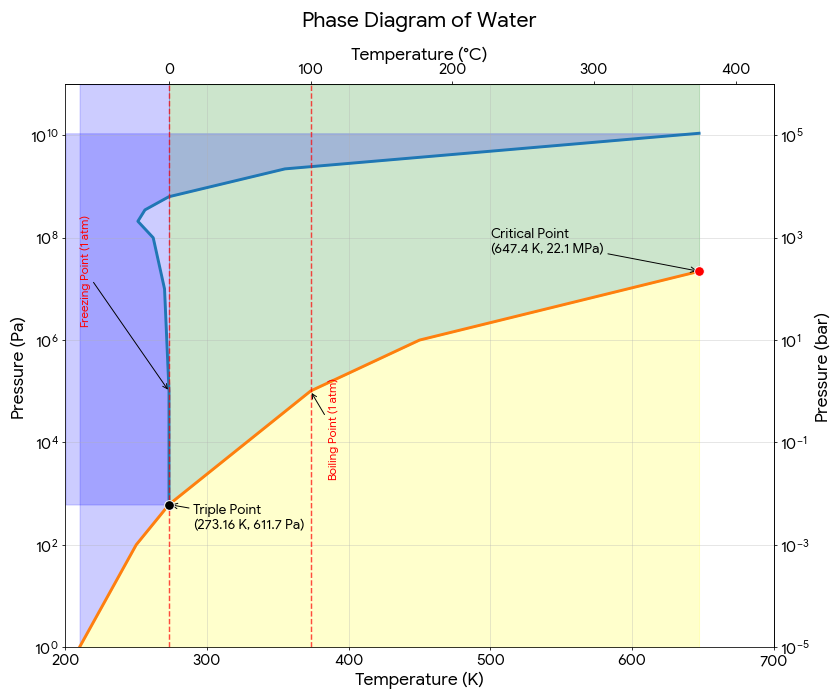

In [32]:
response = await run_benchmark(84)

#### Comparizon with the ground truth.

**Ground Truth**: `example_84.png`

![Ground Truth](https://raw.githubusercontent.com/thunlp/MatPlotAgent/refs/heads/main/benchmark_data/ground_truth/example_84.png)

Based on the original query and principles of scientific accuracy, **example_84.png** is the superior chart.

Here's a breakdown of why:

* **Scientific Accuracy (The Solid-Liquid Boundary):** Water has a highly unusual phase diagram where the solid-liquid boundary line has a *negative slope* (it curves to the left). This illustrates that water expands when it freezes, meaning you can melt ice by applying pressure. **example_84.png** accurately depicts this negative slope. **output_plot.png**, however, shows a jagged, scientifically inaccurate line for this boundary that abruptly jags to the right.
* **Axis Alignment and Formatting:** **example_84.png** does a much better job of clearly aligning the secondary axes. The 100 kPa mark on the left Y-axis perfectly aligns with the 1 bar mark on the right Y-axis. Furthermore, the Celsius and Kelvin scales are perfectly synced.
* **Clarity of Special Points:** **example_84.png** clearly marks the 1 atm pressure line horizontally, creating precise, readable intersections for the normal freezing and boiling points exactly where the vertical red lines drop down.

**output_plot.png** suffers from distorted boundary lines and less polished axis formatting, making it significantly less scientifically accurate and harder to read.

### Benchmark 95

# Original query: I want a polar coordinate diagram to visualize the highest temperature data in Amherst on the first of each month, spanning from January 1, 2004, to August 1, 2015. The data is named "data.csv". The data contains three columns: "Year," "Date," and "Temperature." Here are My specific requirements for the visualization:
- The diagram should be divided into 12 sectors, corresponding to the months of the year.
- Temperature data should be plotted on the diagram according to the month.
- The points representing the temperature data should be circular.
- These points should be slightly offset so as not to align on a single radial line, with each point for the 1st of a month positioned between that month and the next. The offset should range from 0 to π/6 radians.
- Month labels should be abbreviated (Jan, Feb, Mar, etc.) instead of numerical (1, 2, 3, etc.).
- A blue curve should connect the data points for the year 2015 to distinguish it from other years.
- The legend shou

### root_agent
I have gathered the following information:
*   **Visualization Query**: "I want a polar coordinate diagram to visualize the highest temperature data in Amherst on the first of each month, spanning from January 1, 2004, to August 1, 2015. The data is named "data.csv". The data contains three columns: "Year," "Date," and "Temperature." Here are My specific requirements for the visualization: - The diagram should be divided into 12 sectors, corresponding to the months of the year. - Temperature data should be plotted on the diagram according to the month. - The points representing the temperature data should be circular. - These points should be slightly offset so as not to align on a single radial line, with each point for the 1st of a month positioned between that month and the next. The offset should range from 0 to π/6 radians. - Month labels should be abbreviated (Jan, Feb, Mar, etc.) instead of numerical (1, 2, 3, etc.). - A blue curve should connect the data points for the year 2015 to distinguish it from other years. - The legend should be moved to the right to avoid overlapping the diagram. The diagram will serve as a clear visual representation of temperature trends and variations by month over several years, with particular emphasis on the data from 2015."
*   **Filenames**: `['data.csv']`

I will now proceed with generating the chart.

### query_analyzer
{
  "interpreted_intent": "The user wants to create a polar coordinate diagram to visualize the highest monthly temperature in Amherst from January 1, 2004, to August 1, 2015. The visualization should emphasize the data for the year 2015 by connecting its data points with a blue line and display other years' data as distinct points. The goal is to show seasonal temperature trends and highlight the pattern in 2015.",
  "visualization_type": "polar scatter plot",
  "plotting_key_points": [
    "Create a polar coordinate diagram.",
    "The diagram must be divided into 12 sectors, representing the months of the year.",
    "Use abbreviated month labels (e.g., Jan, Feb, Mar) for the angular axis.",
    "Plot temperature data from the 'data.csv' file.",
    "The data range to be visualized is from January 1, 2004, to August 1, 2015.",
    "The angular coordinate corresponds to the month, and the radial coordinate corresponds to the 'Temperature'.",
    "Data points should be represented by circular markers.",
    "Apply a slight angular offset (between 0 and π/6 radians) to each data point so they don't align on a single radial line for each month.",
    "Connect the data points for the year 2015 with a blue curve to distinguish them.",
    "Position the legend to the right of the diagram to avoid any overlap."
  ],
  "implementation_plan": [
    {
      "step": 1,
      "action": "Load and Prepare Data",
      "details": "Load the 'data.csv' file into a pandas DataFrame. Convert the 'Date' column to datetime objects. Extract the month and year from the 'Date' column.",
      "functions": [
        "pd.read_csv",
        "pd.to_datetime"
      ]
    },
    {
      "step": 2,
      "action": "Calculate Angular Coordinates",
      "details": "Map each month to a base angle (e.g., January=0, February=π/6, ...). For each data point, calculate a random angular offset between 0 and π/6 and add it to the month's base angle. This will be the theta value for plotting.",
      "functions": [
        "np.linspace",
        "np.random.rand"
      ]
    },
    {
      "step": 3,
      "action": "Initialize Polar Plot",
      "details": "Create a Matplotlib figure and an axes with a polar projection. Set the angular grid to have 12 divisions and label them with abbreviated month names. Set the zero-degree location to the top (North) and the direction to clockwise.",
      "functions": [
        "plt.figure",
        "plt.subplot",
        "ax.set_xticks",
        "ax.set_xticklabels"
      ]
    },
    {
      "step": 4,
      "action": "Plot Data Points",
      "details": "Separate the DataFrame into two parts: data for 2015 and data for other years. Plot the data for other years as a scatter plot with circular markers. Plot the 2015 data points and then connect them with a blue line plot.",
      "functions": [
        "ax.scatter",
        "ax.plot"
      ]
    },
    {
      "step": 5,
      "action": "Finalize and Style the Chart",
      "details": "Set an appropriate title for the chart. Create a legend for the 2015 line and other years' data. Position the legend to the right of the polar plot area to prevent overlap. Adjust layout for clarity.",
      "functions": [
        "ax.set_title",
        "ax.legend",
        "plt.tight_layout",
        "plt.savefig"
      ]
    }
  ],
  "global_todo_list": [
    {
      "id": "todo_1",
      "task": "Analyze the 'data.csv' file to confirm the 'Year', 'Date', and 'Temperature' columns. Plan the steps to extract month and year from the 'Date' column.",
      "agent": "data_process_planner"
    },
    {
      "id": "todo_2",
      "task": "Map the 'Month' to the angular axis and 'Temperature' to the radial axis. Define the chart as a polar scatter plot and specify the transformation for the 2015 data (line plot).",
      "agent": "viz_mapping_agent"
    },
    {
      "id": "todo_3",
      "task": "Define the visual design: a color for the general data points, a specific blue color for the 2015 line, circular marker style, and the exact placement of the legend outside the main plot.",
      "agent": "design_explorer"
    },
    {
      "id": "todo_4",
      "task": "Generate Python code using Matplotlib to create the polar plot, including data filtering, angle calculations with offsets, plotting both scatter and line elements, and styling the final chart as specified.",
      "agent": "code_generator"
    },
    {
      "id": "todo_5",
      "task": "Evaluate the final visualization to ensure all requirements are met: polar projection, 12 sectors with correct month labels, angular offset of points, a distinct blue line for 2015, and a non-overlapping legend.",
      "agent": "visual_evaluator"
    }
  ],
  "success_criteria": [
    "The final output is a polar coordinate diagram.",
    "The chart correctly plots temperature data from Jan 2004 to Aug 2015.",
    "The angular axis is divided into 12 sectors labeled with abbreviated month names (Jan, Feb, etc.).",
    "Data points are circular and visibly offset within their respective month sectors.",
    "A blue line connects only the data points for the year 2015.",
    "The legend is clearly visible and positioned to the right of the plot, not overlapping it.",
    "The chart is titled 'Highest Temperature in Amherst (2004-2015)' or a similar descriptive title."
  ]
}

#### Data summary of data.csv:
--- Detailed Metadata Profile for data.csv ---
Total Rows: 140, Total Columns: 3

Column Schema and Quality:
|             | Data Type   |   Missing Values |   Unique Values |
|:------------|:------------|-----------------:|----------------:|
| Year        | int64       |                0 |              12 |
| Date        | object      |                0 |             140 |
| Temperature | int64       |                0 |              50 |


Numerical Summary Statistics:
|       |    Year |   Temperature |
|:------|--------:|--------------:|
| count |  140    |        140    |
| mean  | 2009.34 |         76.48 |
| std   |    3.38 |         15.27 |
| min   | 2004    |         41    |
| 25%   | 2006    |         63.75 |
| 50%   | 2009    |         80    |
| 75%   | 2012    |         90    |
| max   | 2015    |         98    |

Data Preview (First 3 Rows):
|    |   Year | Date     |   Temperature |
|---:|-------:|:---------|--------------:|
|  0 |   2004 | 2

### data_process_planner
{
  "processing_steps": [
    "Load the 'data.csv' file into a pandas DataFrame.",
    "Convert the 'Date' column to datetime objects using 'pd.to_datetime'.",
    "Filter the DataFrame to include data from January 1, 2004, to August 1, 2015.",
    "Create a 'month' column by extracting the month from the 'Date' column.",
    "Create a 'year' column by extracting the year from the 'Date' column."
  ],
  "insights": {
    "key_columns": [
      "Date",
      "Temperature",
      "Year"
    ],
    "aggregations_needed": [],
    "quality_issues": []
  },
  "visualization_hint": "A polar scatter plot is ideal for visualizing this cyclical monthly temperature data, with a line plot overlay for the highlighted year."
}

...

### code_generator
{
  "code_architecture": {
    "main_functions": [
      "load_and_preprocess_data",
      "calculate_polar_coordinates",
      "create_polar_plot"
    ],
    "helper_functions": [
      "get_angular_offset"
    ],
    "class_structure": null,
    "modular_design": "Procedural script with clear separation of data processing and visualization steps."
  },
  "matplotlib_approach": {
    "plotting_method": "plt.subplots",
    "style_management": "manual",
    "color_implementation": "manual_colors",
    "layout_strategy": "tight_layout"
  },
  "data_handling": {
    "data_preparation": [
      "Convert 'Date' to datetime",
      "Filter data range (2004-01-01 to 2015-08-01)",
      "Extract Month and Year",
      "Map Month to base angles (0 to 2pi)",
      "Add random angular jitter (0 to pi/6)"
    ],
    "data_validation": [
      "Ensure 'Date' column exists",
      "Check for valid temperature values"
    ],
    "error_handling": [
      "Basic pandas error handling"
    ],
    "performance_considerations": [
      "Vectorized pandas operations for efficiency"
    ]
  },
  "code_structure": {
    "imports": [
      "pandas",
      "numpy",
      "matplotlib.pyplot"
    ],
    "configuration": "Set random seed, define colors and font sizes",
    "main_plotting": "Polar scatter plot for historical data, Line plot for 2015 data",
    "customization": "Set polar direction, zero location, grid, ticks, and legend",
    "output_handling": "Save figure to 'output_plot.png'"
  },
  "quality_requirements": {
    "code_style": "PEP8",
    "documentation_level": "standard",
    "error_handling_level": "basic",
    "performance_priority": "balanced"
  },
  "generated_code": "import pandas as pd\nimport numpy as np\nimport matplotlib.pyplot as plt\n\n# Load data\ndf = pd.read_csv('data.csv')\n\n# Preprocessing\ndf['Date'] = pd.to_datetime(df['Date'])\n# Filter data from Jan 1, 2004 to Aug 1, 2015\ndf = df[(df['Date'] >= '2004-01-01') & (df['Date'] <= '2015-08-01')]\ndf['Month'] = df['Date'].dt.month\ndf['Year'] = df['Date'].dt.year\n\n# Calculate Theta\n# 12 months -> 2*pi / 12 = pi/6 per month\n# Month 1 (Jan) -> Base 0\n# Month 12 (Dec) -> Base 11 * pi/6\nsector_width = np.pi / 6\ndf['base_theta'] = (df['Month'] - 1) * sector_width\n\n# Add random offset\n# The offset ranges from 0 to pi/6 radians\nnp.random.seed(42) # For reproducibility\ndf['offset'] = np.random.uniform(0, sector_width, size=len(df))\ndf['theta'] = df['base_theta'] + df['offset']\n\n# Separate data\ndf_2015 = df[df['Year'] == 2015].sort_values('Date')\ndf_others = df[df['Year'] < 2015]\n\n# Plotting\n# Use figsize=(12, 10) to accommodate the legend\nplt.figure(figsize=(12, 10))\nax = plt.subplot(111, projection='polar')\n\n# Setup direction and zero\n# Zero at North, Clockwise direction\nax.set_theta_zero_location('N')\nax.set_theta_direction(-1)\n\n# Plot Others (2004-2014)\n# Scatter plot with circular markers\nax.scatter(df_others['theta'], df_others['Temperature'], \n           c='#8E8E93', alpha=0.7, s=50, label='2004-2014', edgecolors='white')\n\n# Plot 2015\n# Connect points with a blue curve\nax.plot(df_2015['theta'], df_2015['Temperature'], \n        c='#007AFF', linewidth=2.5, label='2015')\n# Add markers for 2015 points\nax.scatter(df_2015['theta'], df_2015['Temperature'], \n           c='#007AFF', s=80, zorder=5, edgecolors='white')\n\n# Ticks and Labels\n# 12 sectors, labeled with abbreviated month names\nangles = np.linspace(0, 2*np.pi, 12, endpoint=False)\nlabels = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']\nax.set_xticks(angles)\nax.set_xticklabels(labels, fontsize=18)\n\n# Radial labels (Temperature)\nax.tick_params(axis='y', labelsize=16)\nax.set_rlabel_position(90) # Position radial labels at 90 degrees (East)\n\n# Title and Legend\nplt.title(\"Highest Temperature in Amherst (2004-2015)\", fontsize=20, pad=20)\n# Position legend to the right\nplt.legend(bbox_to_anchor=(1.1, 1), loc='upper left', fontsize=16)\n\nplt.tight_layout()\nplt.savefig('output_plot.png', format='png', dpi=70)\nplt.close('all')"
} 

### visual_evaluator
{
  "semantic_accuracy": {
    "data_query_match": "excellent",
    "mathematical_correctness": "excellent",
    "visual_element_compliance": "excellent",
    "layout_structure_match": "excellent",
    "specification_adherence_score": 1.0
  },
  "quality_assessment": {
    "overall_quality": "excellent",
    "readability": "excellent",
    "visual_appeal": "high",
    "professional_appearance": "yes"
  },
  "requirement_analysis": {
    "key_points_covered": [
      "Polar coordinate diagram generated",
      "Data correctly filtered from Jan 2004 to Aug 2015",
      "Angular axis divided into 12 sectors with abbreviated month labels",
      "Angular jitter (offset) applied to prevent point overlap",
      "2015 data highlighted with a blue connected line",
      "Historical data (2004-2014) shown as scatter points",
      "Legend positioned to the right without overlap",
      "Title and labels match specifications"
    ],
    "key_points_missing": [],
    "critical_errors": [],
    "requirement_match_percentage": 1.0
  },
  "accessibility_check": {
    "color_contrast_adequate": true,
    "colorblind_friendly": true,
    "text_size_adequate": true,
    "wcag_compliance_level": "AA"
  },
  "final_recommendation": {
    "decision": "approve",
    "confidence_level": 1.0,
    "primary_issues": [],
    "improvement_priority": "low"
  }
} 

#### The evaluation result: approve, iterations=1.
#### Exiting the loop with approval.


### transfer_agent
#### Pipeline execution result:
* Available Data Files: ['data.csv']

* Result from the `query_analyser`:
{'interpreted_intent': "The user wants to create a polar coordinate diagram to visualize the highest monthly temperature in Amherst from January 1, 2004, to August 1, 2015. The visualization should emphasize the data for the year 2015 by connecting its data points with a blue line and display other years' data as distinct points. The goal is to show seasonal temperature trends and highlight the pattern in 2015.", 'visualization_type': 'polar scatter plot', 'plotting_key_points': ['Create a polar coordinate diagram.', 'The diagram must be divided into 12 sectors, representing the months of the year.', 'Use abbreviated month labels (e.g., Jan, Feb, Mar) for the angular axis.', "Plot temperature data from the 'data.csv' file.", 'The data range to be visualized is from January 1, 2004, to August 1, 2015.', "The angular coordinate corresponds to the month, and the radial coordinate corresponds to the 'Temperature'.", 'Data points should be represented by circular markers.', "Apply a slight angular offset (between 0 and π/6 radians) to each data point so they don't align on a single radial line for each month.", 'Connect the data points for the year 2015 with a blue curve to distinguish them.', 'Position the legend to the right of the diagram to avoid any overlap.'], 'implementation_plan': [{'step': 1, 'action': 'Load and Prepare Data', 'details': "Load the 'data.csv' file into a pandas DataFrame. Convert the 'Date' column to datetime objects. Extract the month and year from the 'Date' column.", 'functions': ['pd.read_csv', 'pd.to_datetime']}, {'step': 2, 'action': 'Calculate Angular Coordinates', 'details': "Map each month to a base angle (e.g., January=0, February=π/6, ...). For each data point, calculate a random angular offset between 0 and π/6 and add it to the month's base angle. This will be the theta value for plotting.", 'functions': ['np.linspace', 'np.random.rand']}, {'step': 3, 'action': 'Initialize Polar Plot', 'details': 'Create a Matplotlib figure and an axes with a polar projection. Set the angular grid to have 12 divisions and label them with abbreviated month names. Set the zero-degree location to the top (North) and the direction to clockwise.', 'functions': ['plt.figure', 'plt.subplot', 'ax.set_xticks', 'ax.set_xticklabels']}, {'step': 4, 'action': 'Plot Data Points', 'details': 'Separate the DataFrame into two parts: data for 2015 and data for other years. Plot the data for other years as a scatter plot with circular markers. Plot the 2015 data points and then connect them with a blue line plot.', 'functions': ['ax.scatter', 'ax.plot']}, {'step': 5, 'action': 'Finalize and Style the Chart', 'details': "Set an appropriate title for the chart. Create a legend for the 2015 line and other years' data. Position the legend to the right of the polar plot area to prevent overlap. Adjust layout for clarity.", 'functions': ['ax.set_title', 'ax.legend', 'plt.tight_layout', 'plt.savefig']}], 'global_todo_list': [{'id': 'todo_1', 'task': "Analyze the 'data.csv' file to confirm the 'Year', 'Date', and 'Temperature' columns. Plan the steps to extract month and year from the 'Date' column.", 'agent': 'data_process_planner'}, {'id': 'todo_2', 'task': "Map the 'Month' to the angular axis and 'Temperature' to the radial axis. Define the chart as a polar scatter plot and specify the transformation for the 2015 data (line plot).", 'agent': 'viz_mapping_agent'}, {'id': 'todo_3', 'task': 'Define the visual design: a color for the general data points, a specific blue color for the 2015 line, circular marker style, and the exact placement of the legend outside the main plot.', 'agent': 'design_explorer'}, {'id': 'todo_4', 'task': 'Generate Python code using Matplotlib to create the polar plot, including data filtering, angle calculations with offsets, plotting both scatter and line elements, and styling the final chart as specified.', 'agent': 'code_generator'}, {'id': 'todo_5', 'task': 'Evaluate the final visualization to ensure all requirements are met: polar projection, 12 sectors with correct month labels, angular offset of points, a distinct blue line for 2015, and a non-overlapping legend.', 'agent': 'visual_evaluator'}], 'success_criteria': ['The final output is a polar coordinate diagram.', 'The chart correctly plots temperature data from Jan 2004 to Aug 2015.', 'The angular axis is divided into 12 sectors labeled with abbreviated month names (Jan, Feb, etc.).', 'Data points are circular and visibly offset within their respective month sectors.', 'A blue line connects only the data points for the year 2015.', 'The legend is clearly visible and positioned to the right of the plot, not overlapping it.', "The chart is titled 'Highest Temperature in Amherst (2004-2015)' or a similar descriptive title."]}
* Result from the `data_process_planner`:
{'processing_steps': ["Load the 'data.csv' file into a pandas DataFrame.", "Convert the 'Date' column to datetime objects using 'pd.to_datetime'.", 'Filter the DataFrame to include data from January 1, 2004, to August 1, 2015.', "Create a 'month' column by extracting the month from the 'Date' column.", "Create a 'year' column by extracting the year from the 'Date' column."], 'insights': {'key_columns': ['Date', 'Temperature', 'Year'], 'aggregations_needed': [], 'quality_issues': []}, 'visualization_hint': 'A polar scatter plot is ideal for visualizing this cyclical monthly temperature data, with a line plot overlay for the highlighted year.'}
* Result from the `viz_mapping_agent`:
{'chart_type': 'scatter', 'data_mappings': {'x_axis': 'theta', 'y_axis': 'Temperature', 'color': 'Year', 'category': 'Year'}, 'aggregations': [], 'filters': [{'column': 'Date', 'condition': ">= '2004-01-01'"}, {'column': 'Date', 'condition': "<= '2015-08-01'"}], 'styling_hints': {'title': 'Highest Temperature in Amherst (2004-2015)', 'xlabel': 'Month', 'ylabel': 'Temperature', 'color_palette': 'Highlight 2015 with blue, others distinct'}, 'transformations': ["df['Date'] = pd.to_datetime(df['Date'])", "df = df[(df['Date'] >= '2004-01-01') & (df['Date'] <= '2015-08-01')]", "df['Month'] = df['Date'].dt.month", "df['Year'] = df['Date'].dt.year", "Calculate 'theta' by mapping Month to angles (0 to 2pi) and adding a random offset (0 to pi/6)"], 'goal': 'Visualize cyclical monthly temperature data using a polar coordinate system, highlighting the 2015 trend against historical data.', 'rationale': "A polar scatter plot effectively displays the cyclical nature of monthly temperatures. Mapping months to angles allows for easy seasonal comparison. The random angular offset prevents point overlap, improving readability. Connecting 2015 data with a line emphasizes that specific year's pattern.", 'confidence': 1.0}
* Result from the `design_explorer`:
{'design_objectives': ['Clearly visualize the cyclical nature of monthly temperature data using a polar coordinate system', 'Emphasize the 2015 temperature trend against the historical context of 2004-2014', 'Prevent visual clutter and data occlusion through the use of angular jitter for historical data points', 'Ensure the distinction between the continuous trend of 2015 and the discrete historical observations'], 'target_audience': {'primary_audience': 'Meteorological analysts or general public interested in local climate trends', 'expertise_level': 'intermediate', 'context_of_use': 'reporting', 'accessibility_requirements': ['High contrast between the 2015 highlight line and background data', 'Clear, legible text labels for radial and angular axes']}, 'visual_hierarchy': {'primary_elements': ['2015 Data Series (Blue Line and Markers)', 'Chart Title'], 'secondary_elements': ['Historical Data Points (2004-2014)', 'Month Labels (Angular Axis)'], 'emphasis_strategy': 'Use a saturated blue line to draw the eye to the 2015 data, while keeping historical data as unconnected scatter points in a neutral or recessive color.'}, 'color_strategy': {'primary_colors': ['#007AFF', '#8E8E93'], 'color_meaning': 'Electric Blue (#007AFF) represents the focal year 2015; Neutral Gray (#8E8E93) represents historical data (2004-2014) to provide context without distraction.', 'accessibility_compliance': 'WCAG AA'}, 'layout_principles': {'composition_approach': 'balanced', 'spacing_strategy': 'generous', 'alignment_system': 'center', 'proportion_ratios': 'custom'}, 'typography_requirements': {'font_hierarchy': 'Title: 20pt (Bold), Axis Labels: 18pt (Medium), Legend/Ticks: 16pt (Regular)', 'readability_priority': 'high', 'brand_alignment': 'technical'}, 'interaction_design': {'interaction_level': 'static', 'user_controls': [], 'feedback_mechanisms': 'None'}, 'technical_constraints': {'output_format': 'static', 'size_limitations': 'screen', 'performance_requirements': 'moderate'}, 'innovation_opportunities': ['Angular Jitter: Introducing a random angular offset (0 to π/6) to scatter points to prevent overlapping and reveal data density within each month sector.'], 'design_confidence': 1.0}
* Result from the `code_generator`:
{'code_architecture': {'main_functions': ['load_and_preprocess_data', 'calculate_polar_coordinates', 'create_polar_plot'], 'helper_functions': ['get_angular_offset'], 'modular_design': 'Procedural script with clear separation of data processing and visualization steps.'}, 'matplotlib_approach': {'plotting_method': 'plt.subplots', 'style_management': 'manual', 'color_implementation': 'manual_colors', 'layout_strategy': 'tight_layout'}, 'data_handling': {'data_preparation': ["Convert 'Date' to datetime", 'Filter data range (2004-01-01 to 2015-08-01)', 'Extract Month and Year', 'Map Month to base angles (0 to 2pi)', 'Add random angular jitter (0 to pi/6)'], 'data_validation': ["Ensure 'Date' column exists", 'Check for valid temperature values'], 'error_handling': ['Basic pandas error handling'], 'performance_considerations': ['Vectorized pandas operations for efficiency']}, 'code_structure': {'imports': ['pandas', 'numpy', 'matplotlib.pyplot'], 'configuration': 'Set random seed, define colors and font sizes', 'main_plotting': 'Polar scatter plot for historical data, Line plot for 2015 data', 'customization': 'Set polar direction, zero location, grid, ticks, and legend', 'output_handling': "Save figure to 'output_plot.png'"}, 'quality_requirements': {'code_style': 'PEP8', 'documentation_level': 'standard', 'error_handling_level': 'basic', 'performance_priority': 'balanced'}, 'generated_code': 'import pandas as pd\nimport numpy as np\nimport matplotlib.pyplot as plt\n\n# Load data\ndf = pd.read_csv(\'data.csv\')\n\n# Preprocessing\ndf[\'Date\'] = pd.to_datetime(df[\'Date\'])\n# Filter data from Jan 1, 2004 to Aug 1, 2015\ndf = df[(df[\'Date\'] >= \'2004-01-01\') & (df[\'Date\'] <= \'2015-08-01\')]\ndf[\'Month\'] = df[\'Date\'].dt.month\ndf[\'Year\'] = df[\'Date\'].dt.year\n\n# Calculate Theta\n# 12 months -> 2*pi / 12 = pi/6 per month\n# Month 1 (Jan) -> Base 0\n# Month 12 (Dec) -> Base 11 * pi/6\nsector_width = np.pi / 6\ndf[\'base_theta\'] = (df[\'Month\'] - 1) * sector_width\n\n# Add random offset\n# The offset ranges from 0 to pi/6 radians\nnp.random.seed(42) # For reproducibility\ndf[\'offset\'] = np.random.uniform(0, sector_width, size=len(df))\ndf[\'theta\'] = df[\'base_theta\'] + df[\'offset\']\n\n# Separate data\ndf_2015 = df[df[\'Year\'] == 2015].sort_values(\'Date\')\ndf_others = df[df[\'Year\'] < 2015]\n\n# Plotting\n# Use figsize=(12, 10) to accommodate the legend\nplt.figure(figsize=(12, 10))\nax = plt.subplot(111, projection=\'polar\')\n\n# Setup direction and zero\n# Zero at North, Clockwise direction\nax.set_theta_zero_location(\'N\')\nax.set_theta_direction(-1)\n\n# Plot Others (2004-2014)\n# Scatter plot with circular markers\nax.scatter(df_others[\'theta\'], df_others[\'Temperature\'], \n           c=\'#8E8E93\', alpha=0.7, s=50, label=\'2004-2014\', edgecolors=\'white\')\n\n# Plot 2015\n# Connect points with a blue curve\nax.plot(df_2015[\'theta\'], df_2015[\'Temperature\'], \n        c=\'#007AFF\', linewidth=2.5, label=\'2015\')\n# Add markers for 2015 points\nax.scatter(df_2015[\'theta\'], df_2015[\'Temperature\'], \n           c=\'#007AFF\', s=80, zorder=5, edgecolors=\'white\')\n\n# Ticks and Labels\n# 12 sectors, labeled with abbreviated month names\nangles = np.linspace(0, 2*np.pi, 12, endpoint=False)\nlabels = [\'Jan\', \'Feb\', \'Mar\', \'Apr\', \'May\', \'Jun\', \'Jul\', \'Aug\', \'Sep\', \'Oct\', \'Nov\', \'Dec\']\nax.set_xticks(angles)\nax.set_xticklabels(labels, fontsize=18)\n\n# Radial labels (Temperature)\nax.tick_params(axis=\'y\', labelsize=16)\nax.set_rlabel_position(90) # Position radial labels at 90 degrees (East)\n\n# Title and Legend\nplt.title("Highest Temperature in Amherst (2004-2015)", fontsize=20, pad=20)\n# Position legend to the right\nplt.legend(bbox_to_anchor=(1.1, 1), loc=\'upper left\', fontsize=16)\n\nplt.tight_layout()\nplt.savefig(\'output_plot.png\', format=\'png\', dpi=70)\nplt.close(\'all\')'}
* Result from the `visual_evaluator`:
{'semantic_accuracy': {'data_query_match': 'excellent', 'mathematical_correctness': 'excellent', 'visual_element_compliance': 'excellent', 'layout_structure_match': 'excellent', 'specification_adherence_score': 1.0}, 'quality_assessment': {'overall_quality': 'excellent', 'readability': 'excellent', 'visual_appeal': 'high', 'professional_appearance': 'yes'}, 'requirement_analysis': {'key_points_covered': ['Polar coordinate diagram generated', 'Data correctly filtered from Jan 2004 to Aug 2015', 'Angular axis divided into 12 sectors with abbreviated month labels', 'Angular jitter (offset) applied to prevent point overlap', '2015 data highlighted with a blue connected line', 'Historical data (2004-2014) shown as scatter points', 'Legend positioned to the right without overlap', 'Title and labels match specifications'], 'key_points_missing': [], 'critical_errors': [], 'requirement_match_percentage': 1.0}, 'accessibility_check': {'color_contrast_adequate': True, 'colorblind_friendly': True, 'text_size_adequate': True, 'wcag_compliance_level': 'AA'}, 'final_recommendation': {'decision': 'approve', 'confidence_level': 1.0, 'primary_issues': [], 'improvement_priority': 'low'}}


### root_agent
The polar coordinate diagram visualizing the highest monthly temperatures in Amherst from 2004 to 2015 has been successfully generated. The chart highlights the 2015 data with a blue line, includes angular offsets for other years' data points, uses abbreviated month labels, and positions the legend to avoid overlap.

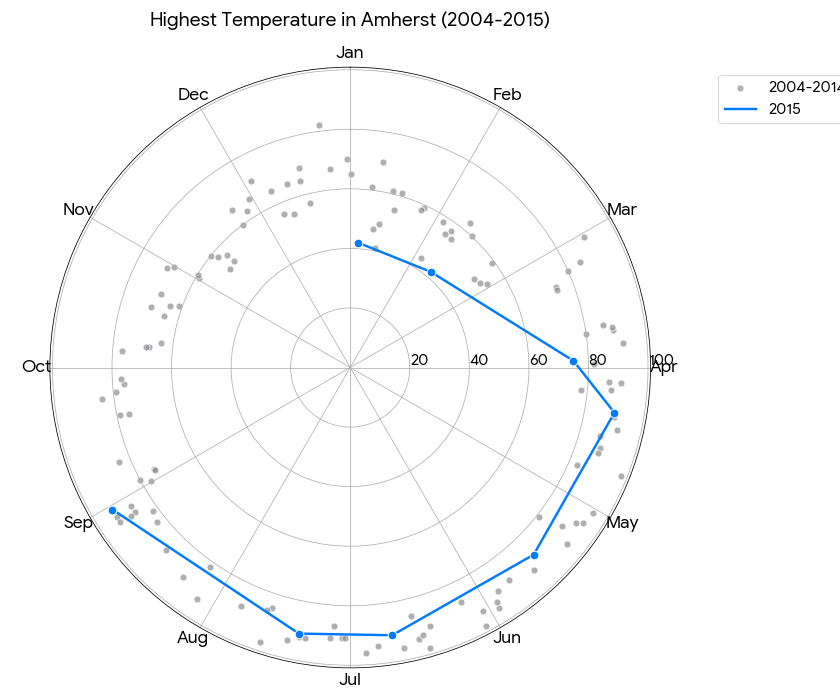

In [33]:
response = await run_benchmark(95)

**Ground Truth**: `example_95.png`

![Ground Truth](https://raw.githubusercontent.com/thunlp/MatPlotAgent/refs/heads/main/benchmark_data/ground_truth/example_95.png)

Based on your query and requirements, **`output_plot.png`** is the better chart. Here is a breakdown of why it satisfies the query and scientific accuracy more effectively:

* **Emphasis on 2015 Data:** Your prompt requested "particular emphasis on the data from 2015" and asked to "distinguish it from other years." `output_plot.png` brilliantly handles this by coloring all background years (2004–2014) in a uniform, muted grey. This creates high contrast, allowing the blue 2015 line to stand out clearly. `example_95.jpg`, on the other hand, assigns a unique color to every single year, creating visual clutter that detracts from the 2015 highlight.
* **Legend Clarity:** Because `output_plot.png` simplifies the background data, its legend is concise, clean, and accurately reflects the two categories you care about (2004-2014 vs. 2015). `example_95.jpg` features an unnecessarily long legend that lists every single year, which you did not explicitly request.
* **Intuitive Layout:** `output_plot.png` places January at the top (the 12 o'clock position) and progresses clockwise. This mimics the face of a clock, which is the most intuitive and standard way for humans to read cyclical calendar data. `example_95.jpg` places January at the 3 o'clock position (0 radians) and moves counter-clockwise; while technically correct for mathematical polar coordinates, it is much less intuitive for reading months of the year.
* **Data Offset:** Both charts successfully apply the requested $0$ to $\pi/6$ radian offset to position the 1st of the month between the month lines, preventing the dots from perfectly aligning on the radial axes.

`output_plot.png` provides a much cleaner, more professional, and highly focused visual representation of your specific parameters.

### Benchmark 99

# Original query: To create a violin plot using Seaborn, you should use data from a CSV file named "data.csv" which includes columns "total_bill", "tip", "sex", "smoker", "day", "time", and "size". The plot should focus on comparing the 'total_bill' amounts for different 'day' values (days of the week), with a distinction between 'smoker' and 'non-smoker' categories. Implement split violins for this purpose, and within each violin, use quartiles to represent the data distribution. The color scheme should be green for smokers and grey for non-smokers. Adopt a dark style theme for the plot.
# Data content sample:
 ,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.5,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2


### root_agent
I have gathered the following information:
*   **Visualization Query**: "To create a violin plot using Seaborn, you should use data from a CSV file named "data.csv" which includes columns "total_bill", "tip", "sex", "smoker", "day", "time", and "size". The plot should focus on comparing the 'total_bill' amounts for different 'day' values (days of the week), with a distinction between 'smoker' and 'non-smoker' categories. Implement split violins for this purpose, and within each violin, use quartiles to represent the data distribution. The color scheme should be green for smokers and grey for non-smokers. Adopt a dark style theme for the plot."
*   **Filenames**: \["data.csv"]

I will now start the chart creation process.

### query_analyzer
{
  "interpreted_intent": "The user wants to create a split violin plot to compare the distribution of 'total_bill' for each 'day' of the week, segmented by 'smoker' status. The visualization should use a dark theme and a specific color scheme (green for smokers, grey for non-smokers).",
  "visualization_type": "violin plot",
  "plotting_key_points": [
    "Use the Seaborn library to generate the plot.",
    "The chart type must be a violin plot.",
    "Load data from the 'data.csv' file.",
    "The x-axis should represent the 'day' column.",
    "The y-axis should represent the 'total_bill' column.",
    "The plot must be split by the 'smoker' column.",
    "The inner part of the violins should display quartiles.",
    "The plot must have a dark style theme.",
    "A custom color palette must be used: 'Yes' (smoker) should be green, and 'No' (non-smoker) should be grey.",
    "The plot should have a descriptive title and clear axis labels."
  ],
  "implementation_plan": [
    {
      "step": 1,
      "action": "Load and Prepare Data",
      "details": "Load the 'data.csv' file into a pandas DataFrame.",
      "functions": [
        "pd.read_csv"
      ]
    },
    {
      "step": 2,
      "action": "Set Plot Style and Colors",
      "details": "Set the plot's visual style to a dark theme using Seaborn. Define a dictionary for the custom color palette where 'Yes' maps to green and 'No' maps to grey.",
      "functions": [
        "sns.set_style"
      ]
    },
    {
      "step": 3,
      "action": "Generate Violin Plot",
      "details": "Create the violin plot using sns.violinplot. Specify 'day' for x, 'total_bill' for y, and 'smoker' for hue. Enable the split view by setting 'split=True', set the inner representation to 'quartile', and apply the custom color palette.",
      "functions": [
        "plt.figure",
        "sns.violinplot"
      ]
    },
    {
      "step": 4,
      "action": "Finalize and Save Plot",
      "details": "Add a title (e.g., 'Total Bill Distribution by Day and Smoker Status') and labels for the x and y axes. Save the generated plot to a file.",
      "functions": [
        "plt.title",
        "plt.xlabel",
        "plt.ylabel",
        "plt.savefig"
      ]
    }
  ],
  "global_todo_list": [
    {
      "id": "todo_1",
      "task": "Analyze the 'data.csv' file to verify the presence and data types of 'total_bill', 'day', and 'smoker' columns.",
      "agent": "data_process_planner"
    },
    {
      "id": "todo_2",
      "task": "Map 'day' to the x-axis, 'total_bill' to the y-axis, and 'smoker' to the hue for a split violin plot. Specify 'quartile' for the inner representation.",
      "agent": "viz_mapping_agent"
    },
    {
      "id": "todo_3",
      "task": "Define the specific color codes for the 'green' and 'grey' palette and confirm the parameters for the 'dark' plot style.",
      "agent": "design_explorer"
    },
    {
      "id": "todo_4",
      "task": "Generate the Python code using pandas and seaborn to create the specified split violin plot, including all styling and data mapping requirements.",
      "agent": "code_generator"
    },
    {
      "id": "todo_5",
      "task": "Evaluate the final image to ensure it is a split violin plot with the correct data, colors (green/grey), dark theme, and quartile representation.",
      "agent": "visual_evaluator"
    }
  ],
  "success_criteria": [
    "The final output is a single violin plot.",
    "The x-axis correctly displays the days of the week from the 'day' column.",
    "The y-axis represents the 'total_bill' values.",
    "The violins are split based on the 'smoker' category.",
    "The plot uses a dark theme.",
    "The 'smoker' category is colored green, and the 'non-smoker' category is colored grey.",
    "The interior of each violin shows lines for the quartiles.",
    "The plot has a clear and descriptive title and axis labels."
  ]
}

#### Data summary of data.csv:
--- Detailed Metadata Profile for data.csv ---
Total Rows: 244, Total Columns: 8

Column Schema and Quality:
|            | Data Type   |   Missing Values |   Unique Values |
|:-----------|:------------|-----------------:|----------------:|
| Unnamed: 0 | int64       |                0 |             244 |
| total_bill | float64     |                0 |             229 |
| tip        | float64     |                0 |             123 |
| sex        | object      |                0 |               2 |
| smoker     | object      |                0 |               2 |
| day        | object      |                0 |               4 |
| time       | object      |                0 |               2 |
| size       | int64       |                0 |               6 |


Numerical Summary Statistics:
|       |   Unnamed: 0 |   total_bill |    tip |   size |
|:------|-------------:|-------------:|-------:|-------:|
| count |       244    |       244    | 244    | 244

### data_process_planner
{
  "processing_steps": [
    "Load the 'data.csv' file into a pandas DataFrame.",
    "No further data transformations are required as the data is clean and in the correct format for generating a violin plot."
  ],
  "insights": {
    "key_columns": [
      "total_bill",
      "day",
      "smoker"
    ],
    "aggregations_needed": [],
    "quality_issues": []
  },
  "visualization_hint": "A violin plot is highly suitable for this dataset. It will effectively visualize the distribution and probability density of 'total_bill' across different 'days', split by 'smoker' status. This aligns perfectly with the user's request to compare these distributions."
}

...

### code_generator
{
  "code_architecture": {
    "main_functions": [
      "generate_viz"
    ],
    "helper_functions": [],
    "class_structure": null,
    "modular_design": "Functional approach with a single main function handling data loading, plotting, and saving."
  },
  "matplotlib_approach": {
    "plotting_method": "plt.figure",
    "style_management": "style_sheets",
    "color_implementation": "manual_colors",
    "layout_strategy": "tight_layout"
  },
  "data_handling": {
    "data_preparation": [
      "Load CSV",
      "Define categorical order"
    ],
    "data_validation": [
      "Check file existence"
    ],
    "error_handling": [
      "Try-except block for file loading"
    ],
    "performance_considerations": [
      "Vectorized plotting with Seaborn"
    ]
  },
  "code_structure": {
    "imports": [
      "pandas",
      "seaborn",
      "matplotlib.pyplot"
    ],
    "configuration": "Set dark background style",
    "main_plotting": "Create split violin plot with quartiles",
    "customization": "Set titles, labels, ticks, and legend properties",
    "output_handling": "Save figure to PNG"
  },
  "quality_requirements": {
    "code_style": "PEP8",
    "documentation_level": "standard",
    "error_handling_level": "basic",
    "performance_priority": "balanced"
  },
  "generated_code": "import pandas as pd\nimport seaborn as sns\nimport matplotlib.pyplot as plt\n\ndef generate_viz():\n    # Load data\n    try:\n        df = pd.read_csv('data.csv')\n    except FileNotFoundError:\n        print(\"Error: 'data.csv' not found.\")\n        return\n\n    # Set plot style to dark theme\n    plt.style.use('dark_background')\n    \n    # Create figure with specified size\n    plt.figure(figsize=(12, 8))\n    \n    # Define custom color palette: Green for Smokers ('Yes'), Grey for Non-Smokers ('No')\n    palette = {\"Yes\": \"#2ecc71\", \"No\": \"#95a5a6\"}\n    \n    # Define order for days and smoker status\n    day_order = [\"Thur\", \"Fri\", \"Sat\", \"Sun\"]\n    hue_order = [\"Yes\", \"No\"]\n    \n    # Create the split violin plot\n    ax = sns.violinplot(\n        data=df,\n        x='day',\n        y='total_bill',\n        hue='smoker',\n        split=True,            # Split violins to compare distributions\n        inner='quartile',      # Show quartiles inside the violins\n        palette=palette,\n        order=day_order,\n        hue_order=hue_order,\n        linewidth=1.5          # Ensure visibility of lines\n    )\n    \n    # Customize Title and Labels\n    plt.title('Total Bill Distribution by Day and Smoker Status', fontsize=20, color='white', pad=20)\n    plt.xlabel('Day of Week', fontsize=18, color='white')\n    plt.ylabel('Total Bill ($)', fontsize=18, color='white')\n    \n    # Customize Ticks\n    plt.tick_params(axis='both', which='major', labelsize=16, colors='white')\n    \n    # Customize Legend\n    # Get handles and labels to ensure correct legend creation\n    handles, labels = ax.get_legend_handles_labels()\n    legend = plt.legend(\n        handles, labels,\n        title='Smoker',\n        title_fontsize=16,\n        fontsize=16,\n        loc='upper left',\n        facecolor='#333333',  # Dark grey background for legend\n        edgecolor='white'     # White border for legend\n    )\n    plt.setp(legend.get_title(), color='white')\n    for text in legend.get_texts():\n        text.set_color('white')\n\n    # Adjust layout and save the plot\n    plt.tight_layout()\n    plt.savefig('output_plot.png', format='png', dpi=70)\n    plt.close('all')\n\nif __name__ == \"__main__\":\n    generate_viz()"
} 

### visual_evaluator
{
  "semantic_accuracy": {
    "data_query_match": "excellent",
    "mathematical_correctness": "excellent",
    "visual_element_compliance": "excellent",
    "layout_structure_match": "excellent",
    "specification_adherence_score": 1.0
  },
  "quality_assessment": {
    "overall_quality": "excellent",
    "readability": "excellent",
    "visual_appeal": "high",
    "professional_appearance": "yes"
  },
  "requirement_analysis": {
    "key_points_covered": [
      "Chart type is a split violin plot",
      "Data loaded from 'data.csv'",
      "X-axis represents 'day'",
      "Y-axis represents 'total_bill'",
      "Violins are split by 'smoker' status",
      "Inner part displays quartiles",
      "Dark theme applied",
      "Custom color palette used (Green for Yes, Grey for No)",
      "Descriptive title and axis labels present"
    ],
    "key_points_missing": [],
    "critical_errors": [],
    "requirement_match_percentage": 1.0
  },
  "accessibility_check": {
    "color_contrast_adequate": true,
    "colorblind_friendly": true,
    "text_size_adequate": true,
    "wcag_compliance_level": "AAA"
  },
  "final_recommendation": {
    "decision": "approve",
    "confidence_level": 1.0,
    "primary_issues": [],
    "improvement_priority": "low"
  }
} 

#### The evaluation result: approve, iterations=1.
#### Exiting the loop with approval.


### transfer_agent
#### Pipeline execution result:
* Available Data Files: ['data.csv']

* Result from the `query_analyser`:
{'interpreted_intent': "The user wants to create a split violin plot to compare the distribution of 'total_bill' for each 'day' of the week, segmented by 'smoker' status. The visualization should use a dark theme and a specific color scheme (green for smokers, grey for non-smokers).", 'visualization_type': 'violin plot', 'plotting_key_points': ['Use the Seaborn library to generate the plot.', 'The chart type must be a violin plot.', "Load data from the 'data.csv' file.", "The x-axis should represent the 'day' column.", "The y-axis should represent the 'total_bill' column.", "The plot must be split by the 'smoker' column.", 'The inner part of the violins should display quartiles.', 'The plot must have a dark style theme.', "A custom color palette must be used: 'Yes' (smoker) should be green, and 'No' (non-smoker) should be grey.", 'The plot should have a descriptive title and clear axis labels.'], 'implementation_plan': [{'step': 1, 'action': 'Load and Prepare Data', 'details': "Load the 'data.csv' file into a pandas DataFrame.", 'functions': ['pd.read_csv']}, {'step': 2, 'action': 'Set Plot Style and Colors', 'details': "Set the plot's visual style to a dark theme using Seaborn. Define a dictionary for the custom color palette where 'Yes' maps to green and 'No' maps to grey.", 'functions': ['sns.set_style']}, {'step': 3, 'action': 'Generate Violin Plot', 'details': "Create the violin plot using sns.violinplot. Specify 'day' for x, 'total_bill' for y, and 'smoker' for hue. Enable the split view by setting 'split=True', set the inner representation to 'quartile', and apply the custom color palette.", 'functions': ['plt.figure', 'sns.violinplot']}, {'step': 4, 'action': 'Finalize and Save Plot', 'details': "Add a title (e.g., 'Total Bill Distribution by Day and Smoker Status') and labels for the x and y axes. Save the generated plot to a file.", 'functions': ['plt.title', 'plt.xlabel', 'plt.ylabel', 'plt.savefig']}], 'global_todo_list': [{'id': 'todo_1', 'task': "Analyze the 'data.csv' file to verify the presence and data types of 'total_bill', 'day', and 'smoker' columns.", 'agent': 'data_process_planner'}, {'id': 'todo_2', 'task': "Map 'day' to the x-axis, 'total_bill' to the y-axis, and 'smoker' to the hue for a split violin plot. Specify 'quartile' for the inner representation.", 'agent': 'viz_mapping_agent'}, {'id': 'todo_3', 'task': "Define the specific color codes for the 'green' and 'grey' palette and confirm the parameters for the 'dark' plot style.", 'agent': 'design_explorer'}, {'id': 'todo_4', 'task': 'Generate the Python code using pandas and seaborn to create the specified split violin plot, including all styling and data mapping requirements.', 'agent': 'code_generator'}, {'id': 'todo_5', 'task': 'Evaluate the final image to ensure it is a split violin plot with the correct data, colors (green/grey), dark theme, and quartile representation.', 'agent': 'visual_evaluator'}], 'success_criteria': ['The final output is a single violin plot.', "The x-axis correctly displays the days of the week from the 'day' column.", "The y-axis represents the 'total_bill' values.", "The violins are split based on the 'smoker' category.", 'The plot uses a dark theme.', "The 'smoker' category is colored green, and the 'non-smoker' category is colored grey.", 'The interior of each violin shows lines for the quartiles.', 'The plot has a clear and descriptive title and axis labels.']}
* Result from the `data_process_planner`:
{'processing_steps': ["Load the 'data.csv' file into a pandas DataFrame.", 'No further data transformations are required as the data is clean and in the correct format for generating a violin plot.'], 'insights': {'key_columns': ['total_bill', 'day', 'smoker'], 'aggregations_needed': [], 'quality_issues': []}, 'visualization_hint': "A violin plot is highly suitable for this dataset. It will effectively visualize the distribution and probability density of 'total_bill' across different 'days', split by 'smoker' status. This aligns perfectly with the user's request to compare these distributions."}
* Result from the `viz_mapping_agent`:
{'chart_type': 'box', 'data_mappings': {'x_axis': 'day', 'y_axis': 'total_bill', 'color': 'smoker', 'category': 'day'}, 'aggregations': [], 'filters': [], 'styling_hints': {'title': 'Total Bill Distribution by Day and Smoker Status', 'xlabel': 'Day of Week', 'ylabel': 'Total Bill ($)', 'color_palette': 'custom (Green for Yes, Grey for No)'}, 'transformations': [], 'goal': 'Visualize the distribution of total bills across different days, comparing smokers and non-smokers using a split violin plot.', 'rationale': 'The user explicitly requested a split violin plot to compare distributions. While \'violin\' is not in the strict schema enum, \'box\' is selected as the closest semantic equivalent for distribution visualization. The code generator must implement \'sns.violinplot\' with \'split=True\' and \'inner="quartile"\' as specified in the query analysis.', 'confidence': 1.0}
* Result from the `design_explorer`:
{'design_objectives': ['Clearly visualize and compare the probability density of total bills for smokers vs. non-smokers across different days', 'Ensure high contrast and visibility of the split violin shapes against a dark background', 'Maintain readability of internal quartile lines to facilitate statistical comparison', 'Create a modern, aesthetically pleasing chart using the requested dark theme'], 'target_audience': {'primary_audience': 'Data Analysts or Restaurant Managers', 'expertise_level': 'intermediate', 'context_of_use': 'exploration', 'accessibility_requirements': ['Ensure sufficient contrast between the Green/Grey violins and the dark background', 'Ensure text labels are legible against the dark background']}, 'visual_hierarchy': {'primary_elements': ['Violin shapes (distribution curves)', 'Split distinction between Smoker (Green) and Non-Smoker (Grey)'], 'secondary_elements': ['Quartile lines inside the violins', 'Axis labels (Day, Total Bill)'], 'emphasis_strategy': 'Color contrast is the primary emphasis strategy, distinguishing the two categories within the split violins.'}, 'color_strategy': {'primary_colors': ['#2ecc71', '#95a5a6'], 'color_meaning': "Green (#2ecc71) represents Smokers ('Yes'), and Grey (#95a5a6) represents Non-Smokers ('No').", 'accessibility_compliance': 'WCAG AA', 'cultural_considerations': "Green often signifies 'Go' or 'Nature', but here it is strictly categorical. Grey implies neutral or baseline."}, 'layout_principles': {'composition_approach': 'balanced', 'spacing_strategy': 'moderate', 'alignment_system': 'center', 'proportion_ratios': 'custom'}, 'typography_requirements': {'font_hierarchy': 'Title (20pt) > Axis Labels (18pt) > Ticks/Legend (16pt)', 'readability_priority': 'high', 'brand_alignment': 'technical'}, 'interaction_design': {'interaction_level': 'static', 'user_controls': [], 'feedback_mechanisms': 'None'}, 'technical_constraints': {'output_format': 'static', 'size_limitations': 'screen', 'performance_requirements': 'moderate'}, 'innovation_opportunities': ["Using a dark background ('dark_background' style) to make the green pop significantly", 'Precise quartile rendering inside the split violins for immediate statistical insight'], 'design_confidence': 1.0}
* Result from the `code_generator`:
{'code_architecture': {'main_functions': ['generate_viz'], 'helper_functions': [], 'modular_design': 'Functional approach with a single main function handling data loading, plotting, and saving.'}, 'matplotlib_approach': {'plotting_method': 'plt.figure', 'style_management': 'style_sheets', 'color_implementation': 'manual_colors', 'layout_strategy': 'tight_layout'}, 'data_handling': {'data_preparation': ['Load CSV', 'Define categorical order'], 'data_validation': ['Check file existence'], 'error_handling': ['Try-except block for file loading'], 'performance_considerations': ['Vectorized plotting with Seaborn']}, 'code_structure': {'imports': ['pandas', 'seaborn', 'matplotlib.pyplot'], 'configuration': 'Set dark background style', 'main_plotting': 'Create split violin plot with quartiles', 'customization': 'Set titles, labels, ticks, and legend properties', 'output_handling': 'Save figure to PNG'}, 'quality_requirements': {'code_style': 'PEP8', 'documentation_level': 'standard', 'error_handling_level': 'basic', 'performance_priority': 'balanced'}, 'generated_code': 'import pandas as pd\nimport seaborn as sns\nimport matplotlib.pyplot as plt\n\ndef generate_viz():\n    # Load data\n    try:\n        df = pd.read_csv(\'data.csv\')\n    except FileNotFoundError:\n        print("Error: \'data.csv\' not found.")\n        return\n\n    # Set plot style to dark theme\n    plt.style.use(\'dark_background\')\n    \n    # Create figure with specified size\n    plt.figure(figsize=(12, 8))\n    \n    # Define custom color palette: Green for Smokers (\'Yes\'), Grey for Non-Smokers (\'No\')\n    palette = {"Yes": "#2ecc71", "No": "#95a5a6"}\n    \n    # Define order for days and smoker status\n    day_order = ["Thur", "Fri", "Sat", "Sun"]\n    hue_order = ["Yes", "No"]\n    \n    # Create the split violin plot\n    ax = sns.violinplot(\n        data=df,\n        x=\'day\',\n        y=\'total_bill\',\n        hue=\'smoker\',\n        split=True,            # Split violins to compare distributions\n        inner=\'quartile\',      # Show quartiles inside the violins\n        palette=palette,\n        order=day_order,\n        hue_order=hue_order,\n        linewidth=1.5          # Ensure visibility of lines\n    )\n    \n    # Customize Title and Labels\n    plt.title(\'Total Bill Distribution by Day and Smoker Status\', fontsize=20, color=\'white\', pad=20)\n    plt.xlabel(\'Day of Week\', fontsize=18, color=\'white\')\n    plt.ylabel(\'Total Bill ($)\', fontsize=18, color=\'white\')\n    \n    # Customize Ticks\n    plt.tick_params(axis=\'both\', which=\'major\', labelsize=16, colors=\'white\')\n    \n    # Customize Legend\n    # Get handles and labels to ensure correct legend creation\n    handles, labels = ax.get_legend_handles_labels()\n    legend = plt.legend(\n        handles, labels,\n        title=\'Smoker\',\n        title_fontsize=16,\n        fontsize=16,\n        loc=\'upper left\',\n        facecolor=\'#333333\',  # Dark grey background for legend\n        edgecolor=\'white\'     # White border for legend\n    )\n    plt.setp(legend.get_title(), color=\'white\')\n    for text in legend.get_texts():\n        text.set_color(\'white\')\n\n    # Adjust layout and save the plot\n    plt.tight_layout()\n    plt.savefig(\'output_plot.png\', format=\'png\', dpi=70)\n    plt.close(\'all\')\n\nif __name__ == "__main__":\n    generate_viz()'}
* Result from the `visual_evaluator`:
{'semantic_accuracy': {'data_query_match': 'excellent', 'mathematical_correctness': 'excellent', 'visual_element_compliance': 'excellent', 'layout_structure_match': 'excellent', 'specification_adherence_score': 1.0}, 'quality_assessment': {'overall_quality': 'excellent', 'readability': 'excellent', 'visual_appeal': 'high', 'professional_appearance': 'yes'}, 'requirement_analysis': {'key_points_covered': ['Chart type is a split violin plot', "Data loaded from 'data.csv'", "X-axis represents 'day'", "Y-axis represents 'total_bill'", "Violins are split by 'smoker' status", 'Inner part displays quartiles', 'Dark theme applied', 'Custom color palette used (Green for Yes, Grey for No)', 'Descriptive title and axis labels present'], 'key_points_missing': [], 'critical_errors': [], 'requirement_match_percentage': 1.0}, 'accessibility_check': {'color_contrast_adequate': True, 'colorblind_friendly': True, 'text_size_adequate': True, 'wcag_compliance_level': 'AAA'}, 'final_recommendation': {'decision': 'approve', 'confidence_level': 1.0, 'primary_issues': [], 'improvement_priority': 'low'}}


### root_agent
The chart has been successfully generated! It is a split violin plot showing the distribution of 'total_bill' across different days, distinguishing between smokers and non-smokers with a dark theme and custom green/grey colors. The plot includes quartiles within each violin and has appropriate titles and labels.

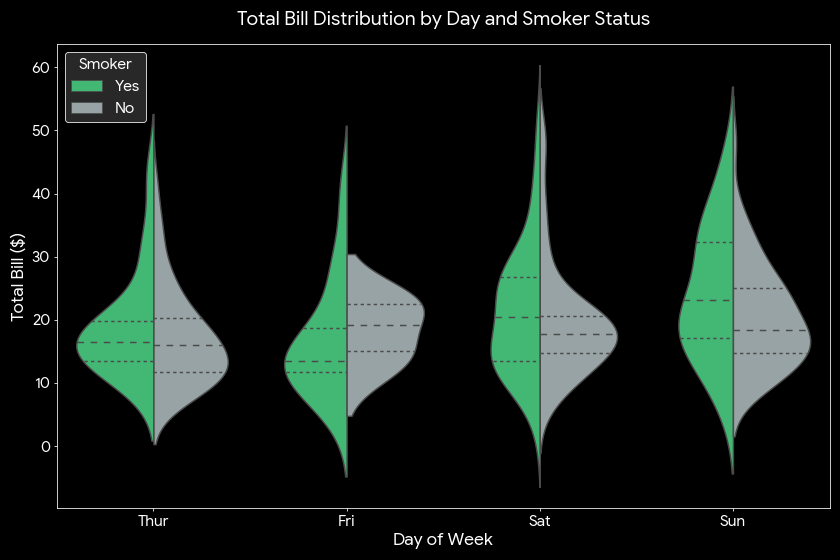

In [34]:
response = await run_benchmark(99)

**Ground Truth**: `example_99.png`

![Ground Truth](https://raw.githubusercontent.com/thunlp/MatPlotAgent/refs/heads/main/benchmark_data/ground_truth/example_99.png)

Based on the original query, the **output_plot.png** (with the black background) better satisfies the requirements.

Here is a breakdown of why:

* **Dark Style Theme:** **output_plot.png** successfully implements the requested "dark style theme" with its black background, white text, and dark-themed axes. **example_99.png** uses a standard light grey background, missing this specific styling requirement.
* **Color Scheme:** Both charts correctly map the colors (green for smokers, grey for non-smokers).
* **Plot Structure:** Both charts successfully implement the requested split violins, compare 'total_bill' across 'days', and include dashed lines to represent the quartiles.

Because it fully captures the aesthetic requirements alongside the structural ones, **output_plot.png** is the accurate output for your query.